# XGBoost2GPU Example

Este notebook demonstra como usar a classe `XGBoost2GPU` para gerar código CUDA a partir de modelos XGBoost treinados com TreeLUT.

## Importações e Configuração do Ambiente

In [1]:
import sys
import os
from pathlib import Path

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# Importações principais
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Minhas importações
from LoadDataset import LoadDataset
from treelut import TreeLUTClassifier
from xgboost2gpu import XGBoost2GPU


## Parâmetros do Modelo

In [2]:
# Parâmetros para o XGBoost
xgb_params = {
    'objective': 'multi:softmax', 
    'num_class': 7, 
    'n_estimators':7, 
    'max_depth': 6, 
    'eta': 0.8
}

# Parâmetros para o TreeLUT
treelut_params = {
    'w_feature': 3, 
    'w_tree': 3,
    'bits_features': 32,
    'pipeline': [0, 0, 0], 
    'dir_path': './results/OutputFiles/MakeDataset/',
    'style': 'mux',
    'argmax': True,
    'quantized': True
}

# Parâmetros para o make_classification
make_classification_params = {
    'n_samples': 100000, 
    'n_features': 30, 
    'n_informative': 10, 
    'n_redundant': 0, 
    'n_classes': xgb_params['num_class'], 
    'random_state': 42
}

# Parâmetros para o XGBoost2GPU
xgb2gpu_params = {
    'percentage_to_cut': 0.10,
    'strategy': 'random',
    'level_importance': 1,
    'progress_importance': 0.0,
    'level_bias': 2,
    'max_cut_percentage': 0.5,
    'urgency_override_threshold': 1.5,
    'output_file': './results/prune.csv'
}

## Carregamento e Preparação dos Dados

Vamos usar um dataset sintético para demonstração. Em um cenário real, você pode usar qualquer dataset de classificação.

In [3]:
# Gerar dados sintéticos para demonstração
from sklearn.datasets import make_classification

# Criar dataset sintético
X, y = make_classification(**make_classification_params)


# # Load Sus dataset
# susy = pd.read_csv('../misc/data/SUSY_int.csv')
# data = susy.drop(columns=['target'])
# target = susy['target'].astype('int')

# Load Covtype dataset
data, target = LoadDataset.load_covtype()

# Converter para DataFrame para facilitar manipulação
# data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
# target = pd.Series(y, name='target')





print(f"Dataset shape: {data.shape}")
print(f"Classes: {np.unique(target)}")
print(f"Class distribution: {np.bincount(target)}")


Dataset shape: (581012, 54)
Classes: [0 1 2 3 4 5 6]
Class distribution: [211840 283301  35754   2747   9493  17367  20510]


In [4]:


# Converter para uint8 para compatibilidade
data_un = data.astype('int32')
data_un = data_un.astype(f'uint{treelut_params["bits_features"]}')


X_train, X_test, y_train, y_test = train_test_split(
    data_un, target, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Obter valores máximos e mínimos para quantização
max_values = X_test.max().astype(f'uint{treelut_params["bits_features"]}').to_numpy()
min_values = X_test.min().astype(f'uint{treelut_params["bits_features"]}').to_numpy()

print("Valores máximos por feature:")
print(max_values)
print("\nValores mínimos por feature:")
print(min_values)

Valores máximos por feature:
[      3849        360         65       1383 4294967295       7087
        254        254        253       7172          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1
          1          1          1          1          1          1]

Valores mínimos por feature:
[1871    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


## Quantização dos Dados

In [5]:
# Aplicar normalização Min-Max
scaler = MinMaxScaler()
w_feature_treelut = treelut_params['w_feature']

X_train_min_max = np.round(scaler.fit_transform(X_train) * (2**w_feature_treelut - 1))
X_test_min_max = np.clip(
    np.round(scaler.transform(X_test) * (2**w_feature_treelut - 1)), 
    0, 2**w_feature_treelut - 1
)
X_valid_min_max = np.clip(
    np.round(scaler.transform(X_valid) * (2**w_feature_treelut - 1)), 
    0, 2**w_feature_treelut - 1
)

# Quantização simples usando operação bit-wise
X_train_quantized = np.array(X_train, dtype=np.int32) & (2**w_feature_treelut - 1)
X_test_quantized = np.array(X_test, dtype=np.int32) & (2**w_feature_treelut - 1)
X_valid_quantized = np.array(X_valid, dtype=np.int32) & (2**w_feature_treelut - 1)

print(f"Dados originais shape: {X_train.shape}")
print(f"Dados quantizados shape: {X_train_quantized.shape}")

Dados originais shape: (371847, 54)
Dados quantizados shape: (371847, 54)


## Treinamento do Modelo XGBoost

In [6]:
# Treinar modelo XGBoost com dados quantizados
xgb_clf = XGBClassifier(**xgb_params)
xgb_clf.fit(X_train_quantized, y_train)
y_pred_xgb = xgb_clf.predict(X_test_quantized)
print(f"Acurácia XGBoost (dados quantizados): {accuracy_score(y_pred_xgb, y_test):.3f}")

# Treinar modelo XGBoost com dados originais para comparação
xgb_clf_original = XGBClassifier(**xgb_params)
xgb_clf_original.fit(X_train, y_train)
y_pred_xgb_original = xgb_clf_original.predict(X_test)
print(f"Acurácia XGBoost (dados originais): {accuracy_score(y_pred_xgb_original, y_test):.3f}")

# Treinar modelo XGBoost com dados min-max normalizados
xgb_clf_min_max = XGBClassifier(**xgb_params)
xgb_clf_min_max.fit(X_train_min_max, y_train)
y_pred_xgb_min_max = xgb_clf_min_max.predict(X_test_min_max)
print(f"Acurácia XGBoost (min-max): {accuracy_score(y_pred_xgb_min_max, y_test):.3f}")

Acurácia XGBoost (dados quantizados): 0.647
Acurácia XGBoost (dados originais): 0.792
Acurácia XGBoost (min-max): 0.749


## Conversão para TreeLUT

In [7]:
# Escolher dados de teste baseado nos parâmetros do TreeLUT
treelut_X_test = X_test if treelut_params['quantized'] else X_test_quantized

# Criar e converter modelo TreeLUT
treelut_clf = TreeLUTClassifier(
    xgb_model=xgb_clf_min_max, 
    **treelut_params, 
    min=min_values, 
    max=max_values
)

treelut_clf.convert()
y_pred_treelut = treelut_clf.predict(X_test_min_max)
print(f"Acurácia TreeLUT: {accuracy_score(y_pred_treelut, y_test):.3f}")

# Save verilog
treelut_clf.verilog()
treelut_clf.testbench(treelut_X_test, y_test)

# Mostrar informações sobre as árvores
print(f"\nNúmero de árvores: {len(treelut_clf.trees)}")
print(f"Número total de nós: {sum(treelut_clf.nodes())}")
print(f"Número de nós por árvore: {treelut_clf.nodes()}")
print(f"Número de classes: {treelut_clf.n_classes}")

Acurácia TreeLUT: 0.652

Número de árvores: 49
Número total de nós: 3705
Número de nós por árvore: [121, 125, 91, 77, 113, 85, 103, 113, 119, 83, 49, 115, 77, 83, 97, 97, 47, 53, 93, 77, 71, 103, 103, 53, 57, 57, 49, 87, 73, 111, 51, 57, 47, 49, 75, 93, 91, 35, 53, 41, 49, 79, 45, 107, 43, 53, 43, 51, 61]
Número de classes: 7


## Geração de Código CUDA com XGBoost2GPU

In [8]:
# Criar instância do XGBoost2GPU
xgb2gpu = XGBoost2GPU(treelut_model=treelut_clf, 
                      w_feature=treelut_params['w_feature'],
                      w_tree=treelut_params['w_tree'], 
                      n_samples=X_valid.shape[0],
                      n_threads=256,
                      n_blocks=79,
                      debug=False)

# Create results directory if it doesn't exist
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

# Definir arquivo de saída
output_file = f"./results/xgboost_cuda_generated.cu"

# Gerar código CUDA
xgb2gpu.generate_cuda_code(output_file, optimization=True)
print(f"✅ Código CUDA gerado com sucesso em: {output_file}")

# Calcular e salvar probabilidades de corte
xgb2gpu.calculate_forest_probabilities(**xgb2gpu_params)
print("✅ Probabilidades de corte calculadas e salvas em: ./results/prune.csv")


CUDA code generated and saved to ./results/xgboost_cuda_generated.cu
✅ Código CUDA gerado com sucesso em: ./results/xgboost_cuda_generated.cu
✅ Probabilidades de corte calculadas e salvas em: ./results/prune.csv


### Análise de Probabilidades de Corte

In [9]:
prune_matrix = xgb2gpu.prune_matrix(save_matrix=True)
unique_rows, counts = np.unique(prune_matrix, axis=0, return_counts=True)

print(f"Total de amostras: {len(prune_matrix)}")
print(f"Padrões únicos: {len(unique_rows)}")
print(f"Padrões que se repetem: {len(counts[counts > 1])}")
print(f"Maior repetição: {max(counts)}")

# Valor de 0 e 1 de cada linha
print("Valores de 0 e 1 de cada linha:")
num_1s = []
num_0s = []
for row in prune_matrix:
    num_1s.append(np.sum(row))
    num_0s.append(len(row) - np.sum(row))
print(f"Número médio de 1s: {np.mean(num_1s):.3f}")
print(f"Número médio de 0s: {np.mean(num_0s):.3f}")

Total de amostras: 20224
Padrões únicos: 20224
Padrões que se repetem: 0
Maior repetição: 1
Valores de 0 e 1 de cada linha:
Número médio de 1s: 4735284311.258
Número médio de 0s: 18445831947530749952.000


/tmp/ipykernel_116445/4065114643.py:15: RuntimeWarning: overflow encountered in scalar subtract
  num_0s.append(len(row) - np.sum(row))


In [10]:
# Salvar X_test em um arquivo CSV
def save_test_data_to_csv(X_test, file_path):
    try:
        # Drop header and index to match the expected format
        if isinstance(X_test, pd.DataFrame):
            X_test = X_test.values  # Convert DataFrame to numpy array if needed
            # Drop header
        elif isinstance(X_test, pd.Series):
            X_test = X_test.values.reshape(-1, 1)  # Convert Series to 2D array
        elif not isinstance(X_test, np.ndarray):
            raise ValueError("X_test deve ser um DataFrame ou um numpy array.")
        # Save to CSV
        df = pd.DataFrame(X_test)
        df.to_csv(file_path, index=False, header=False)
        print(f"✅ Dados de teste salvos em: {file_path}")
    except Exception as e:
        print(f"❌ Erro ao salvar os dados de teste: {e}")
save_test_data_to_csv(X_valid_min_max, "./results/input.csv")
save_test_data_to_csv(y_valid, "./results/expected_output.csv")

✅ Dados de teste salvos em: ./results/input.csv
✅ Dados de teste salvos em: ./results/expected_output.csv


## Próximos Passos

Para usar o código CUDA gerado:

1. **Compilação**: Compile o arquivo `.cu` usando `nvcc`
2. **Dados de entrada**: Prepare arquivos CSV com os dados de teste:
   - `input.csv`: Dados de entrada para inferência
   - `expected_output.csv`: Rótulos esperados para validação
   - `prune.csv`: Vetor de poda para controlar quais nós usar
3. **Execução**: Execute o programa CUDA compilado
4. **Análise**: Verifique a acurácia e performance

### Exemplo de compilação:
```bash
nvcc -o xgboost_gpu xgboost_cuda_generated.cu
./xgboost_gpu
```

## Rodar cuda

In [11]:
import collections

def write_dict_to_csv(filename, data_dict):
    import os
    import csv
    # Check if the file exists
    file_exists = os.path.exists(filename)

    # Open the CSV file in append mode so that existing data isn't overwritten
    with open(filename, mode='a', newline='') as file:
        fieldnames = data_dict.keys()
        writer = csv.DictWriter(file, fieldnames=fieldnames)

        # If the file doesn't exist, write the header
        if not file_exists:
            writer.writeheader()

        # Write the dictionary as a new row
        writer.writerow(data_dict)

def simulate_multiple_cuts(tree, thread_id, cut_probability=0.2):
    """
    Simulates multiple cuts in a tree for a specific thread.
    Returns a set of nodes that were "cut".
    """
    cut_nodes = set()
    for node_id, value in tree.items():
        # Simulate the cut decision based on the thread ID and a cut probability.
        if xgb2gpu.should_cut_node(thread_id, value['global_id']):
            # If the node is cut, add it to the set of cut nodes.
            cut_nodes.add(node_id)

    return cut_nodes


def consequence_cut(tree, cut_nodes:list):
    """
    Determines the consequence of cutting nodes in a tree.
    Returns a set of nodes that are affected by the cuts.
    """
    affected_nodes = set()
    
    for node_id in cut_nodes:
        # Verifica se o nó a ser cortado é um nó de decisão.
        if node_id in tree and tree[node_id].get('type') == 'split':
            # Inicia uma fila para a travessia a partir dos filhos diretos.
            queue = []
            left_child = tree[node_id].get('no')
            right_child = tree[node_id].get('yes')

            if left_child is not None:
                queue.append(left_child)
            if right_child is not None:
                queue.append(right_child)
            
            # Realiza uma travessia (BFS) para encontrar todos os descendentes.
            while queue:
                current_node_id = queue.pop(0)
                if current_node_id not in affected_nodes:                
                    affected_nodes.add(current_node_id)
                    
                    current_node_data = tree.get(current_node_id)
                    
                    if current_node_data and current_node_data.get('type') == 'split':
                        grand_left_child = current_node_data.get('no')
                        grand_right_child = current_node_data.get('yes')
                        
                        if grand_left_child is not None:
                            queue.append(grand_left_child)
                        if grand_right_child is not None:
                            queue.append(grand_right_child)


    return affected_nodes


def node_id_complete_tree(tree):
    """
    Returns the tree dict updated with the "realID" key for each node.
    This key represents the node's ID based on its position in a complete tree.
        
    Args:
        tree (dict): The tree structure.
        max_nodes (int): The maximum number of nodes in the complete tree (optional, not used directly in the calculation).

    Returns:
        dict: The updated tree with "realID" for each node.
    """
    updated_tree = {node_id: data.copy() for node_id, data in tree.items()}
    
    # 1. Find the root node (the one without a 'parent_node' key)
    root_id = None
    for node_id, node_data in updated_tree.items():
        if 'parent_node' not in node_data:
            root_id = node_id
            break
            
    if root_id is None:
        raise ValueError("Root node not found in the tree.")

    # 2. Use a queue (deque) for Breadth-First Search (BFS)
    queue = collections.deque()
    
    # 3. Initialize the root's "realID" and add it to the queue
    updated_tree[root_id]['realID'] = 0
    queue.append(root_id)
    
    # 4. Process the queue until it is empty
    while queue:
        current_id = queue.popleft()
        current_node = updated_tree[current_id]
        
        # The parent's "realID" is needed to calculate the children's IDs
        parent_real_id = current_node['realID']
        
        # Process children only if the current node is a decision node ('split')
        if current_node.get('type') == 'split':
            # We assume 'no' is the left child and 'yes' is the right child
            left_child_id = current_node.get('no')
            right_child_id = current_node.get('yes')
            
            # Process the left child ('no')
            if left_child_id is not None and left_child_id in updated_tree:
                # Calculate the realID: 2 * p + 1
                updated_tree[left_child_id]['realID'] = 2 * parent_real_id + 2
                queue.append(left_child_id)

            # Process the right child ('yes')
            if right_child_id is not None and right_child_id in updated_tree:
                # Calculate the realID: 2 * p + 2
                updated_tree[right_child_id]['realID'] = 2 * parent_real_id + 1
                queue.append(right_child_id)
    
                
    return updated_tree
 
    

def plot_forest_overview(trees, thread_id_to_plot, num_classes, num_trees_per_class, output_file='forest_overview.png'):
    """
    Generates a single grid image showing an overview of all trees in the forest,
    highlighting the nodes cut by a specific thread.
    """
    # print(f"\n[Forest Overview] Generating grid for Thread ID: {thread_id_to_plot}...")
    
    # Adjust figsize to make bars thinner.
    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_trees_per_class,
        figsize=(num_trees_per_class * 2.5, num_classes * 0.8),
        squeeze=False,
        constrained_layout=True
    )
    fig.suptitle(f'Forest Overview - Cut Nodes (Thread ID: {thread_id_to_plot})', fontsize=16)

    max_node_id = max(len(tree) for tree in trees if tree) if trees else 0

    # Colormap: 0=Not in tree, 1=In tree, 2=Cut
    cmap = ListedColormap(['#a0a0a0', "#f0f0f0", '#e57373', '#fff176'])

    num_cutted_nodes = 0
    num_real_cutted  = 0

    for class_idx in range(num_classes):
        for tree_idx in range(num_trees_per_class):
            ax = axes[class_idx, tree_idx]
            ax.set_title(f'C{class_idx}-T{tree_idx}', fontsize=10)
            ax.set_yticks([]) # Remove y-axis ticks for a cleaner look
            
            list_key = class_idx + tree_idx * num_classes
            if list_key >= len(trees) or not trees[list_key]:
                ax.text(0.5, 0.5, 'Empty', ha='center', va='center', fontsize=9, color='gray')
                ax.set_xticks([])
                continue
            
            tree             = node_id_complete_tree(trees[list_key])
            real_node_id     = [dado['realID'] for dado in tree.values()]
            cut_nodes        = simulate_multiple_cuts(trees[list_key], thread_id_to_plot)
            consequence_cuts = consequence_cut(trees[list_key], cut_nodes)
            
            # Create a status bar for the tree.
            status_bar = np.zeros((1, max_node_id))
            for node_id in range(max_node_id):
                if node_id in real_node_id:
                    status_bar[0, node_id] = 1 # Node exists.
                if node_id in cut_nodes:
                    status_bar[0, node_id] = 2 # Node was cut.
                if node_id in consequence_cuts:
                    status_bar[0, node_id] = 3 # Node was affected by a cut.

            all_cutted_nodes = set(cut_nodes) | set(consequence_cuts)
            real_cutted_nodes = set(cut_nodes) - set(consequence_cuts)
            num_cutted_nodes += len(all_cutted_nodes)
            num_real_cutted += len(real_cutted_nodes)


            # Plot the status bar as an image.
            ax.imshow(status_bar, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=3)
            
            # Reverse x-axis to show deeper nodes (higher ID) on the left.
            # ax.set_xlim(max_node_id + 0.5, -0.5)
            ax.set_xticks([]) # Hide individual x-axis ticks to avoid clutter.

    # Create a single legend for the entire figure.
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color='#a0a0a0', label='Node Does Not Exist'),
        plt.Rectangle((0, 0), 1, 1, color='#e57373', label='Node Was Cut')
        , plt.Rectangle((0, 0), 1, 1, color='#fff176', label='Node Affected by Cut')
    ]
    fig.legend(handles=legend_patches, loc='center', ncol=3, bbox_to_anchor=(0.5, -0.20))

    # Add a single, shared x-axis label.
    fig.text(0.5, -0.05, 'Node ID (Deeper levels to the right)', ha='center', va='center', fontsize=12)
    
    plt.savefig(output_file, dpi=150, bbox_inches='tight')

    return num_cutted_nodes, num_real_cutted


Executing combinations:   0%|          | 0/80 [00:00<?, ?combination/s]

CUDA code generated and saved to ./results/0.1_t14_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.2_t14_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.3_t14_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.4_t14_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.5_t14_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.1_t14_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.2_t14_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.3_t14_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.4_t14_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.5_t14_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.1_t14_d11_2_0_-1_0.5/xgboost_cuda_g

/tmp/ipykernel_116445/1830794977.py:147: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


CUDA code generated and saved to ./results/0.2_t7_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.3_t7_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.4_t7_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.5_t7_d14_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.1_t7_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.2_t7_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.3_t7_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.4_t7_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.5_t7_d13_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.1_t7_d11_2_0_-1_0.5/xgboost_cuda_generated.cu
CUDA code generated and saved to ./results/0.2_t7_d11_2_0_-1_0.5/xgboost_cuda_generated.cu

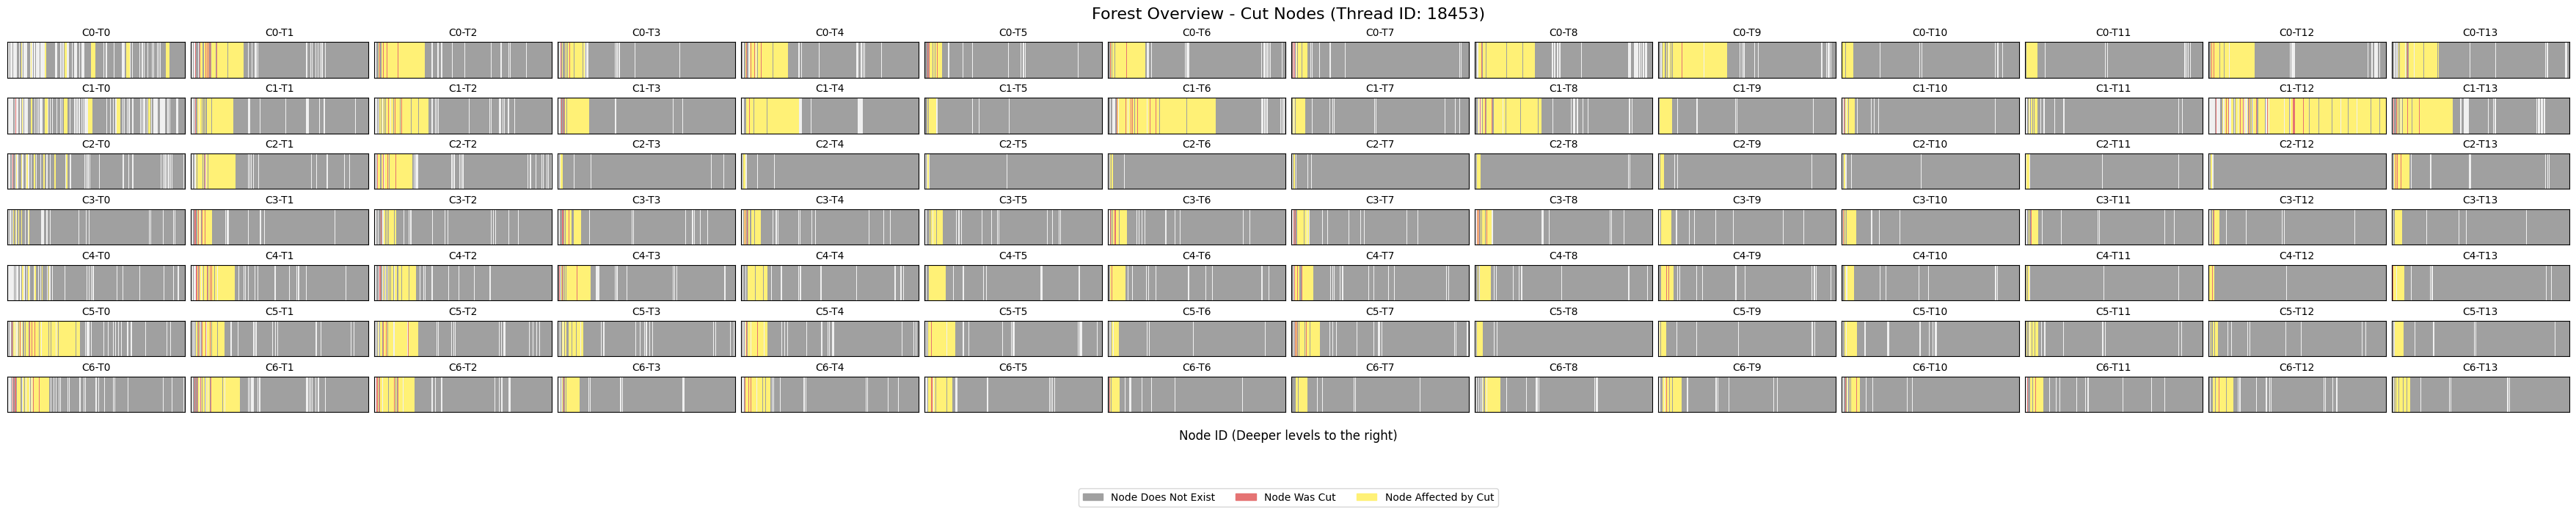

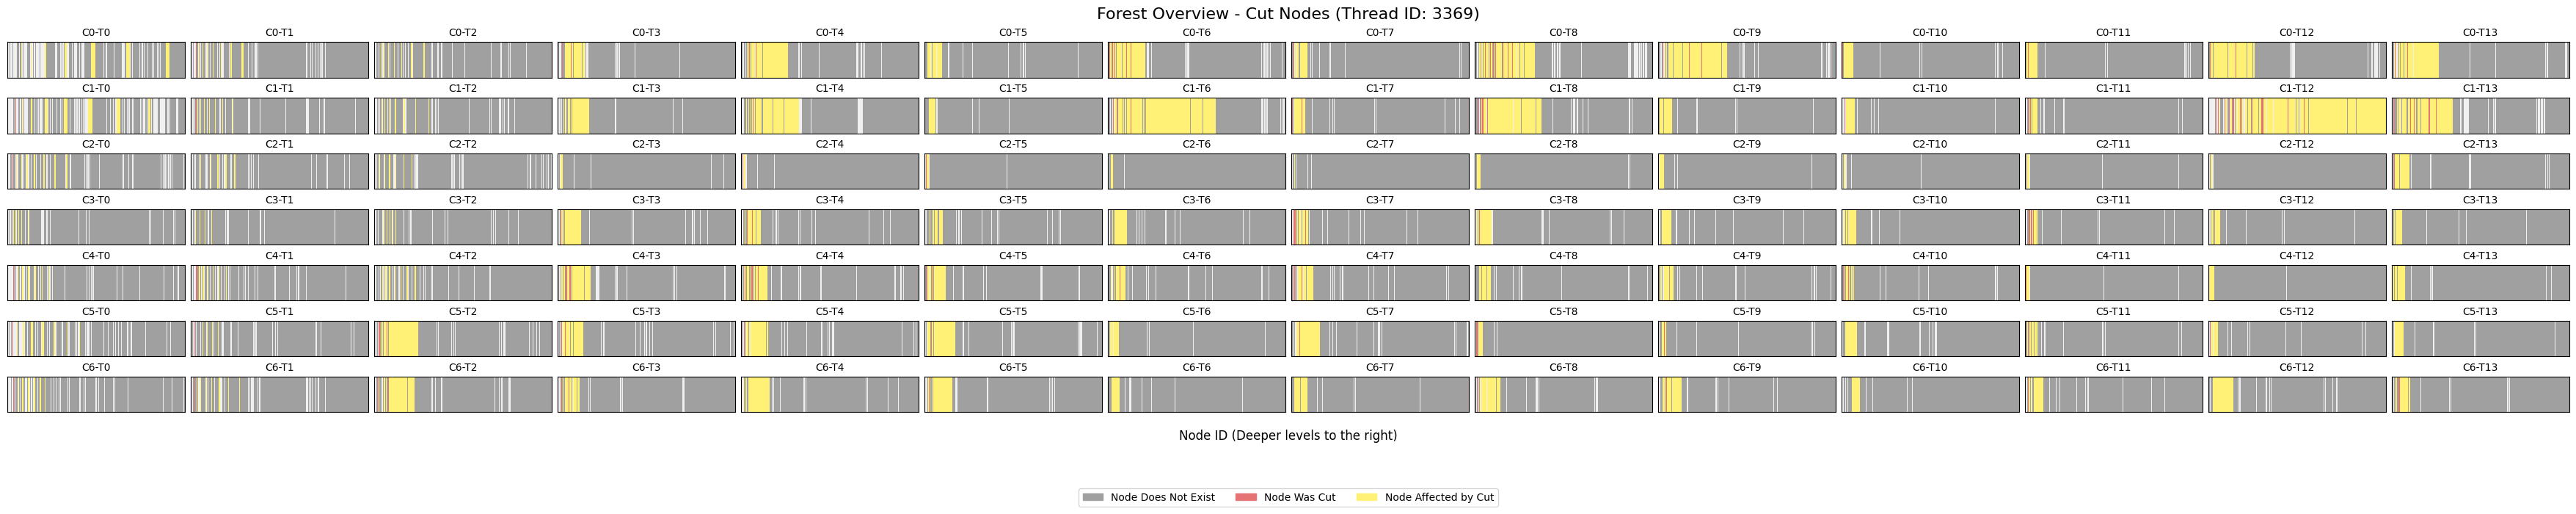

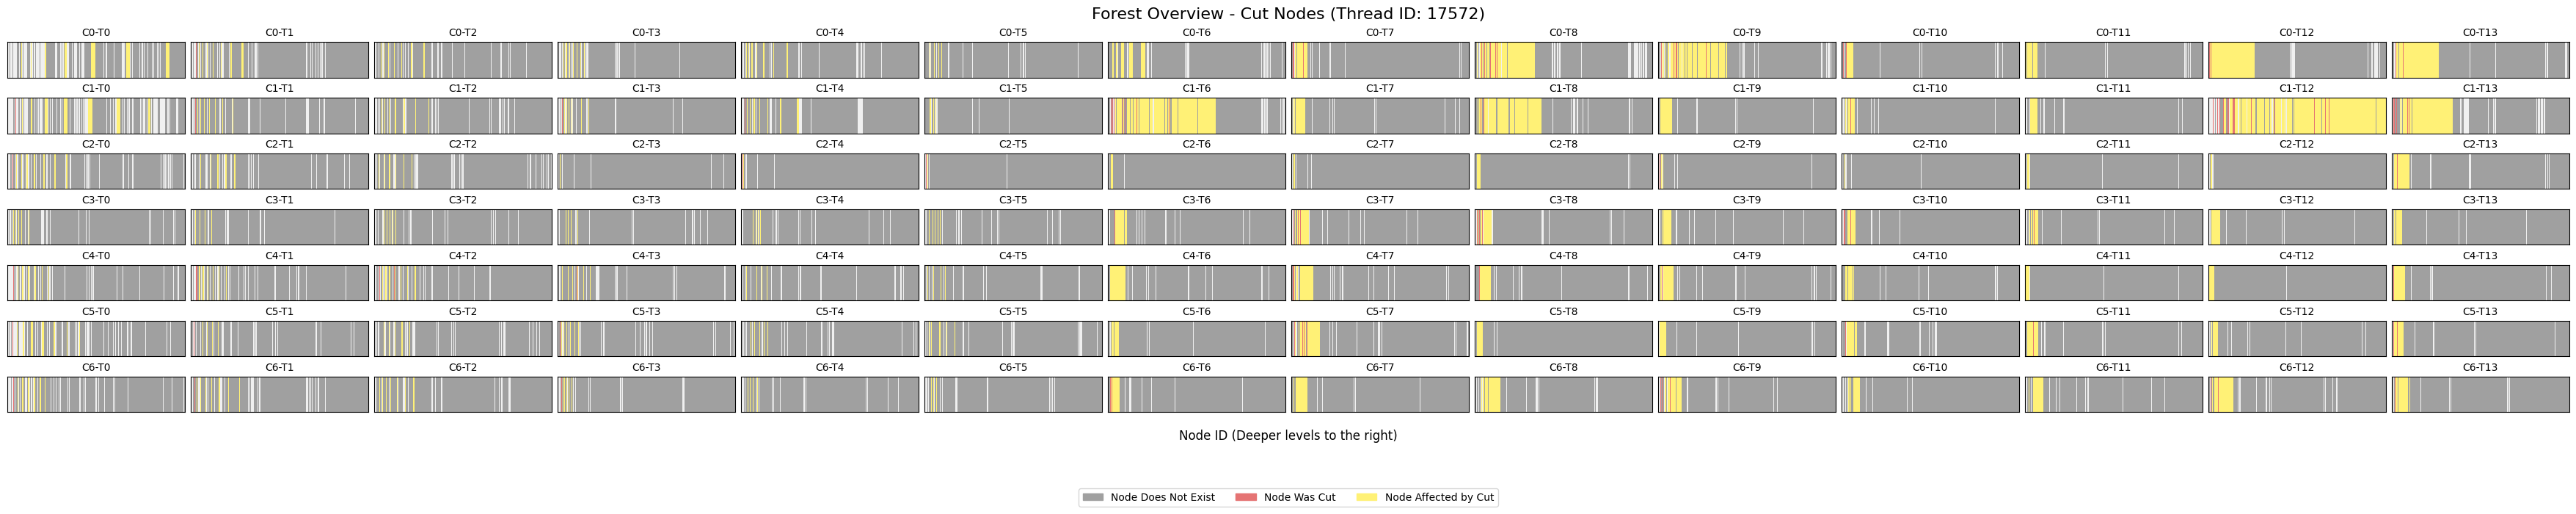

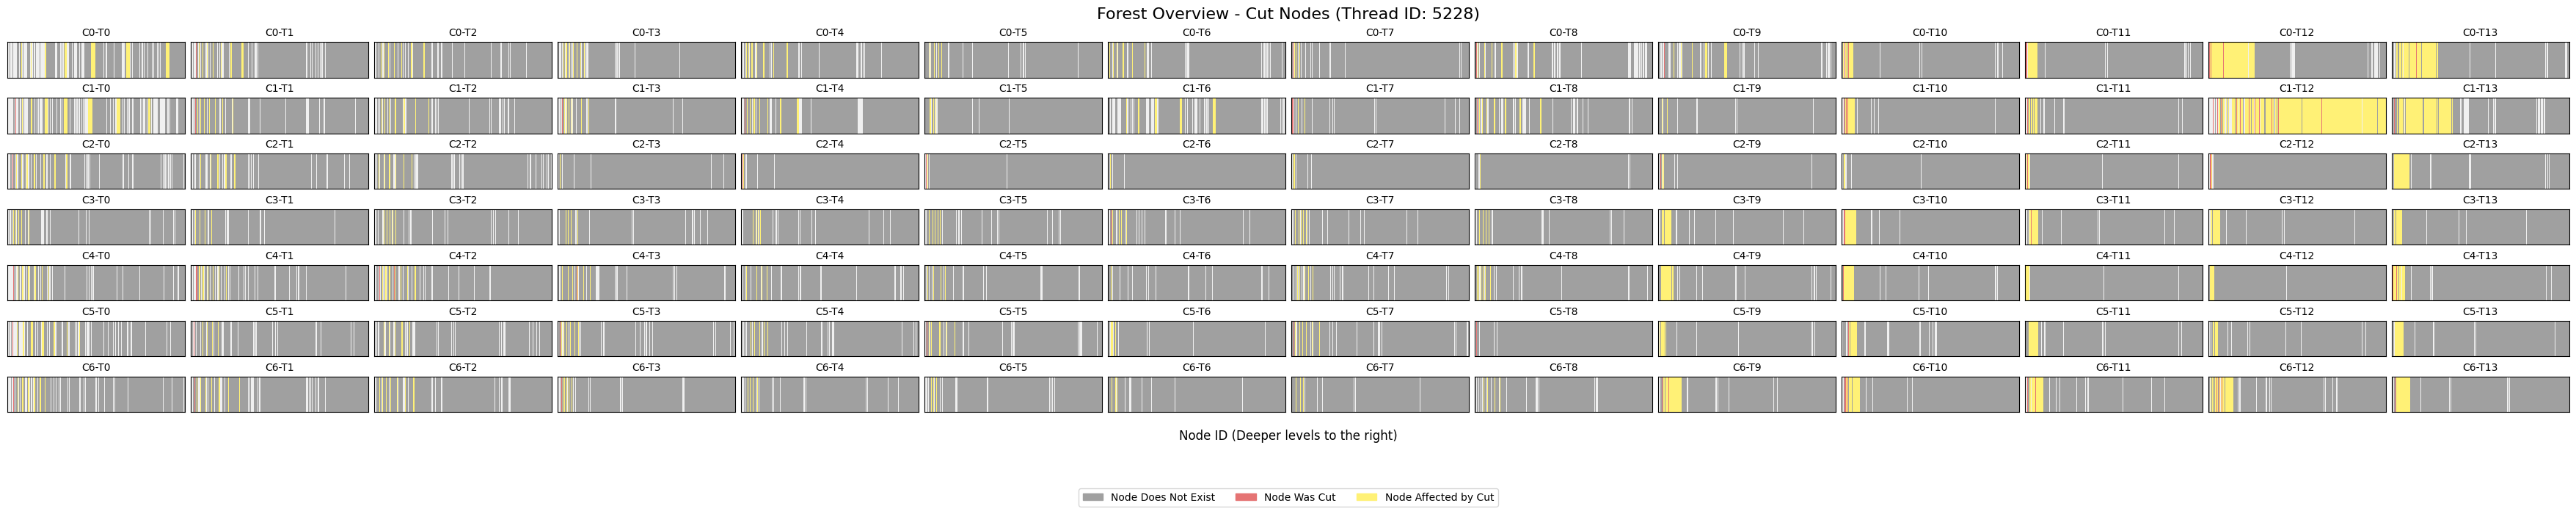

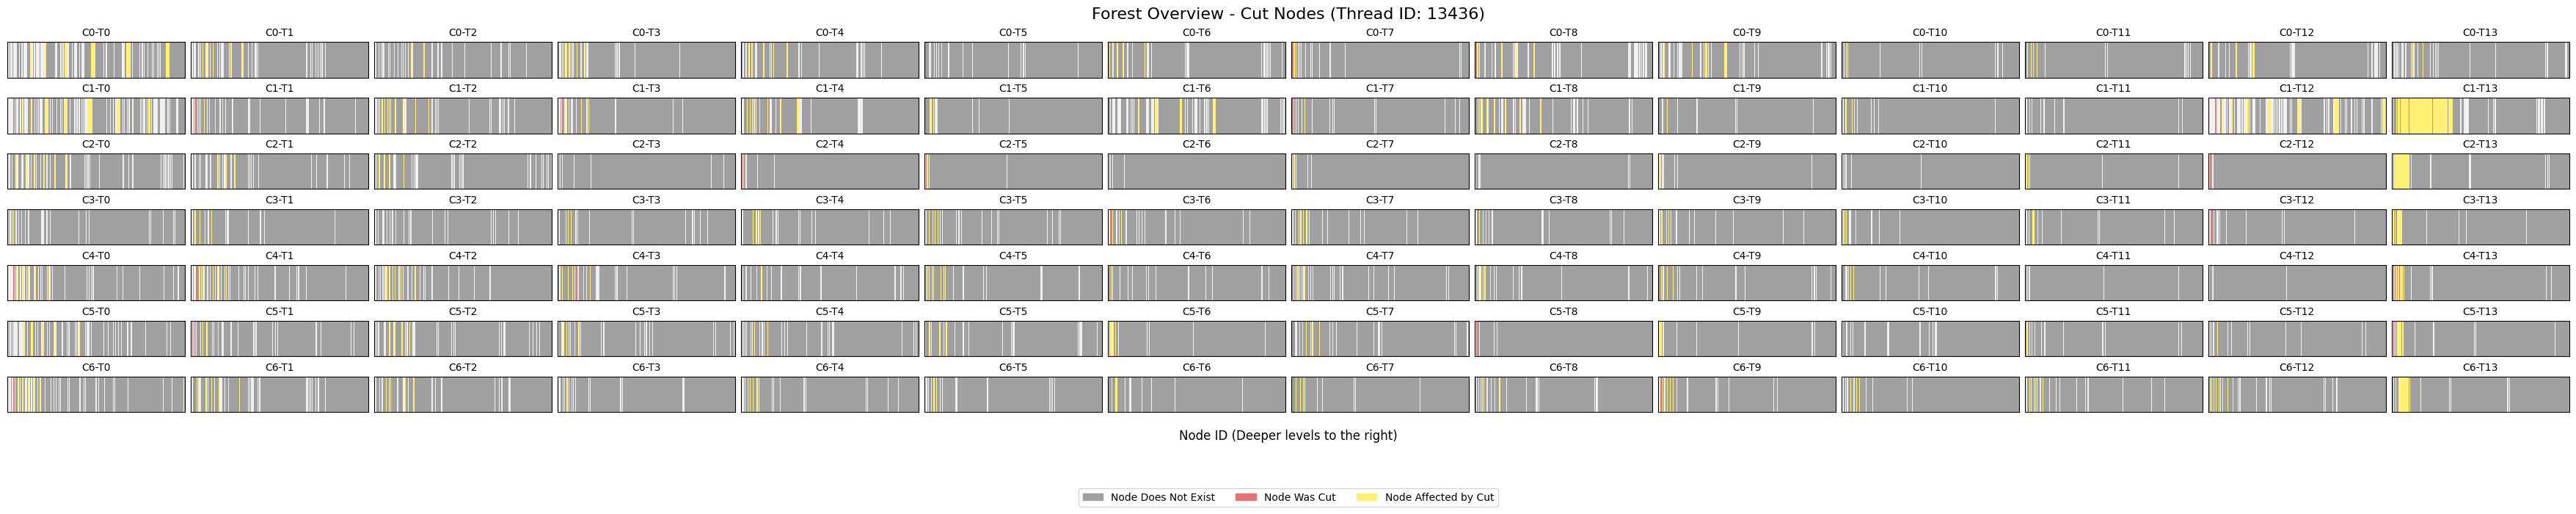

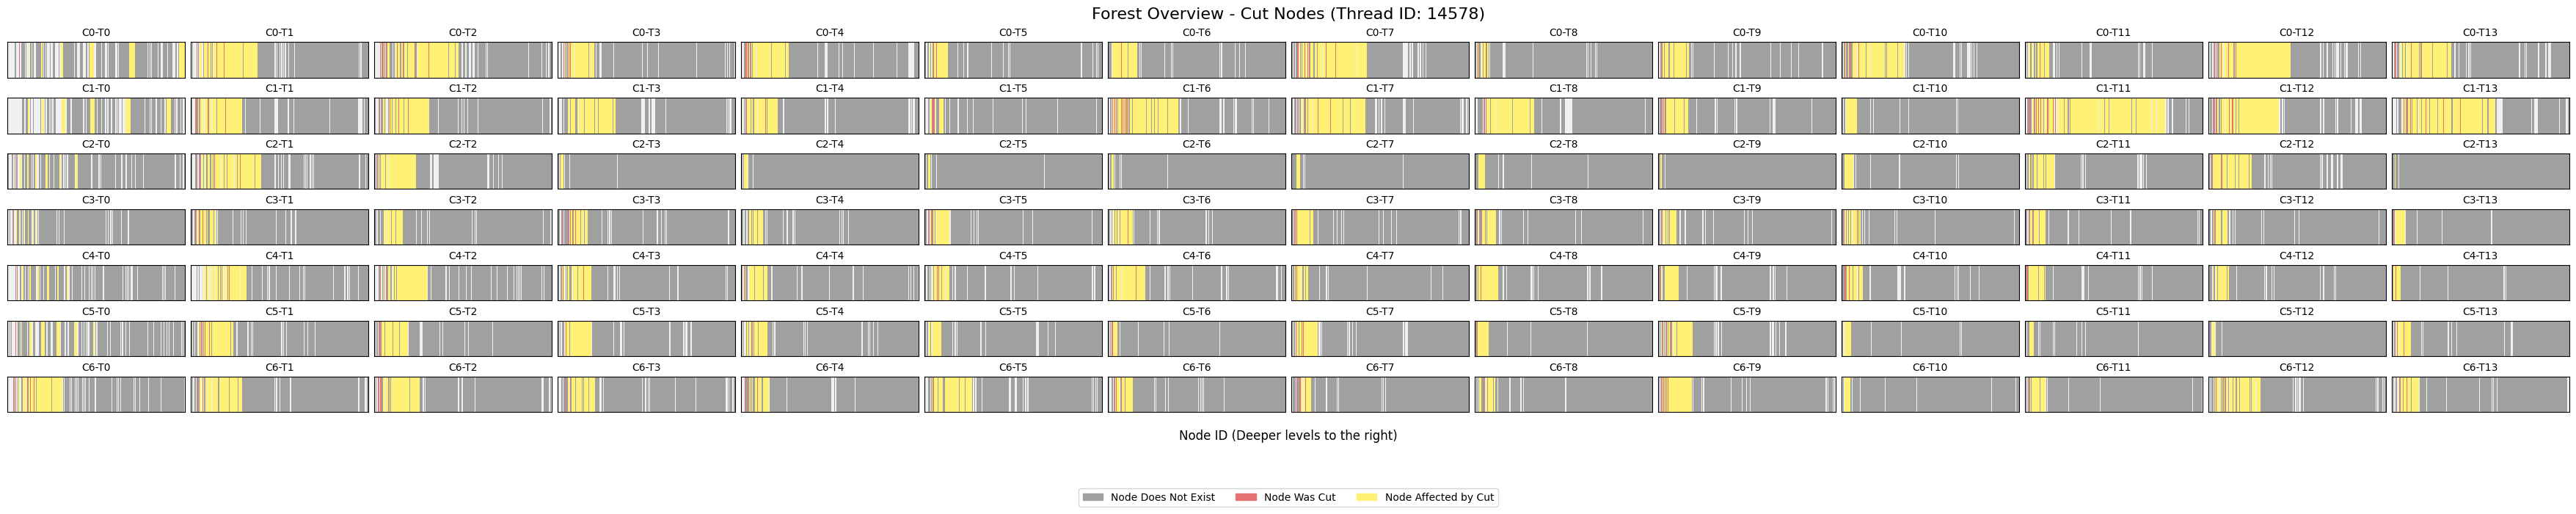

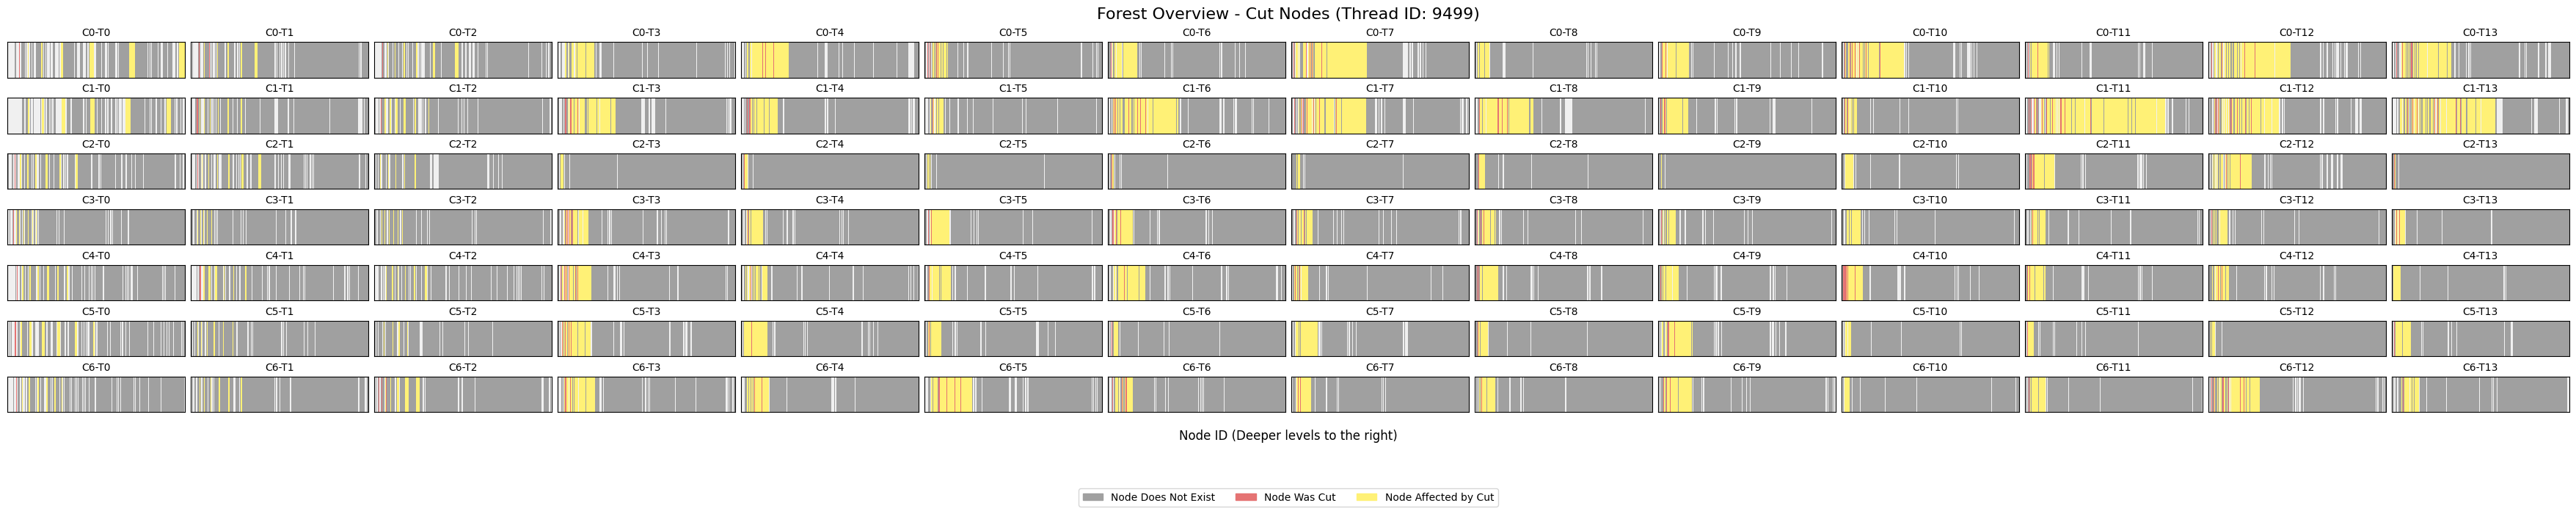

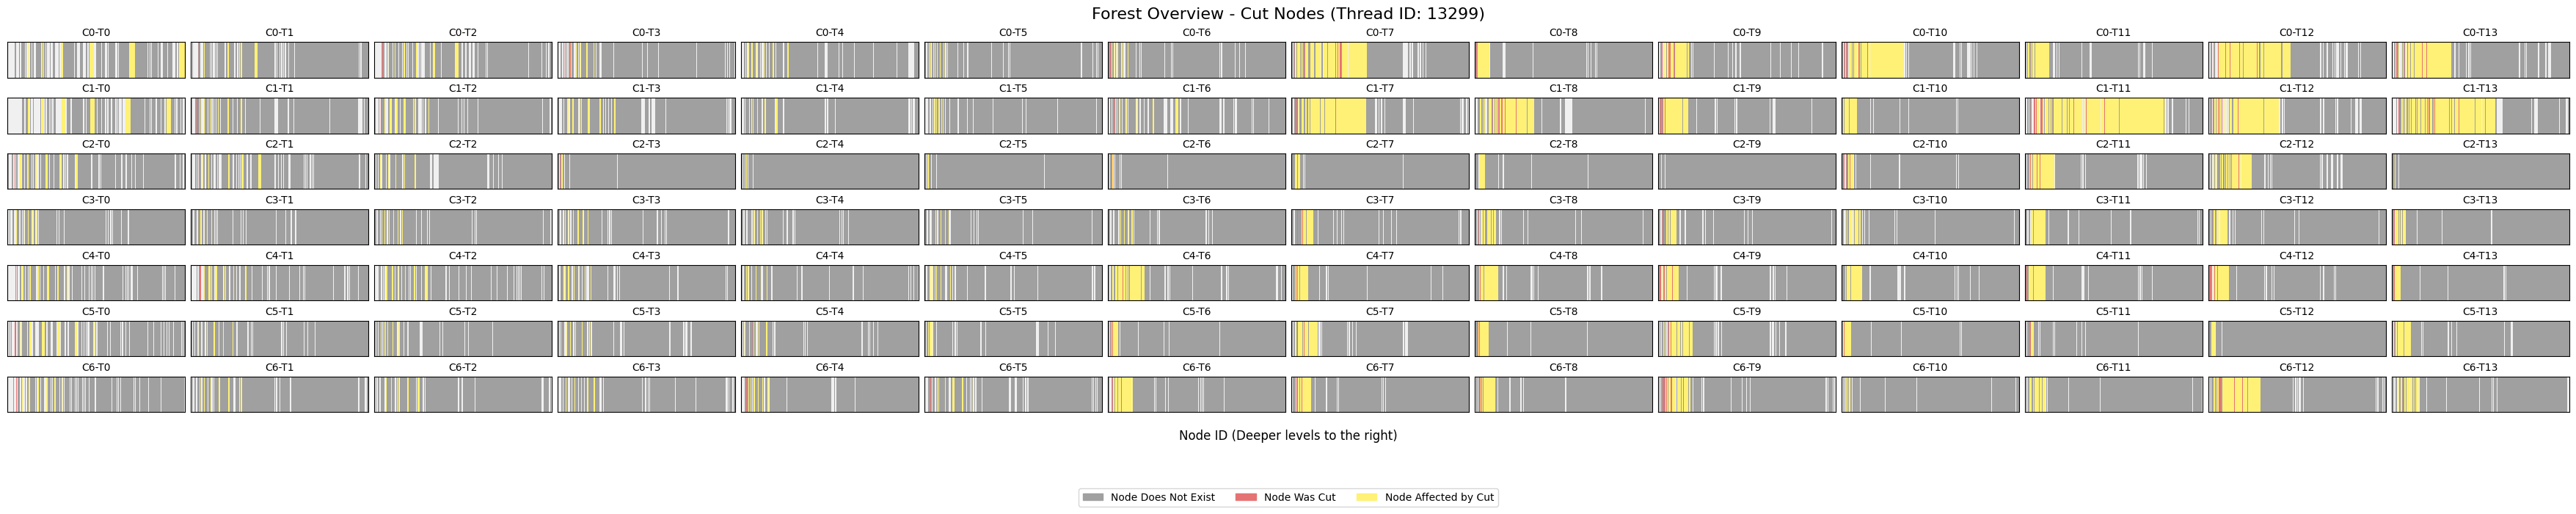

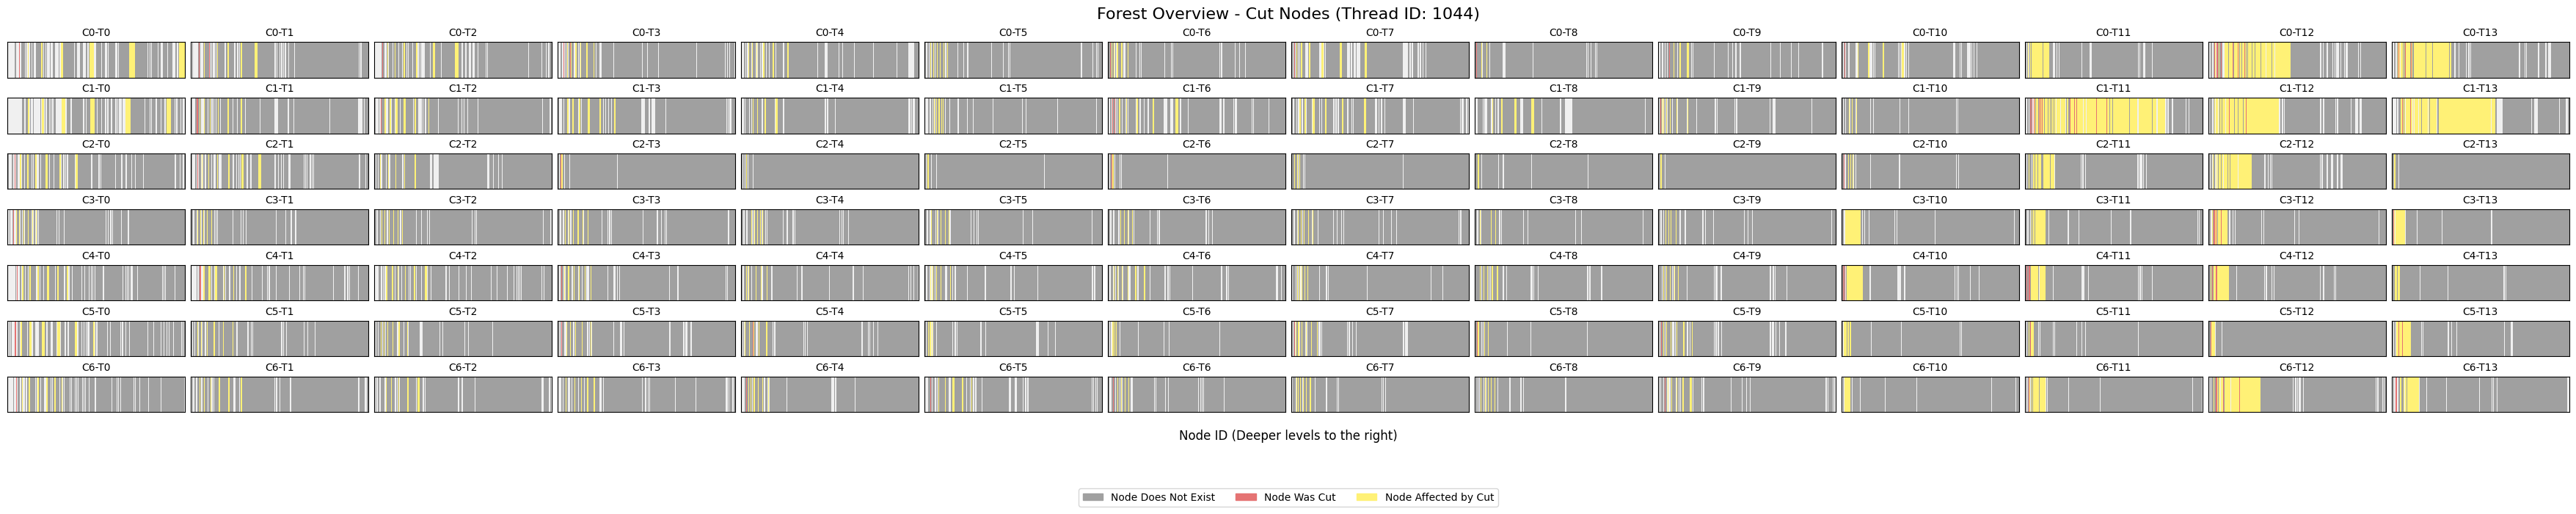

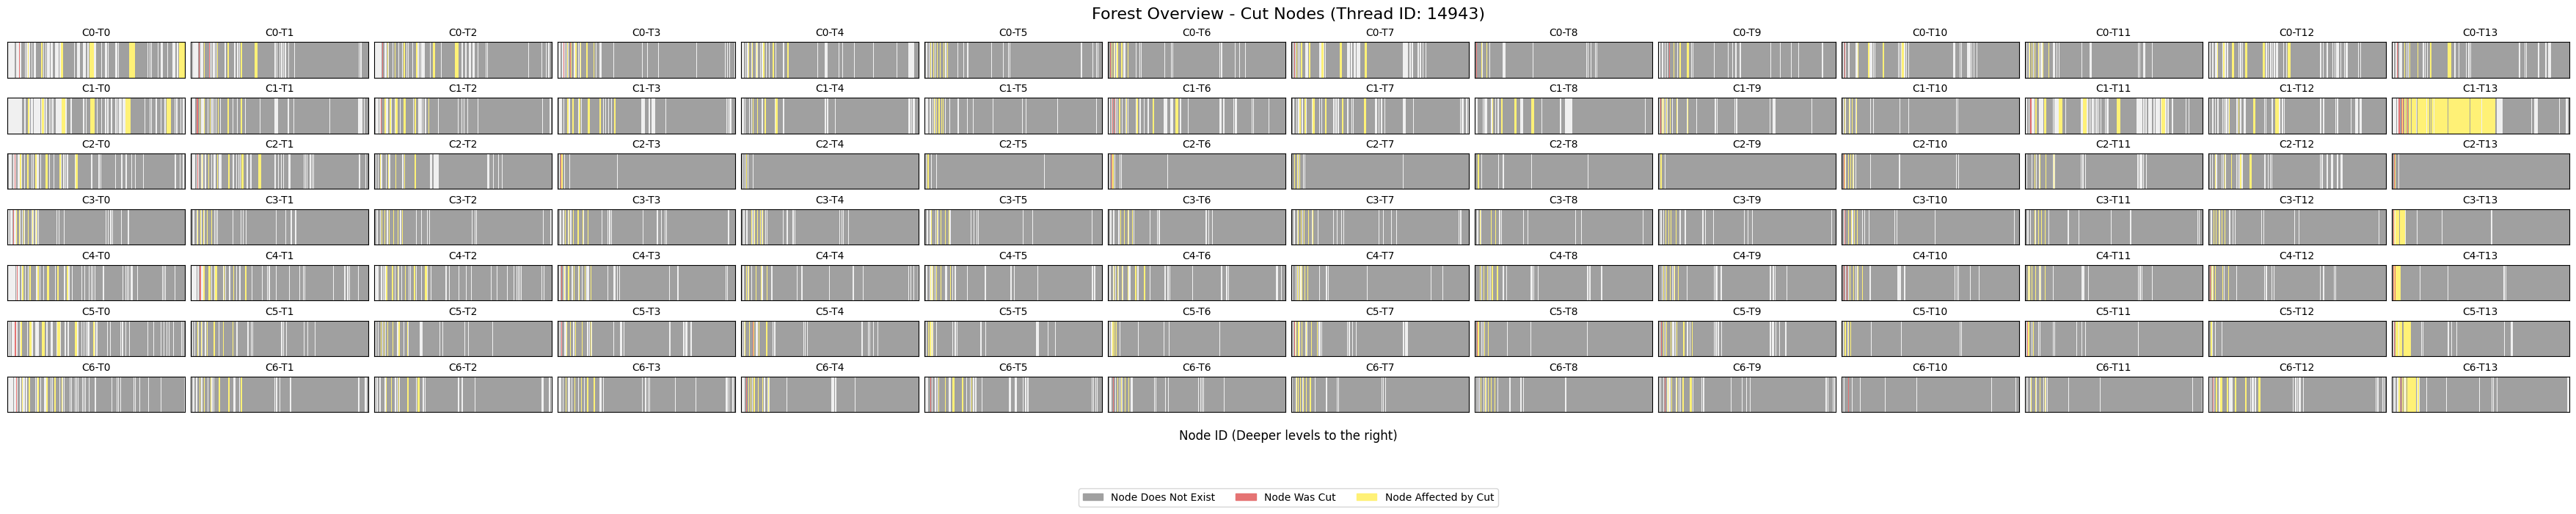

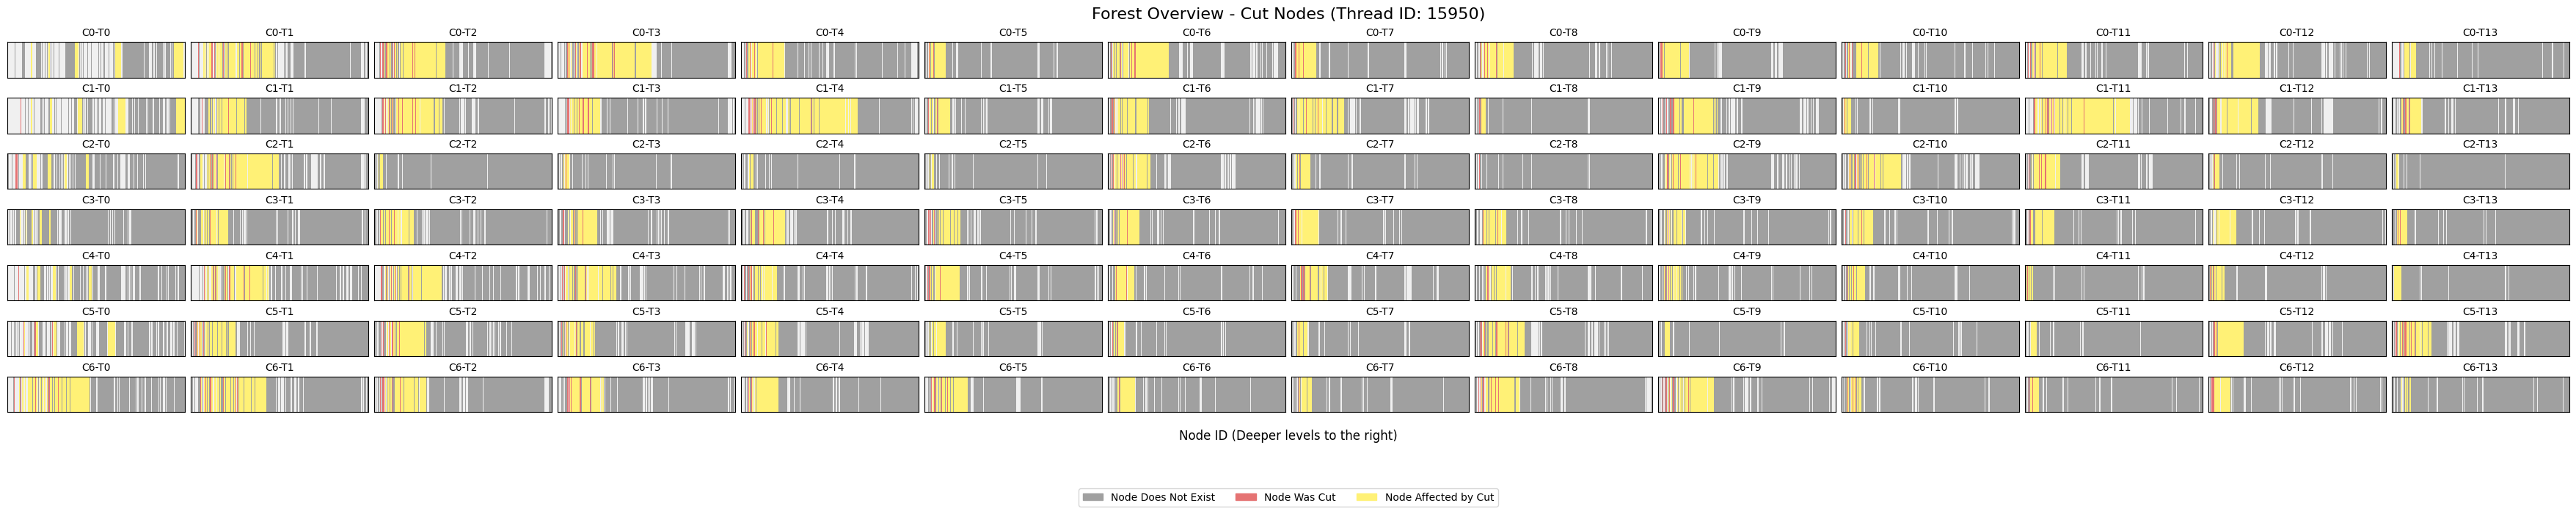

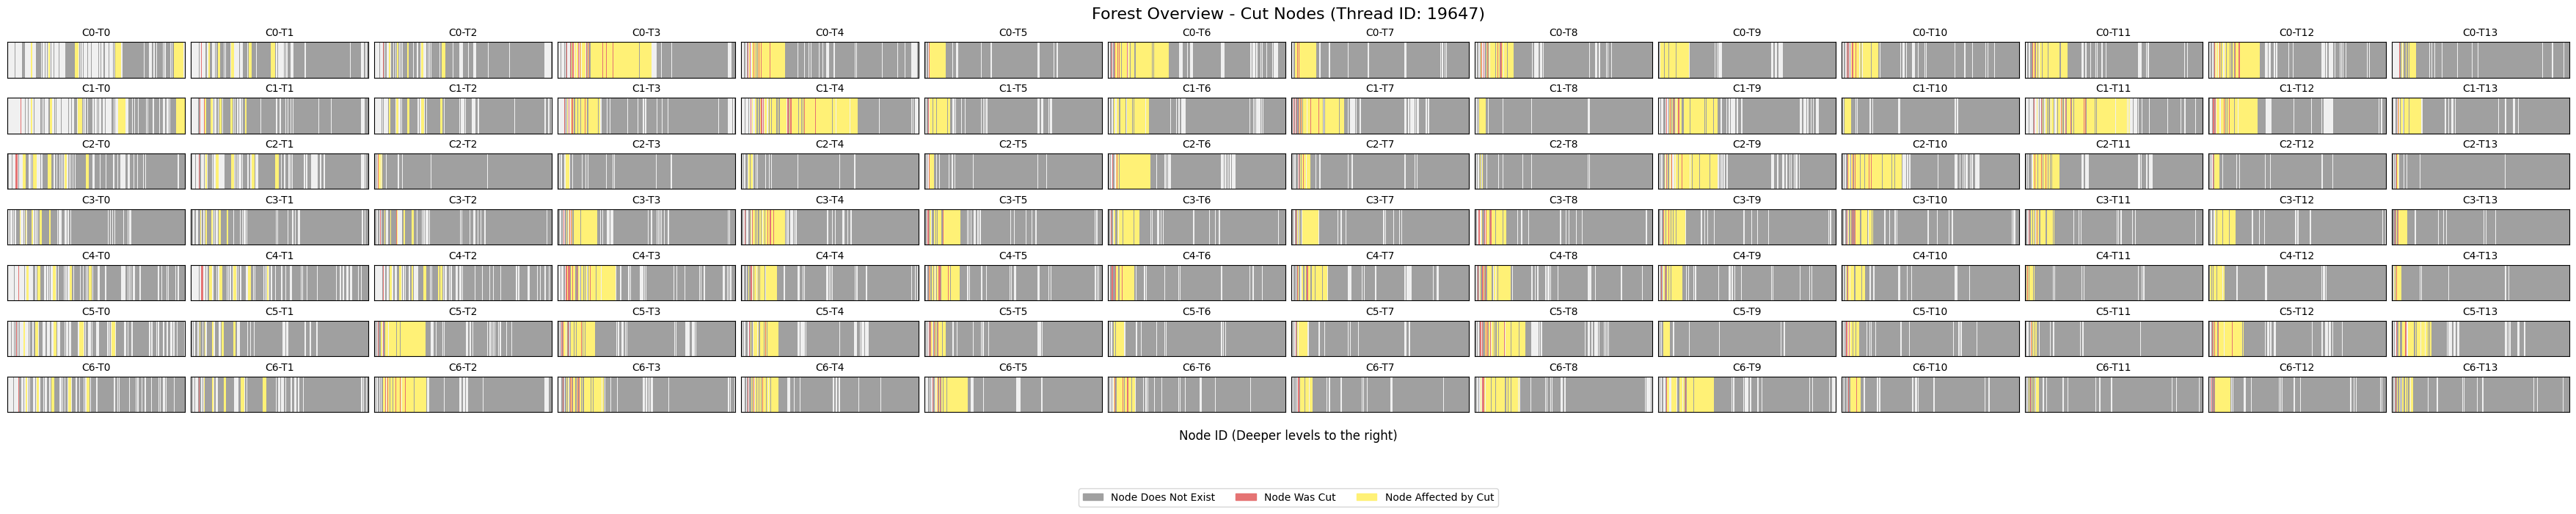

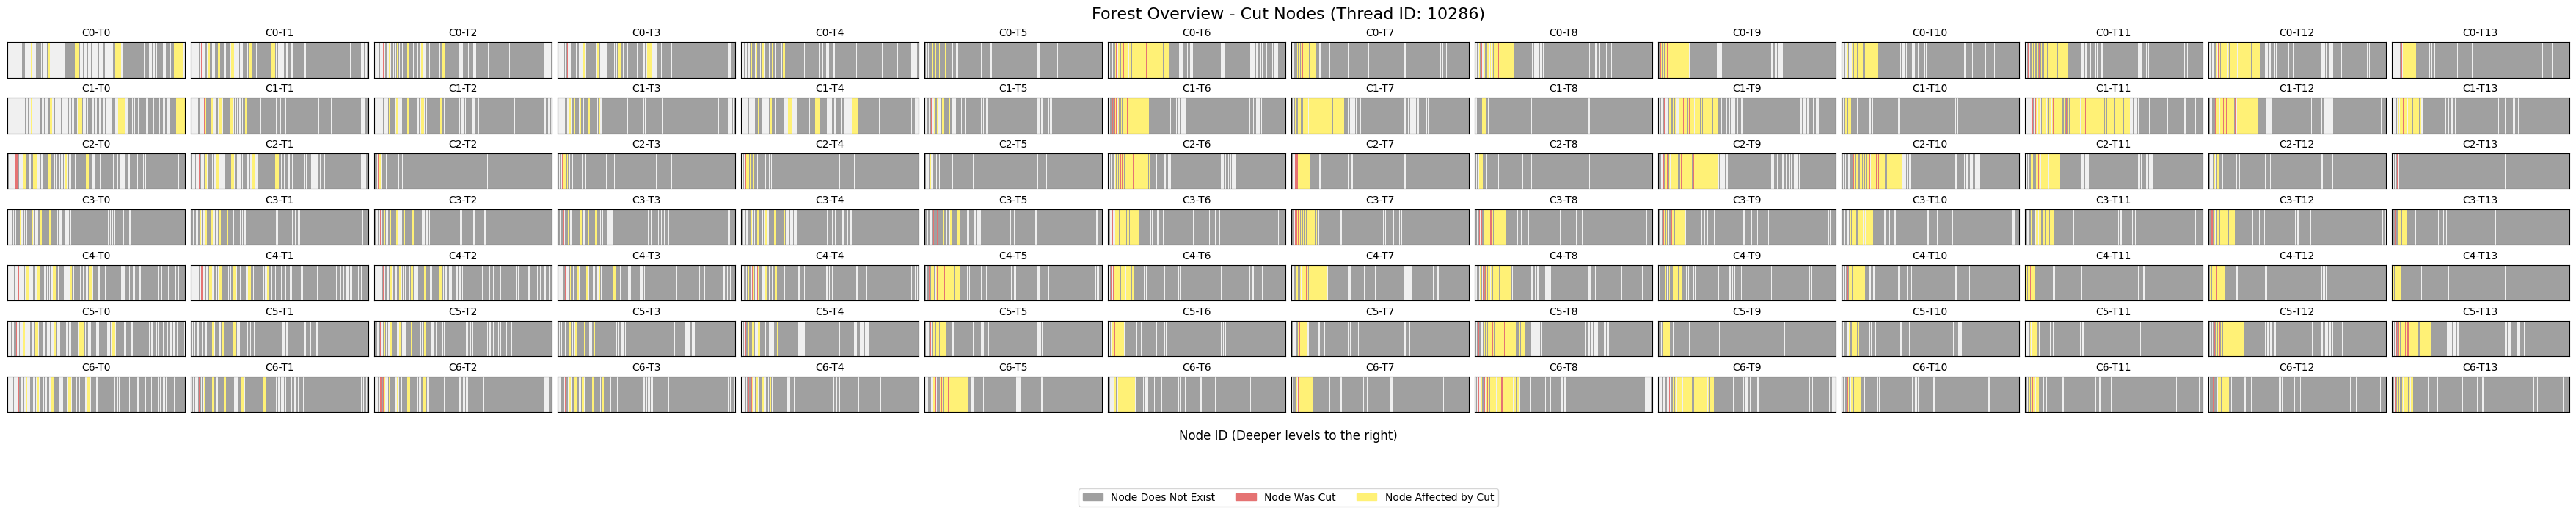

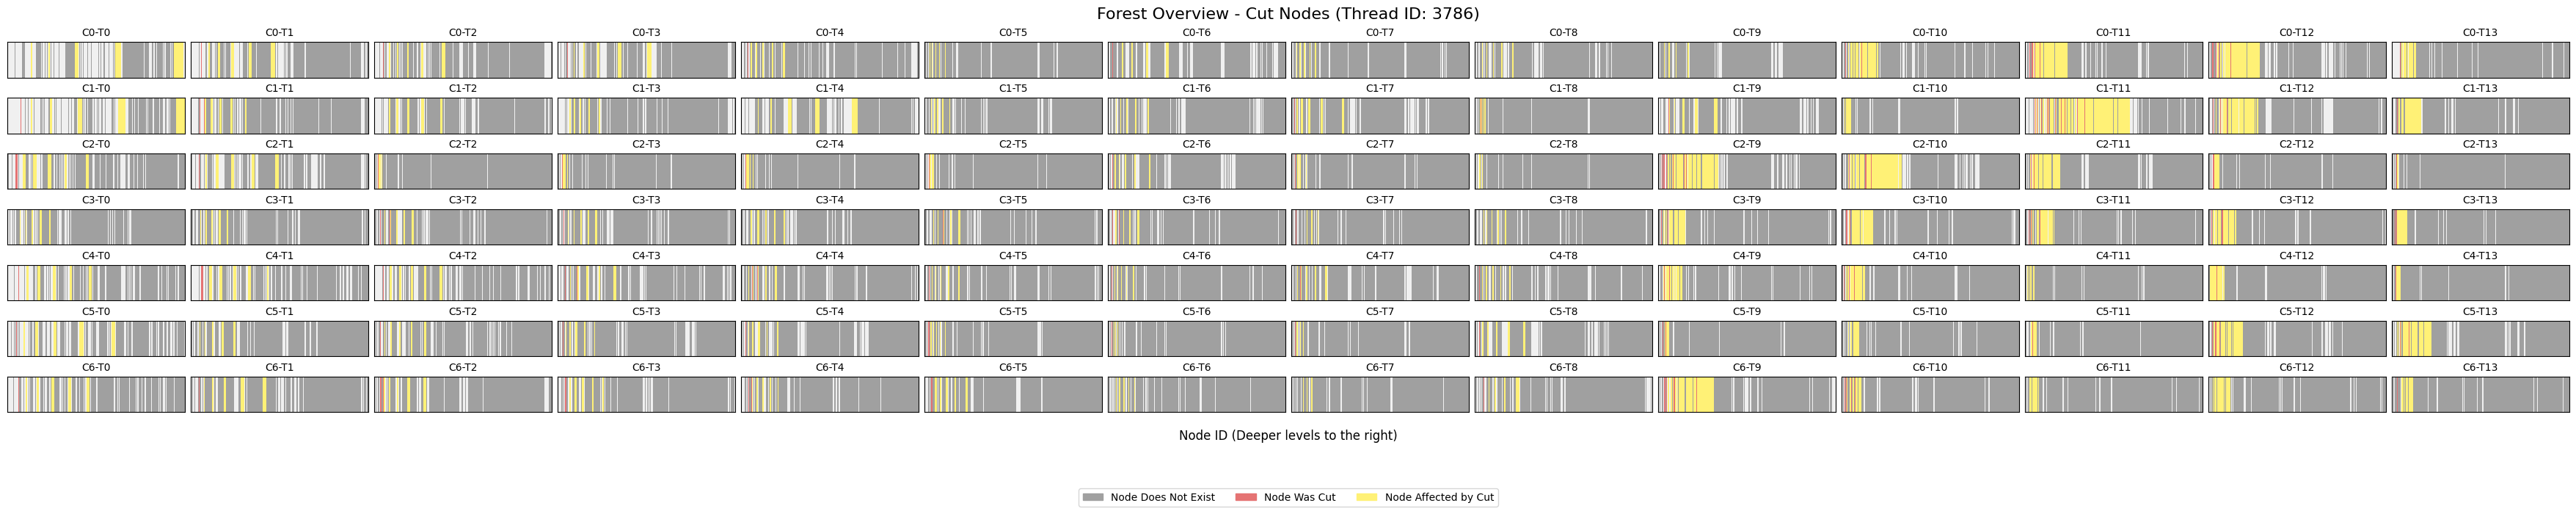

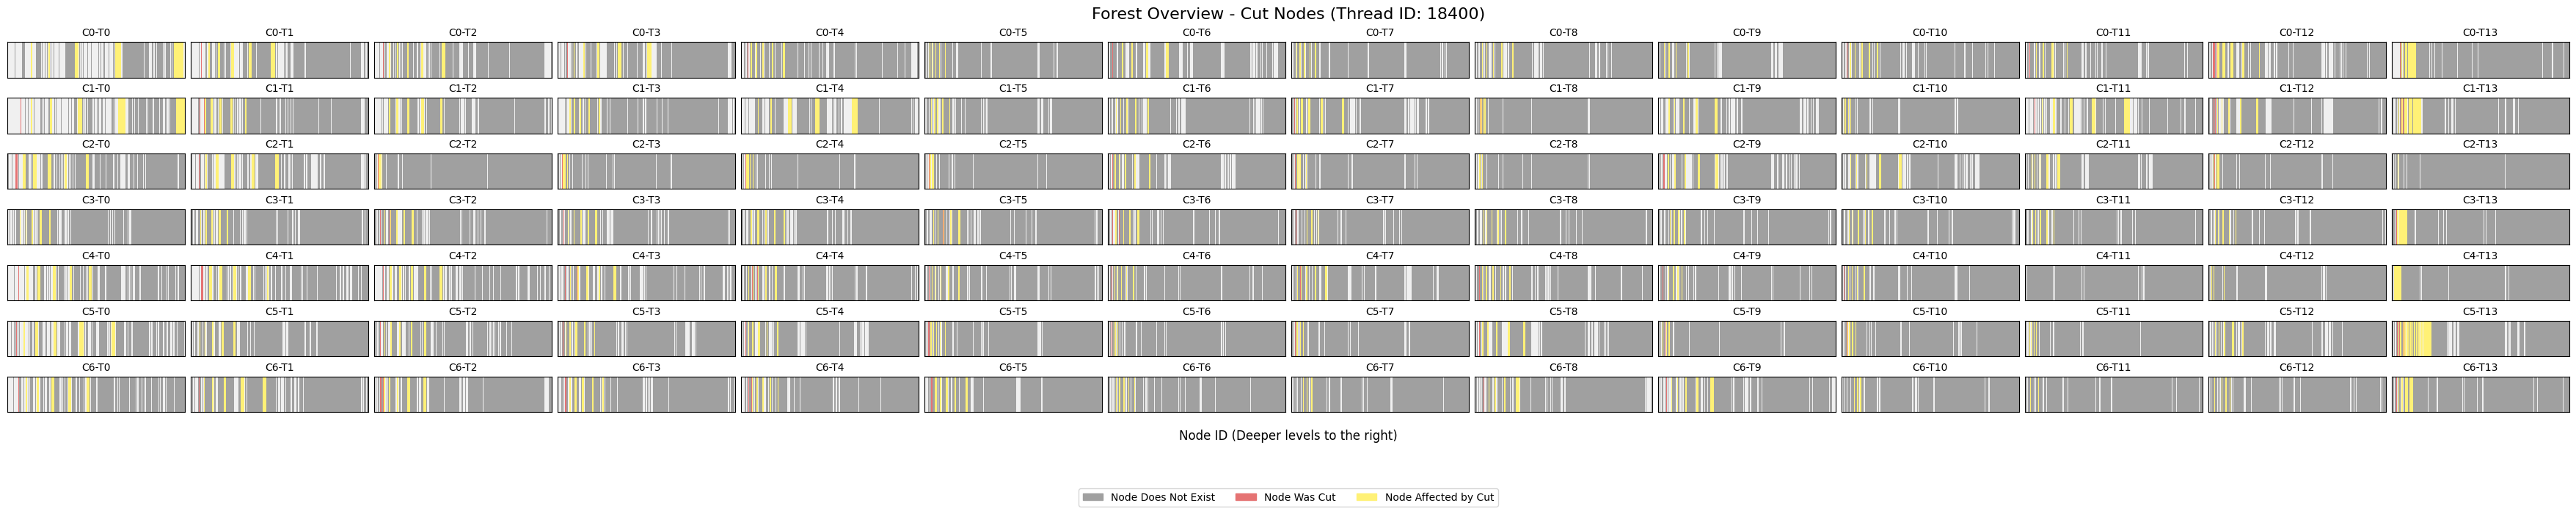

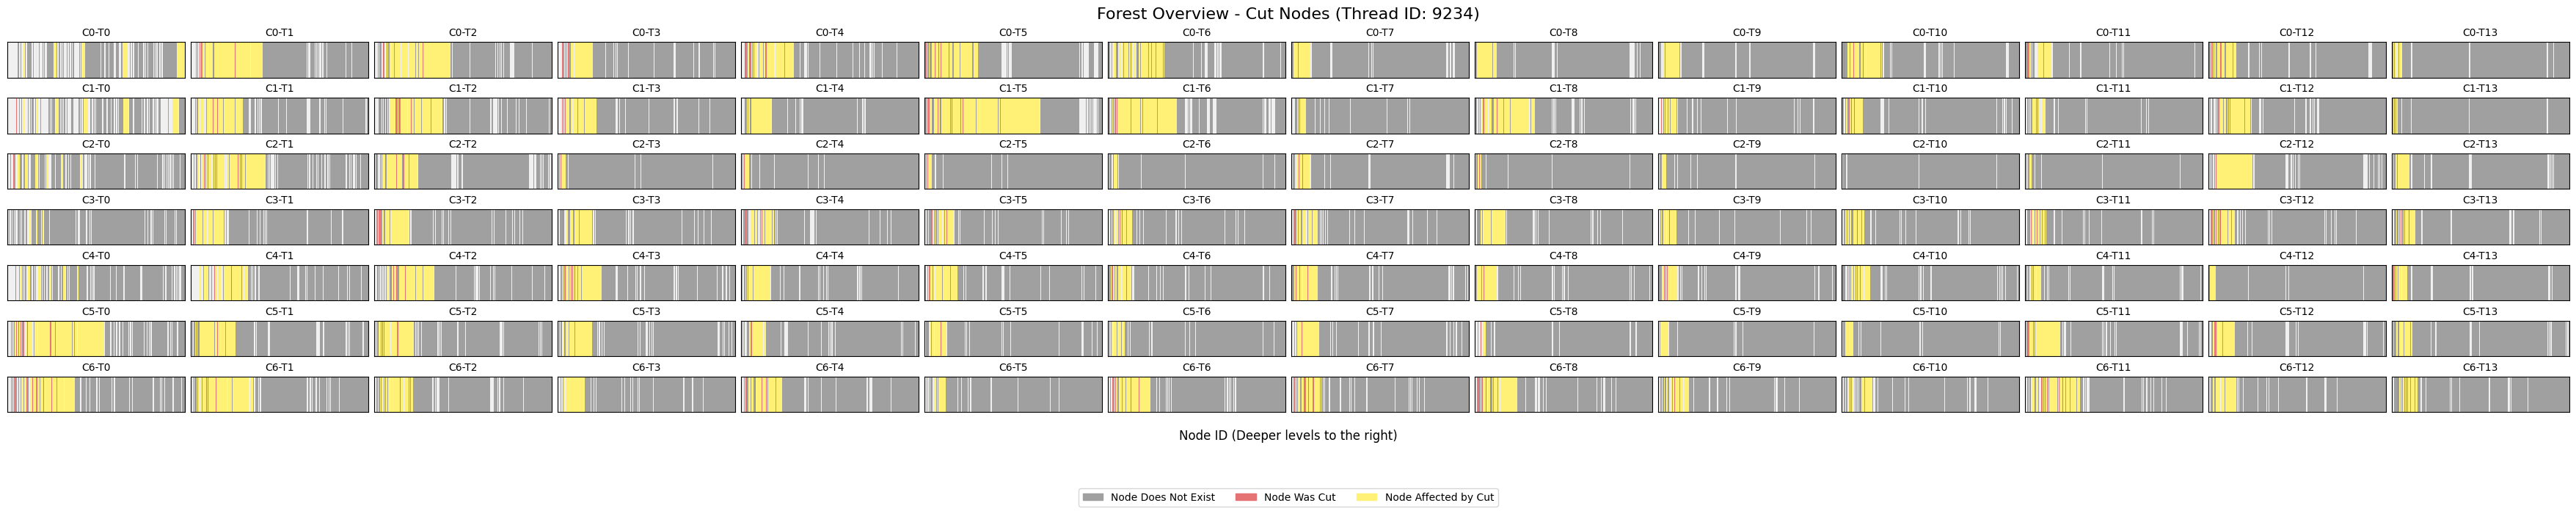

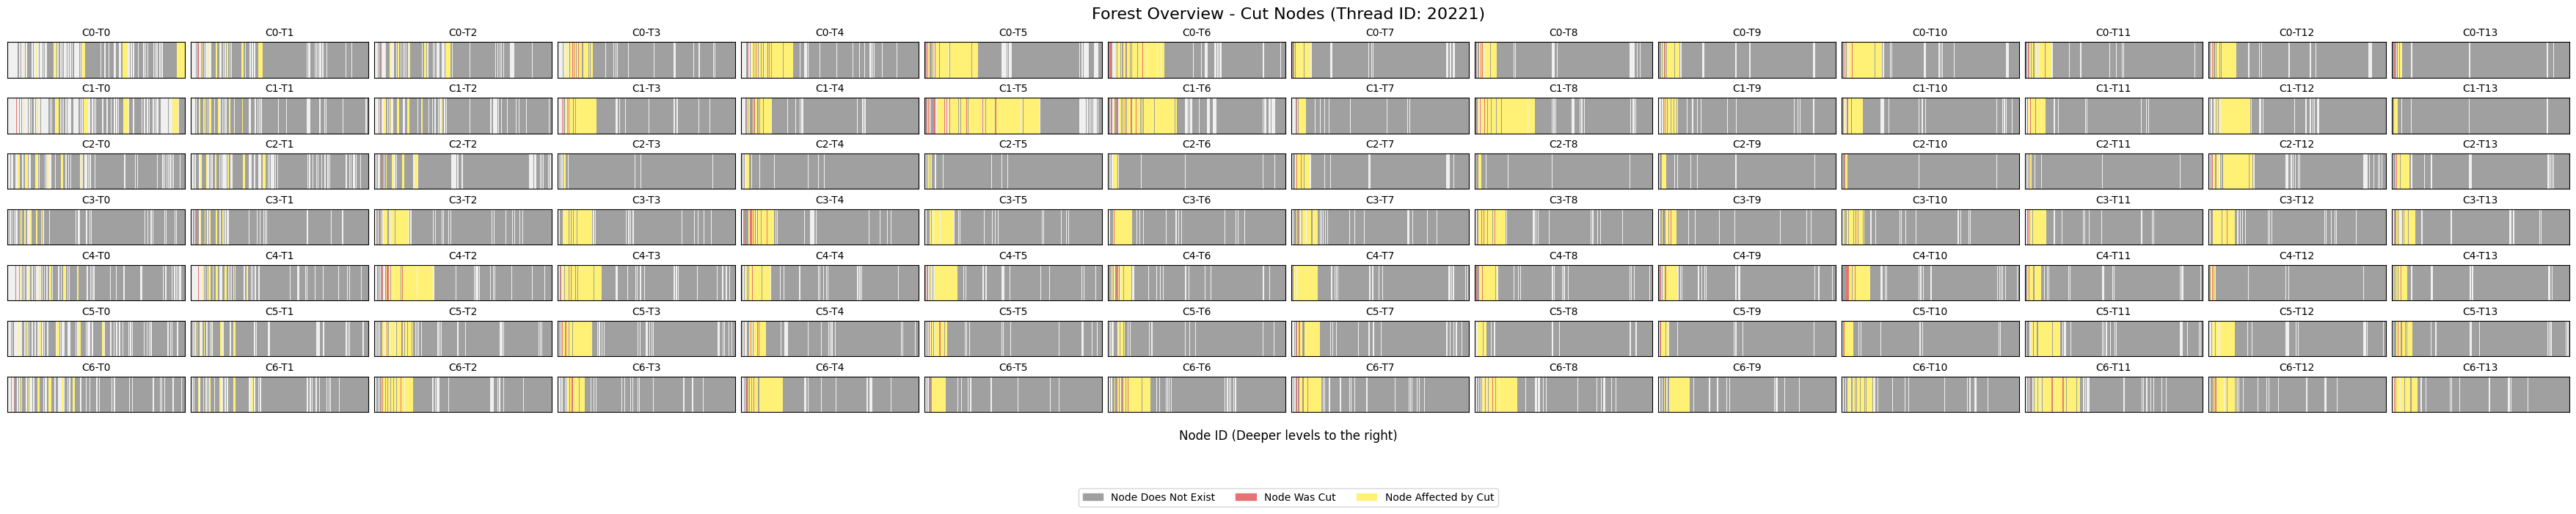

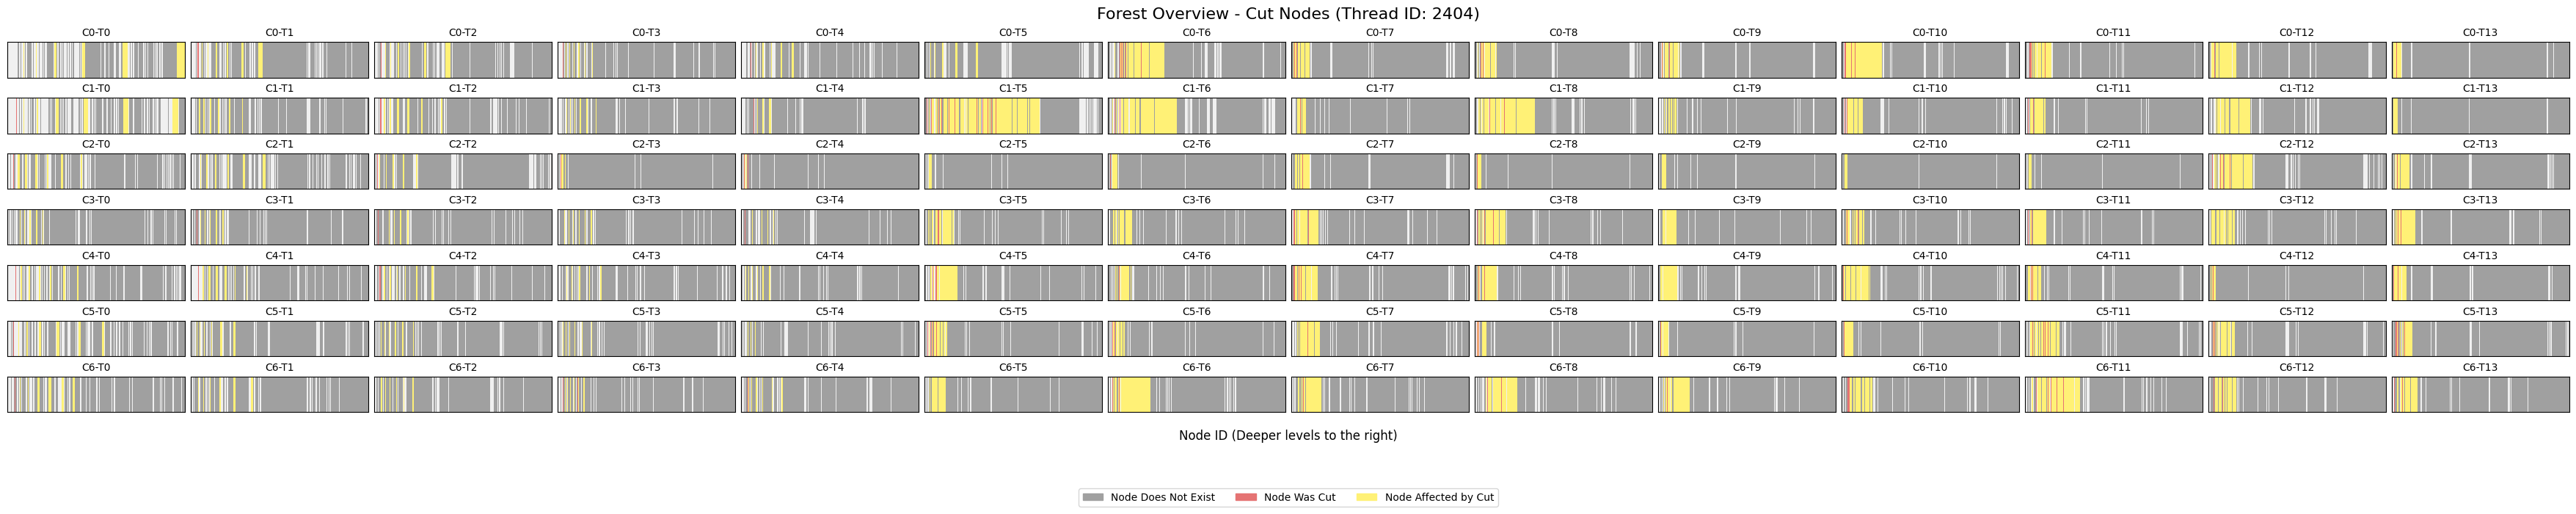

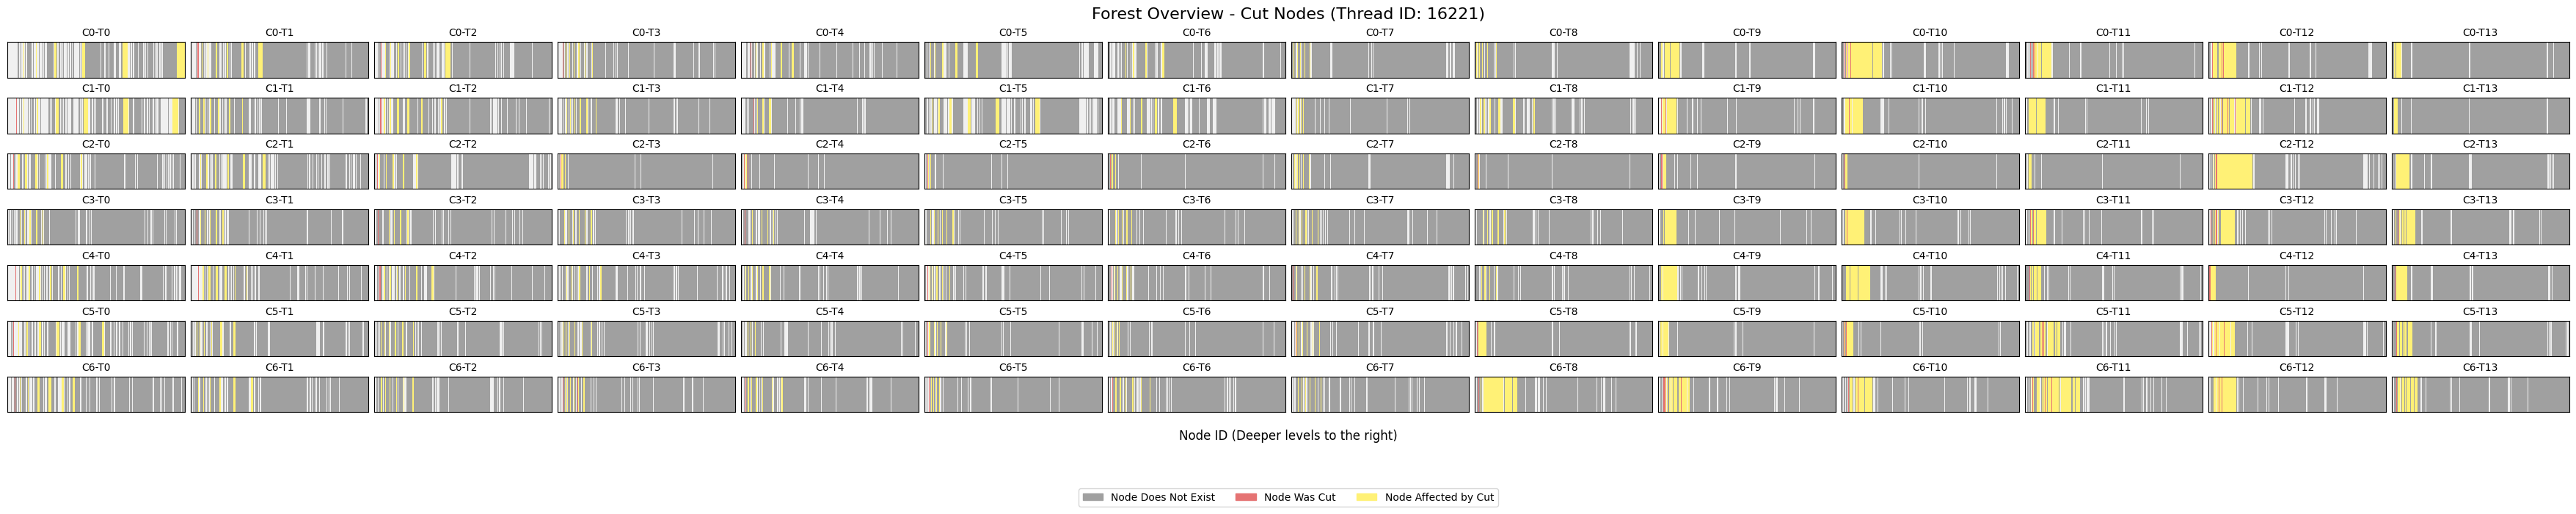

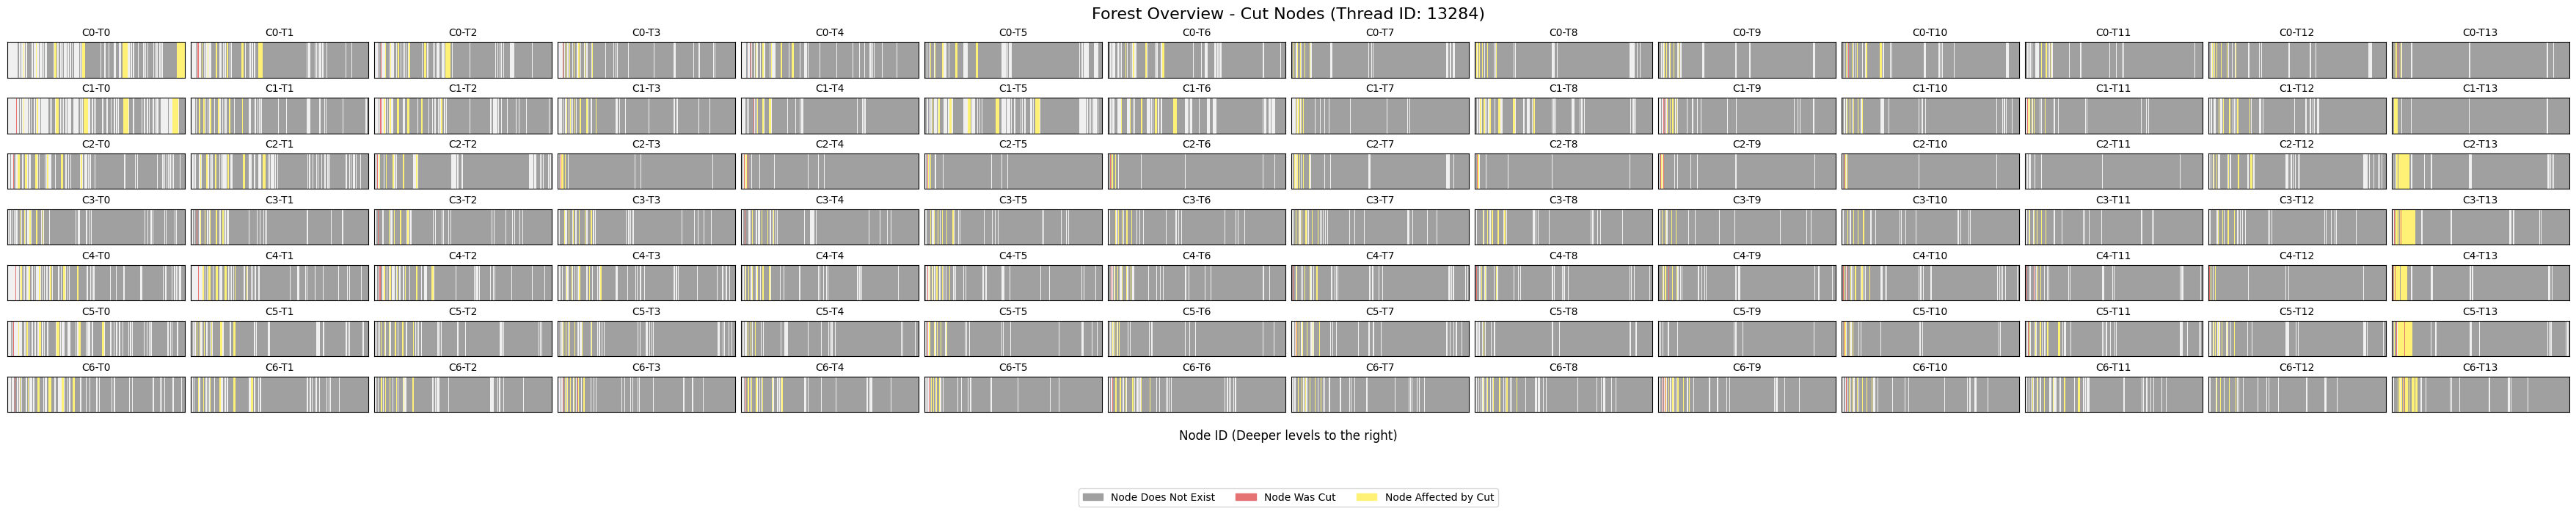

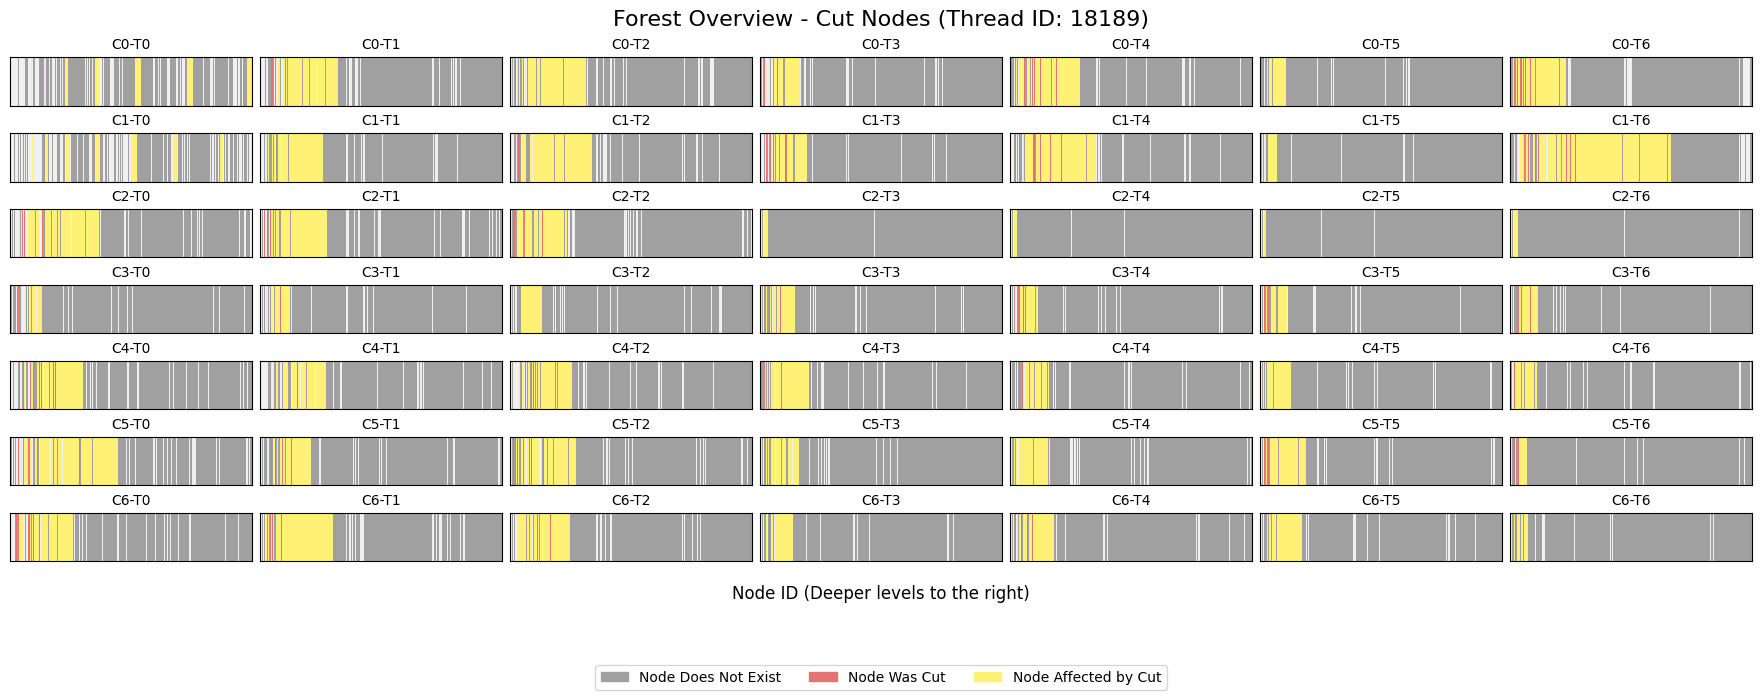

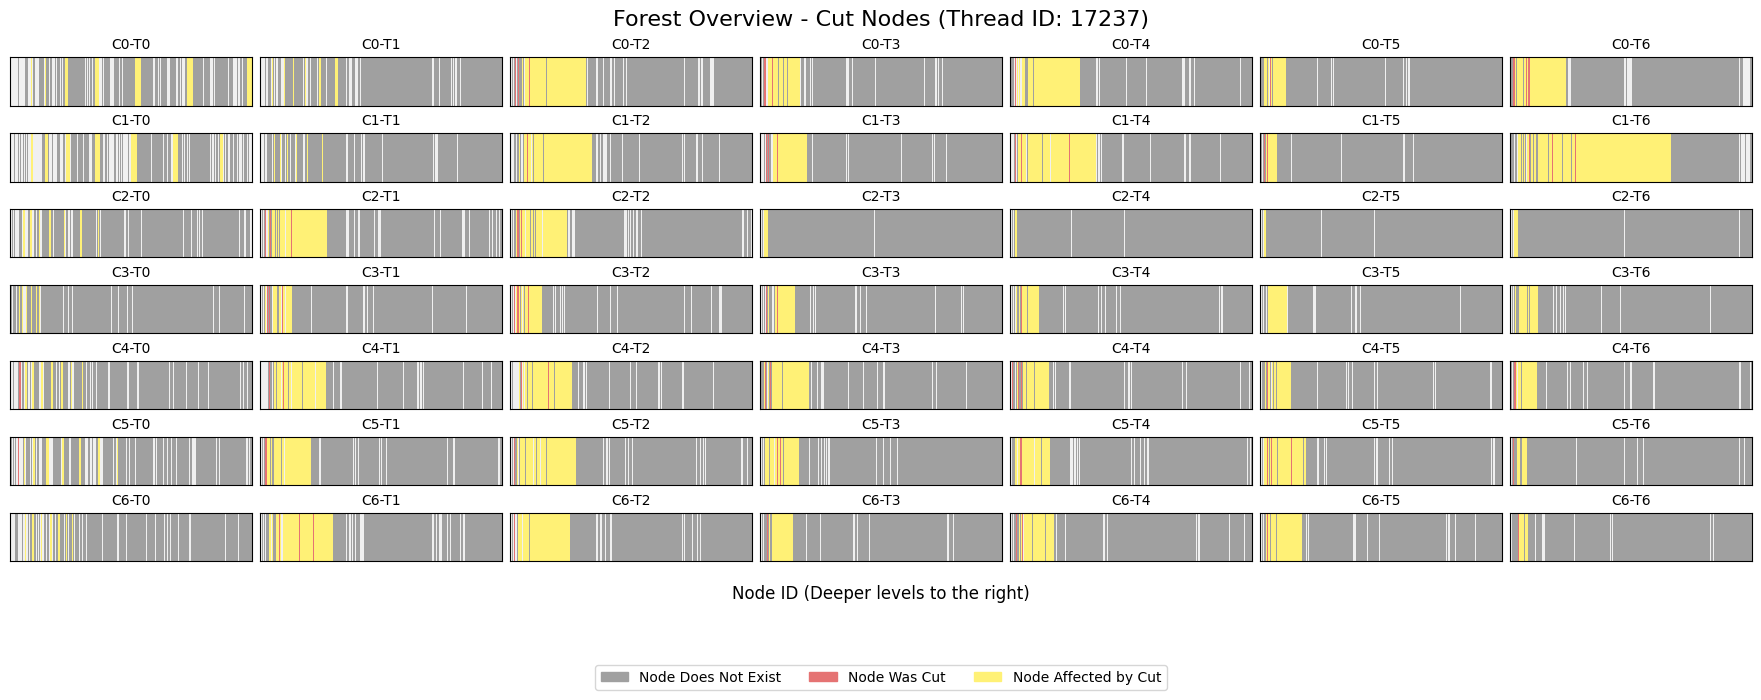

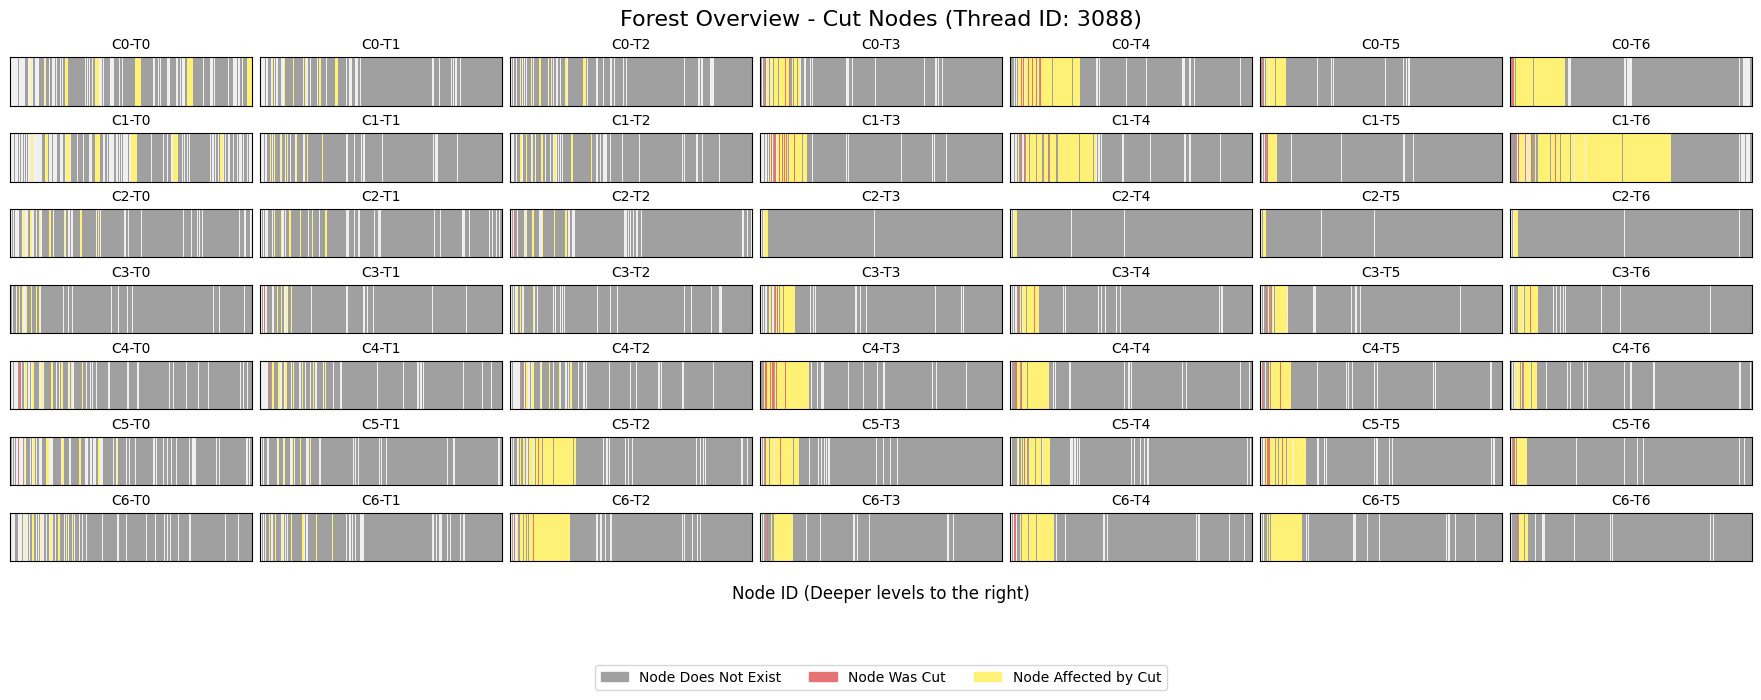

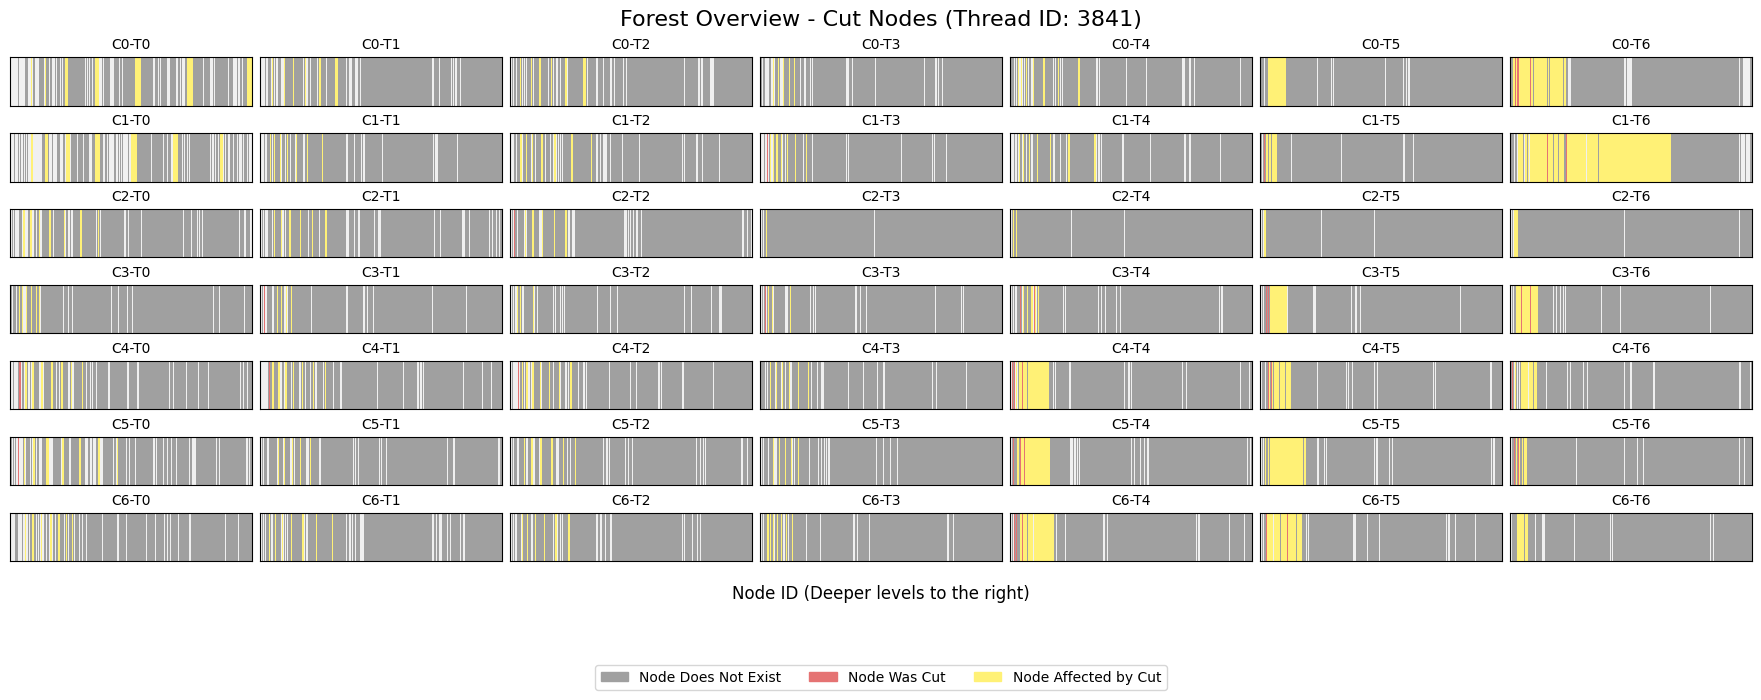

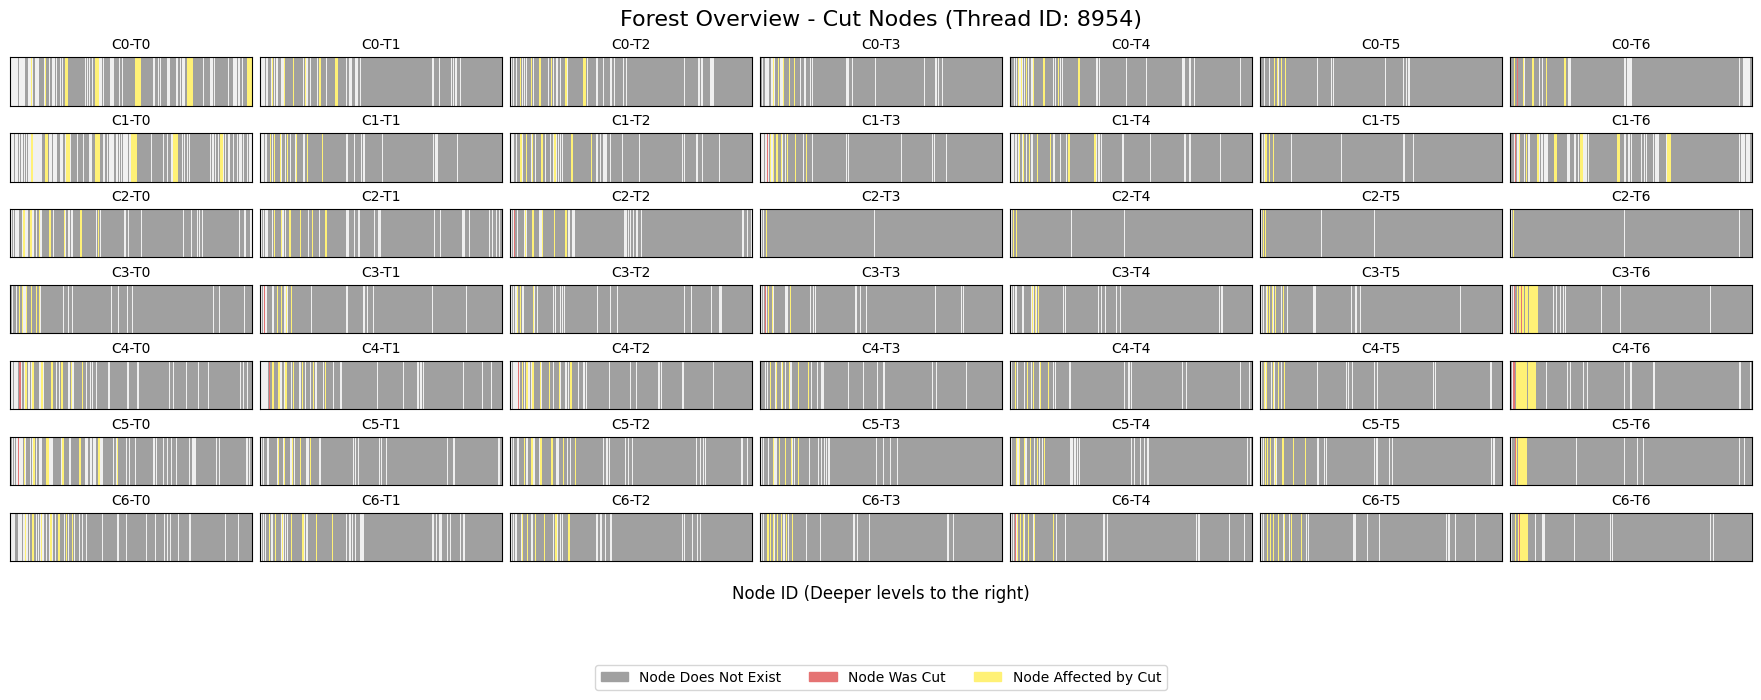

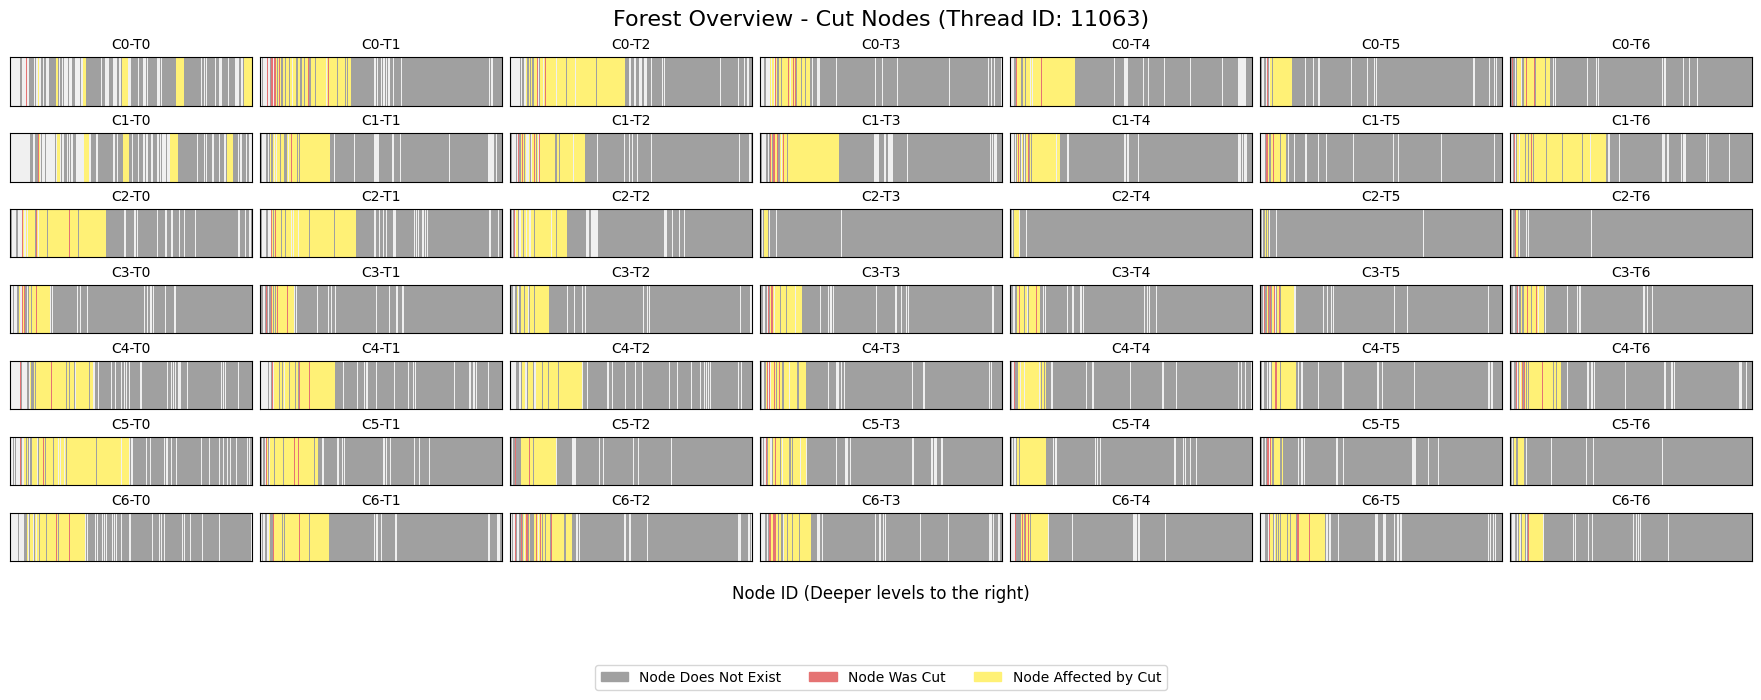

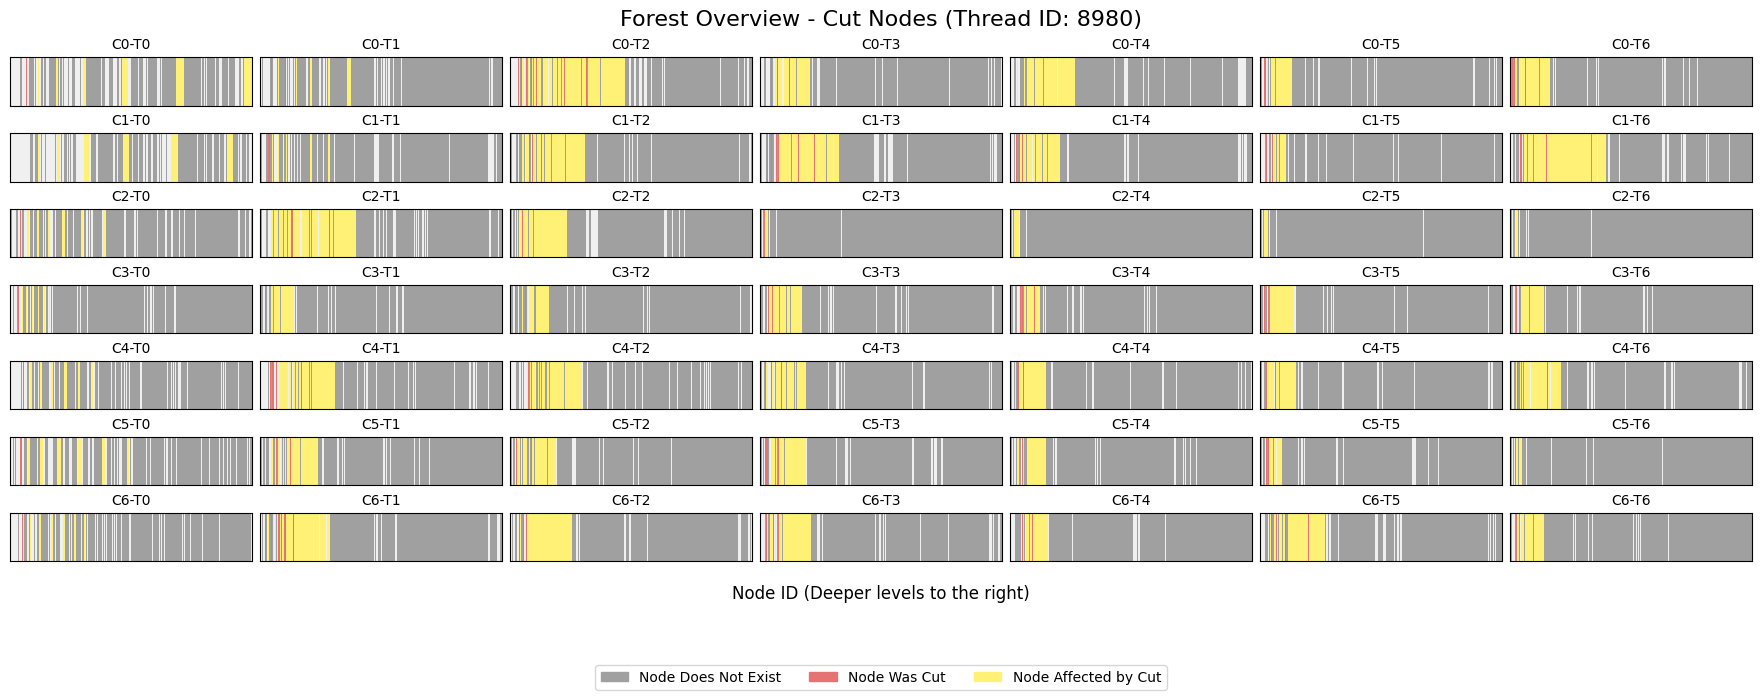

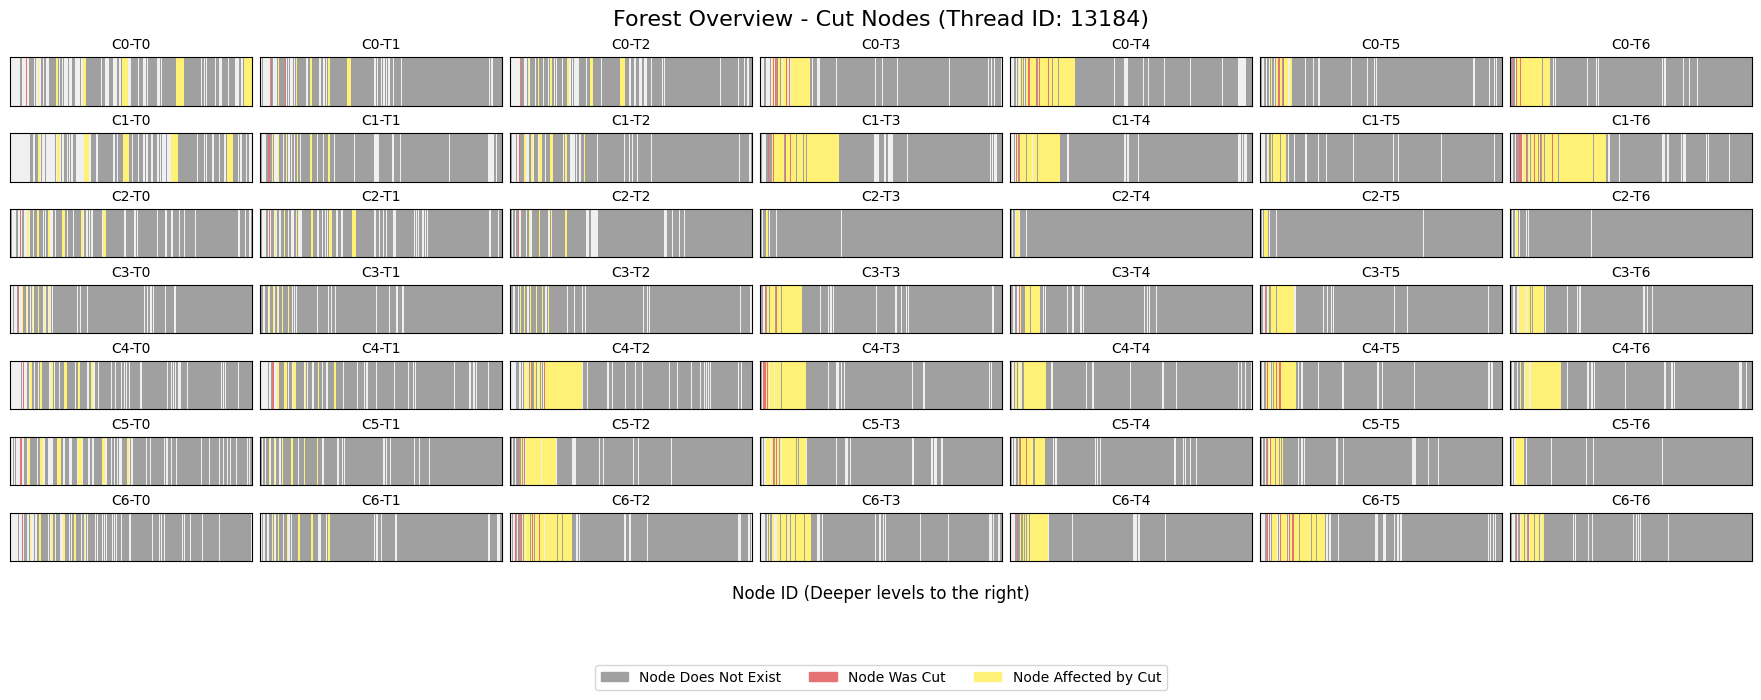

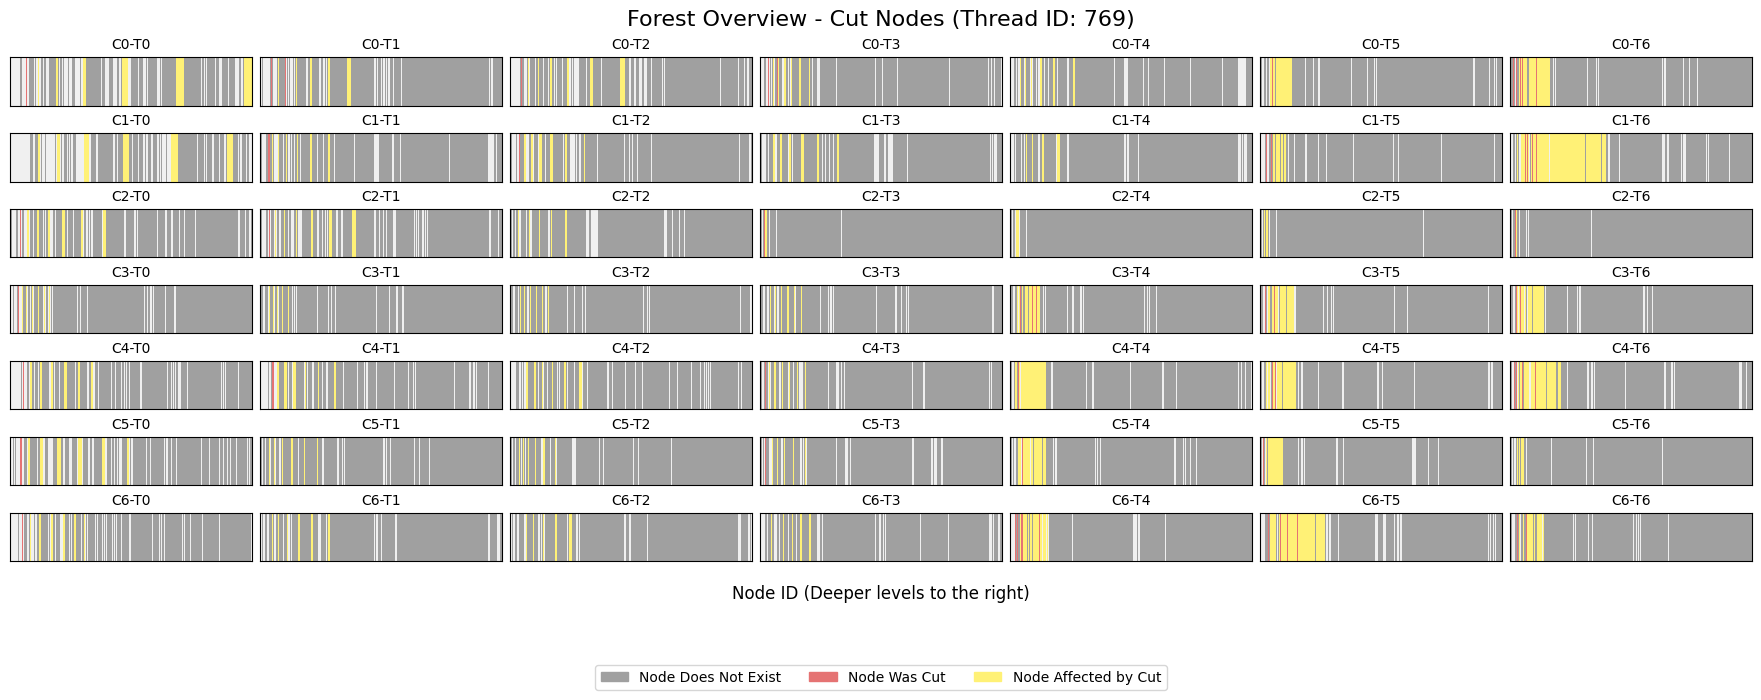

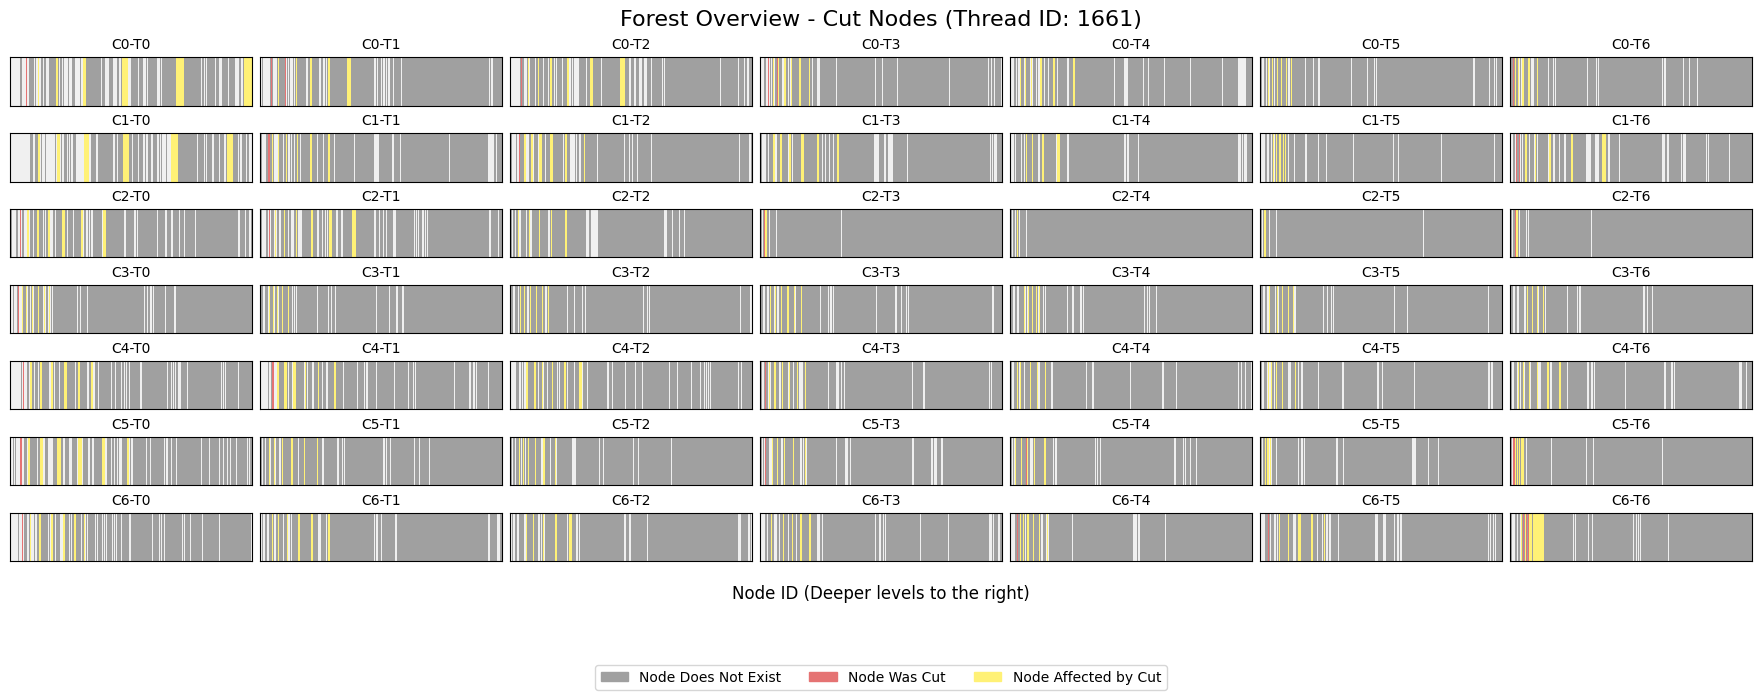

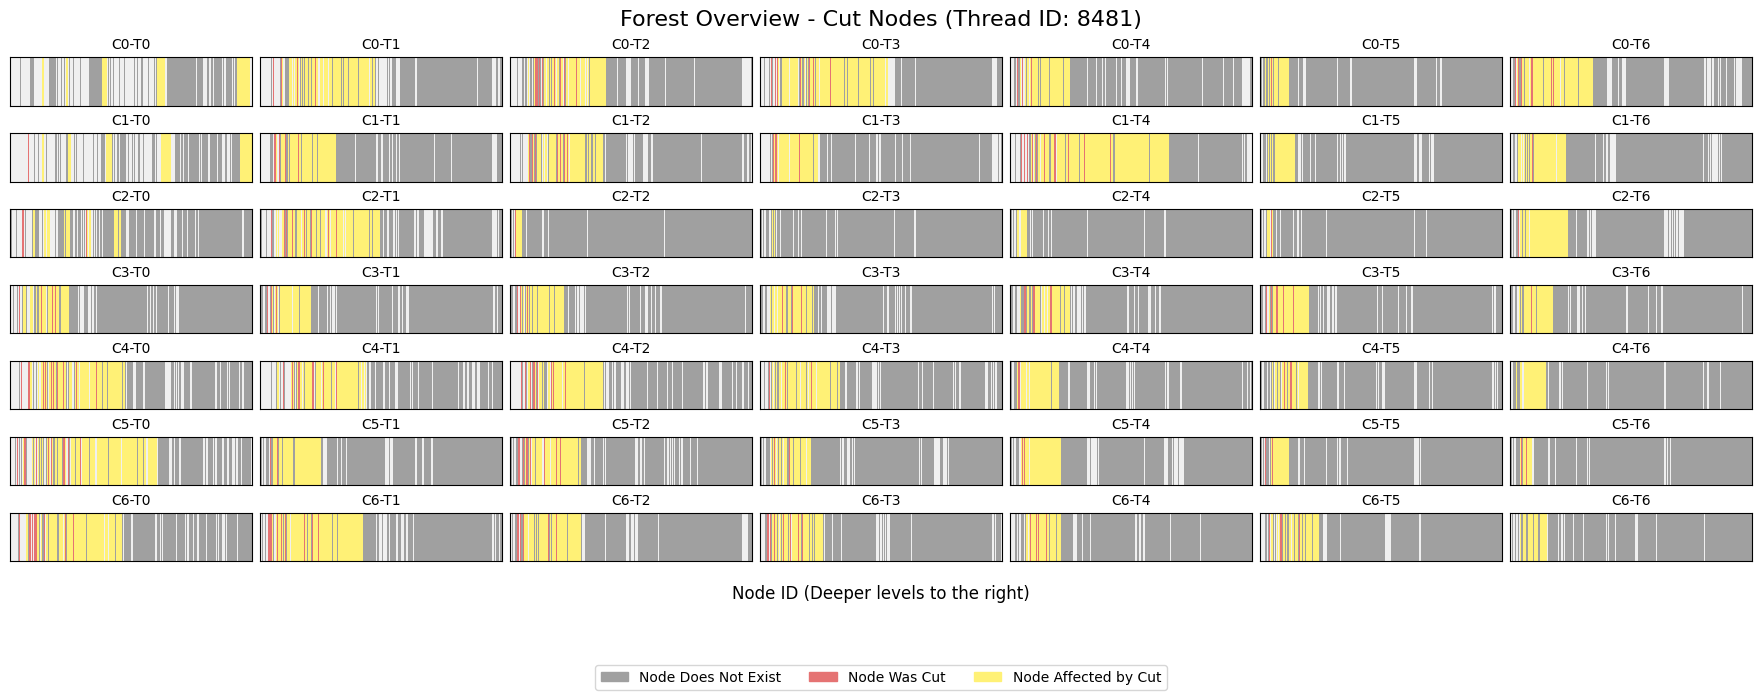

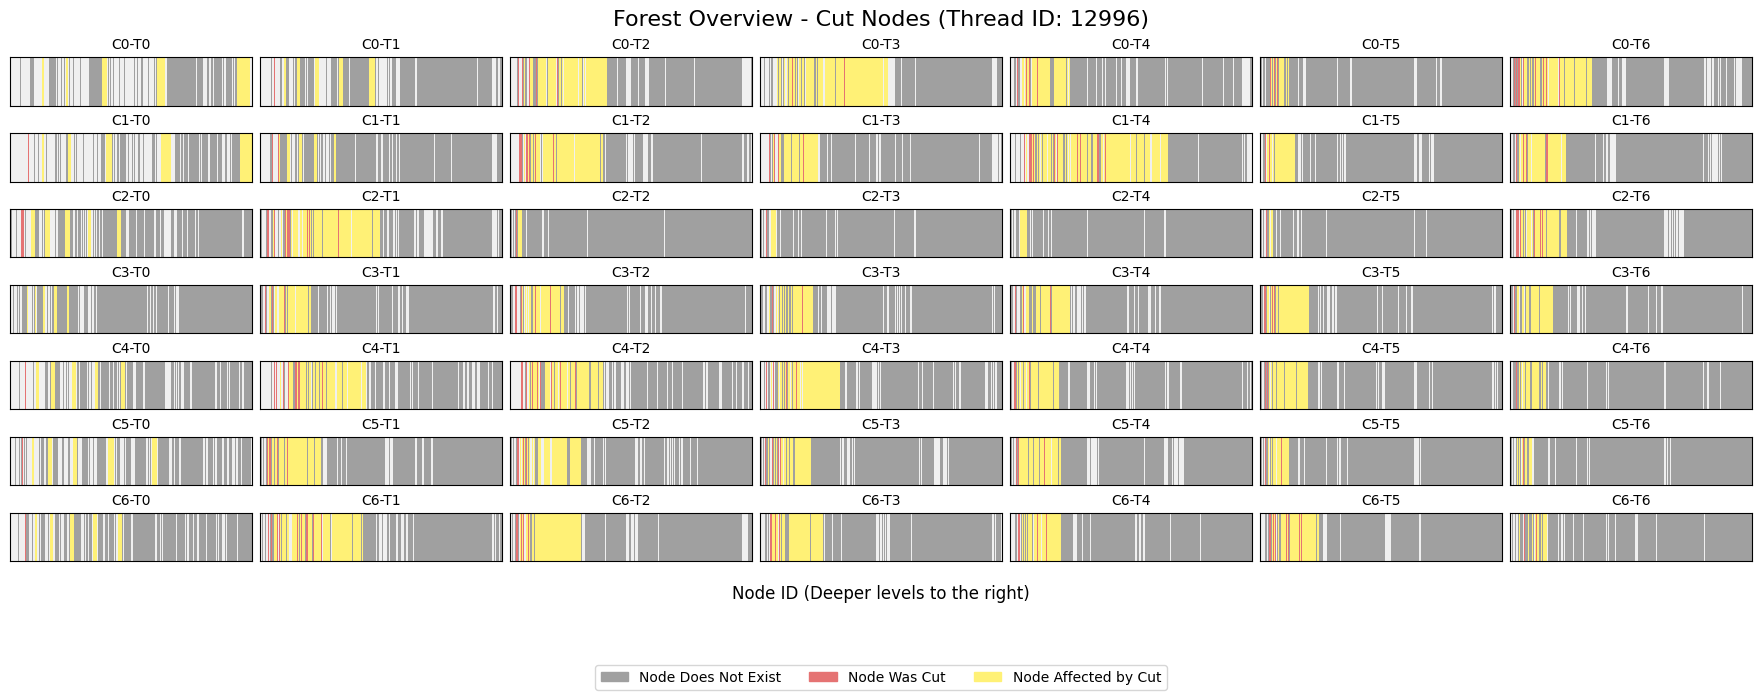

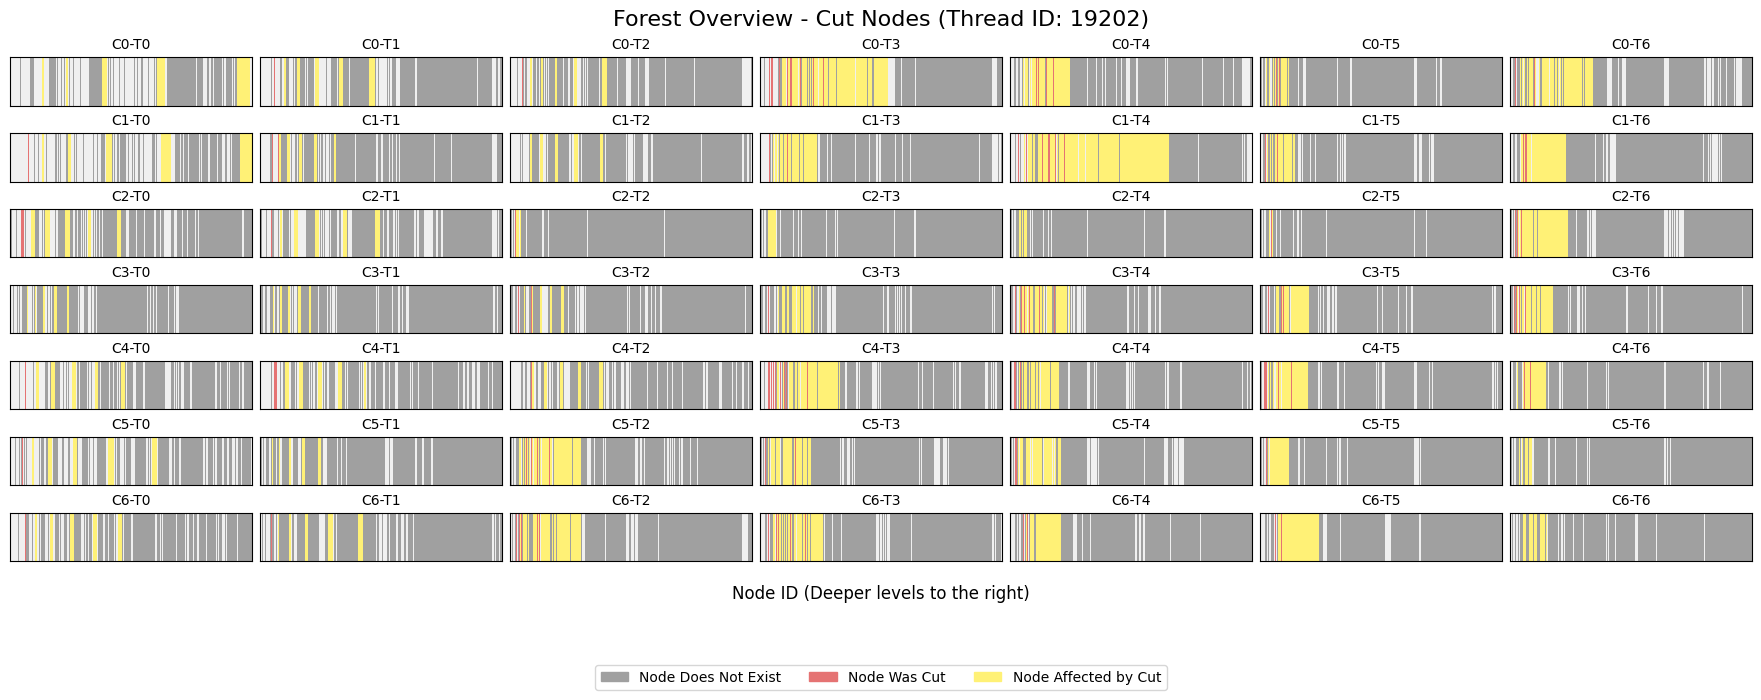

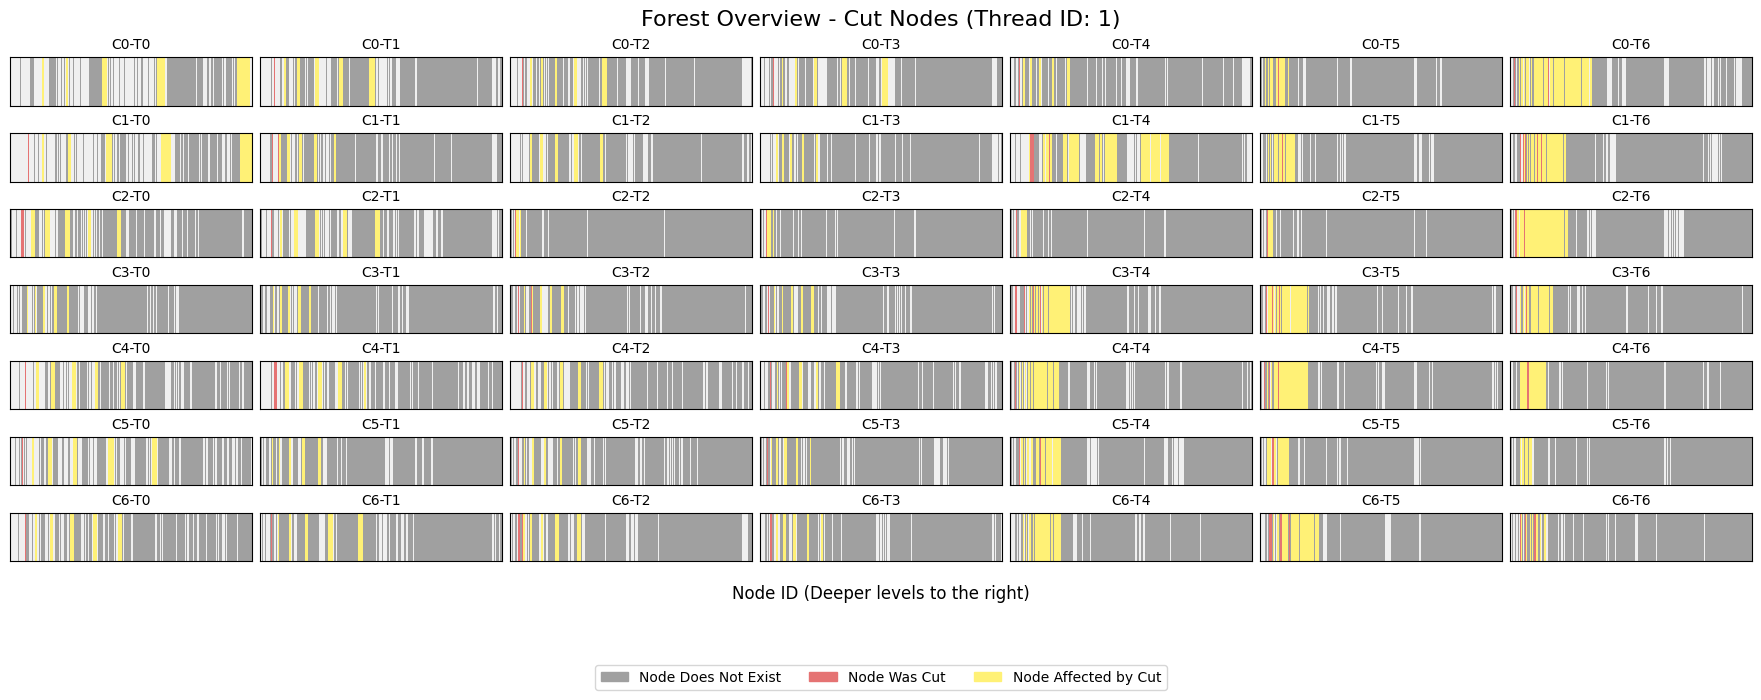

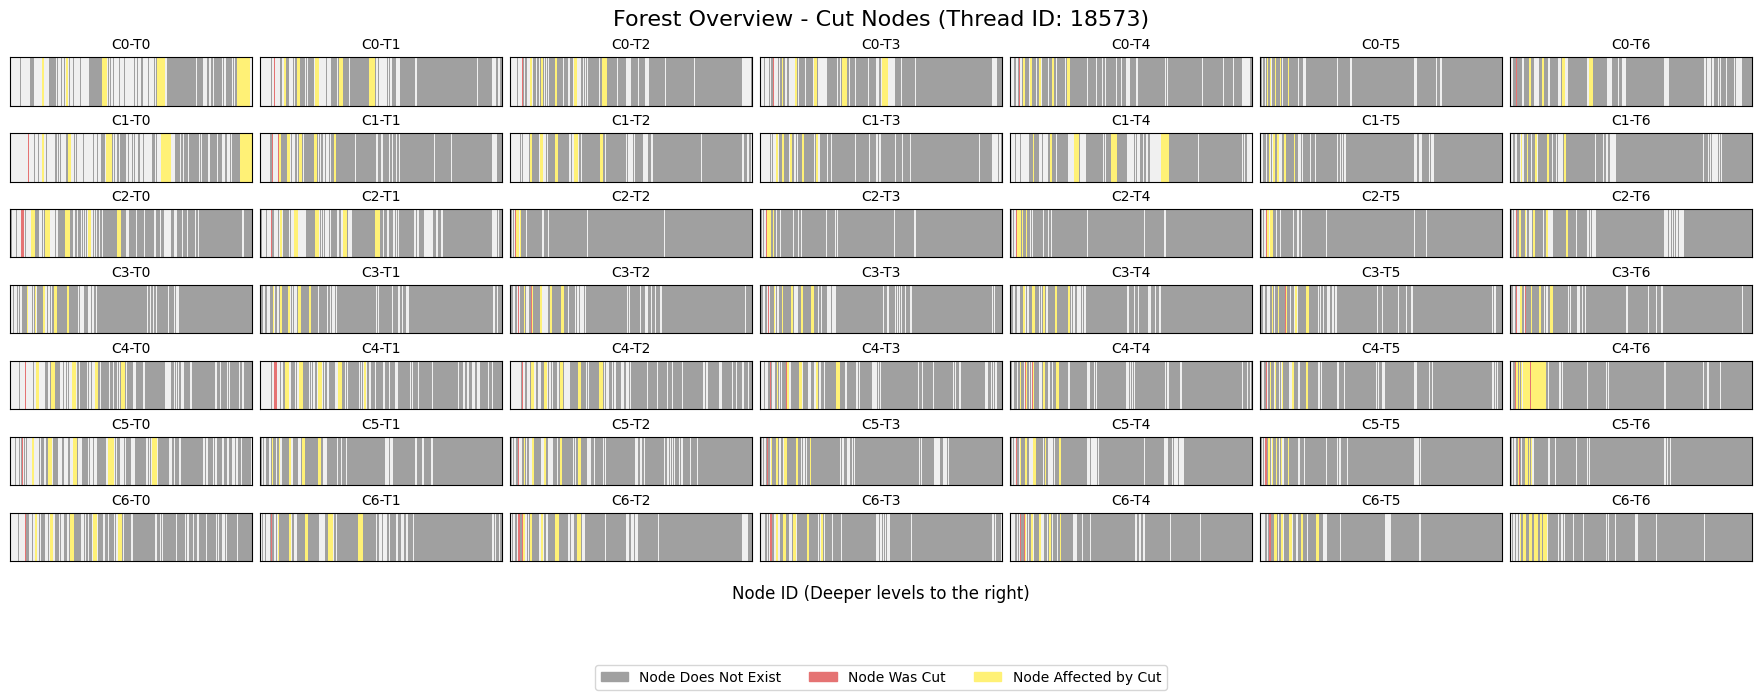

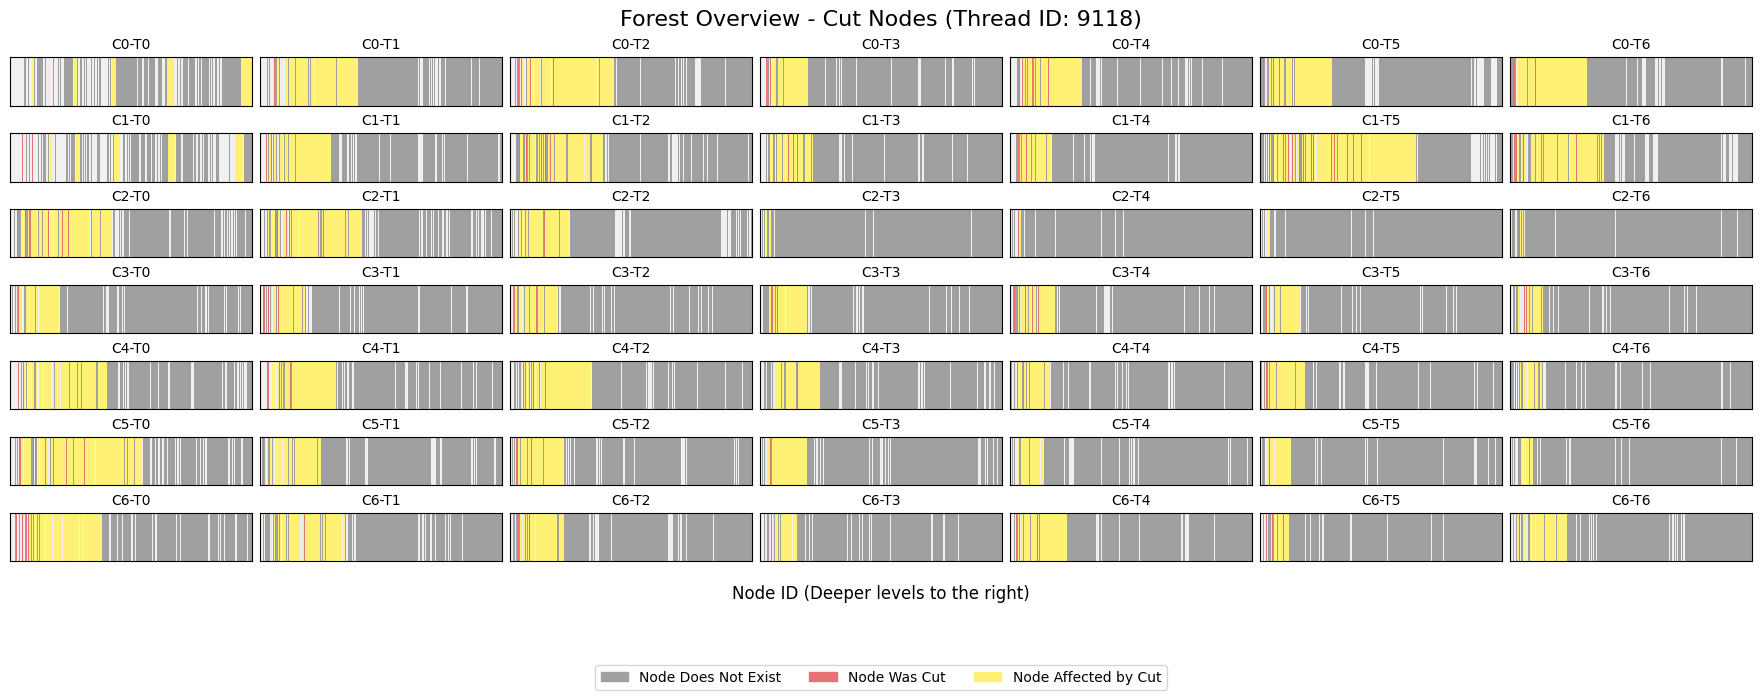

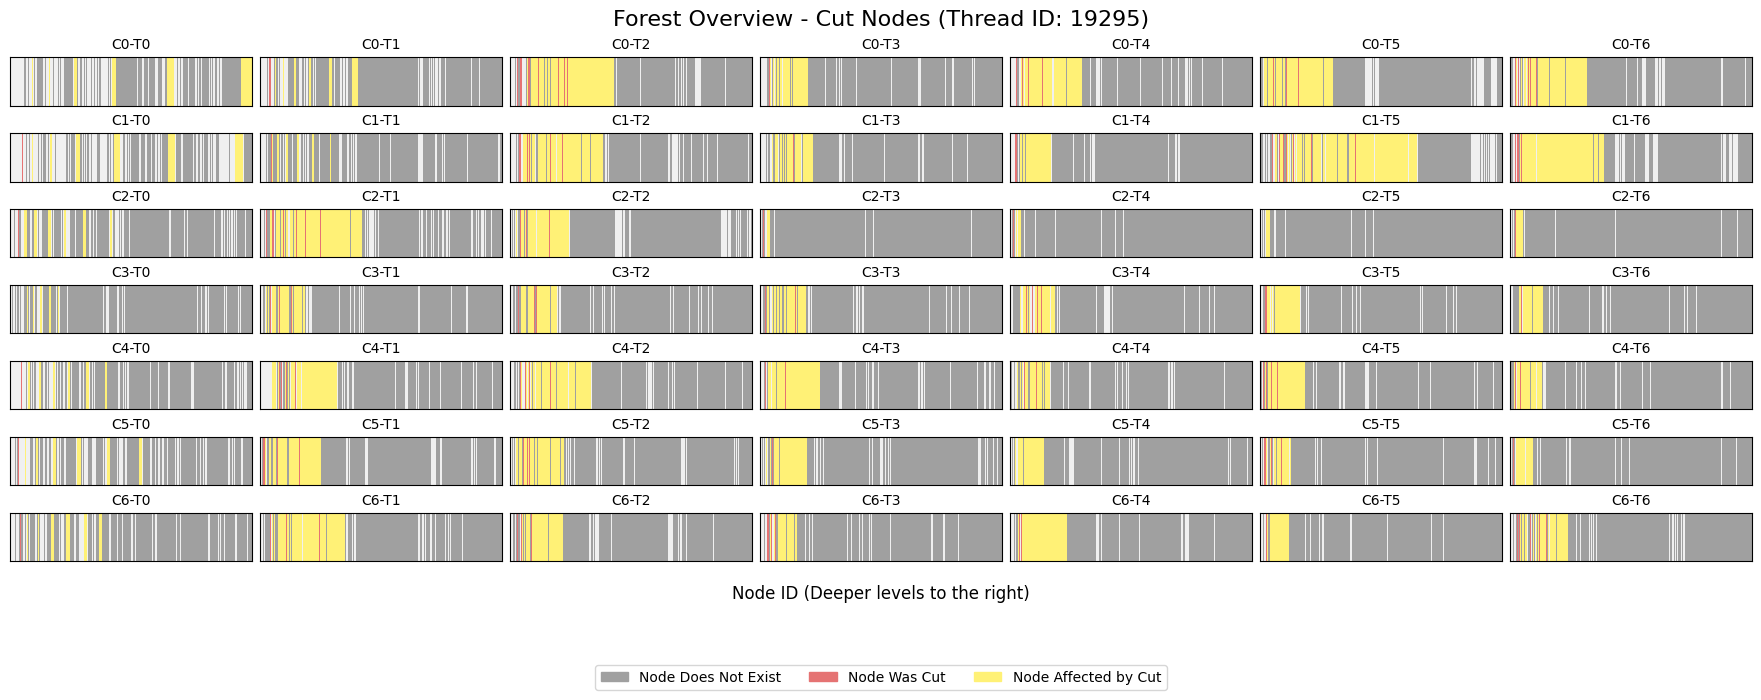

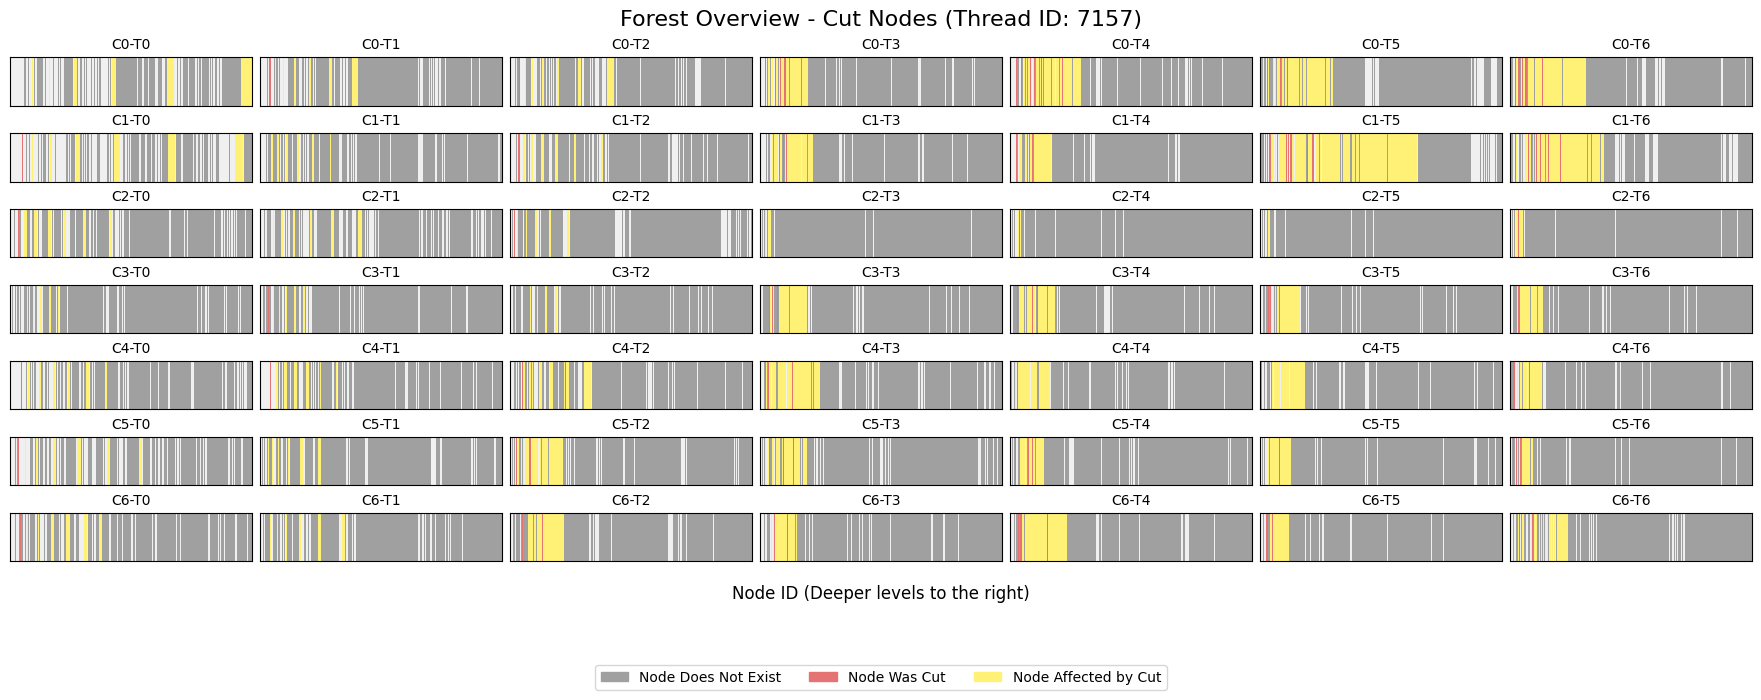

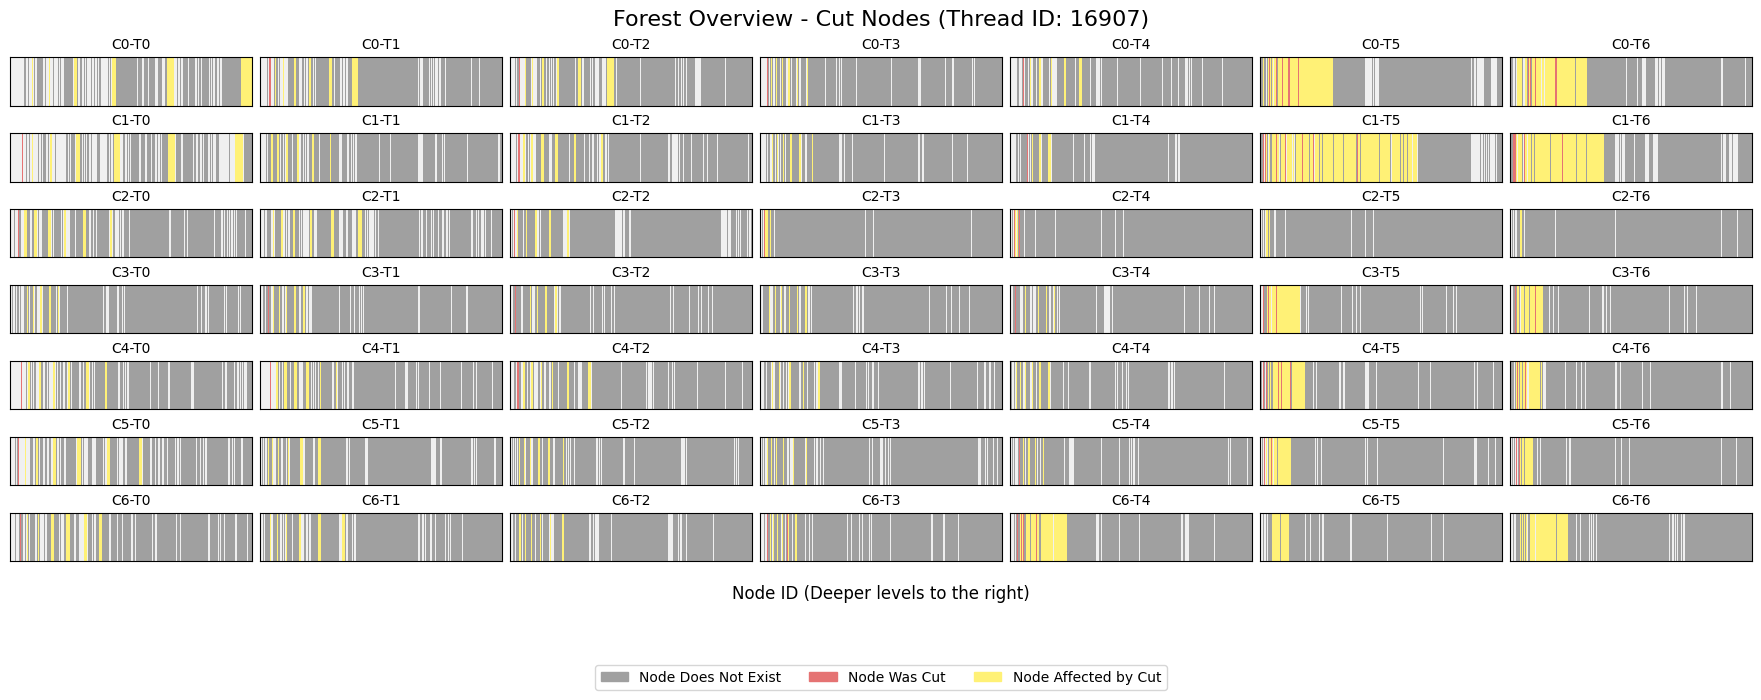

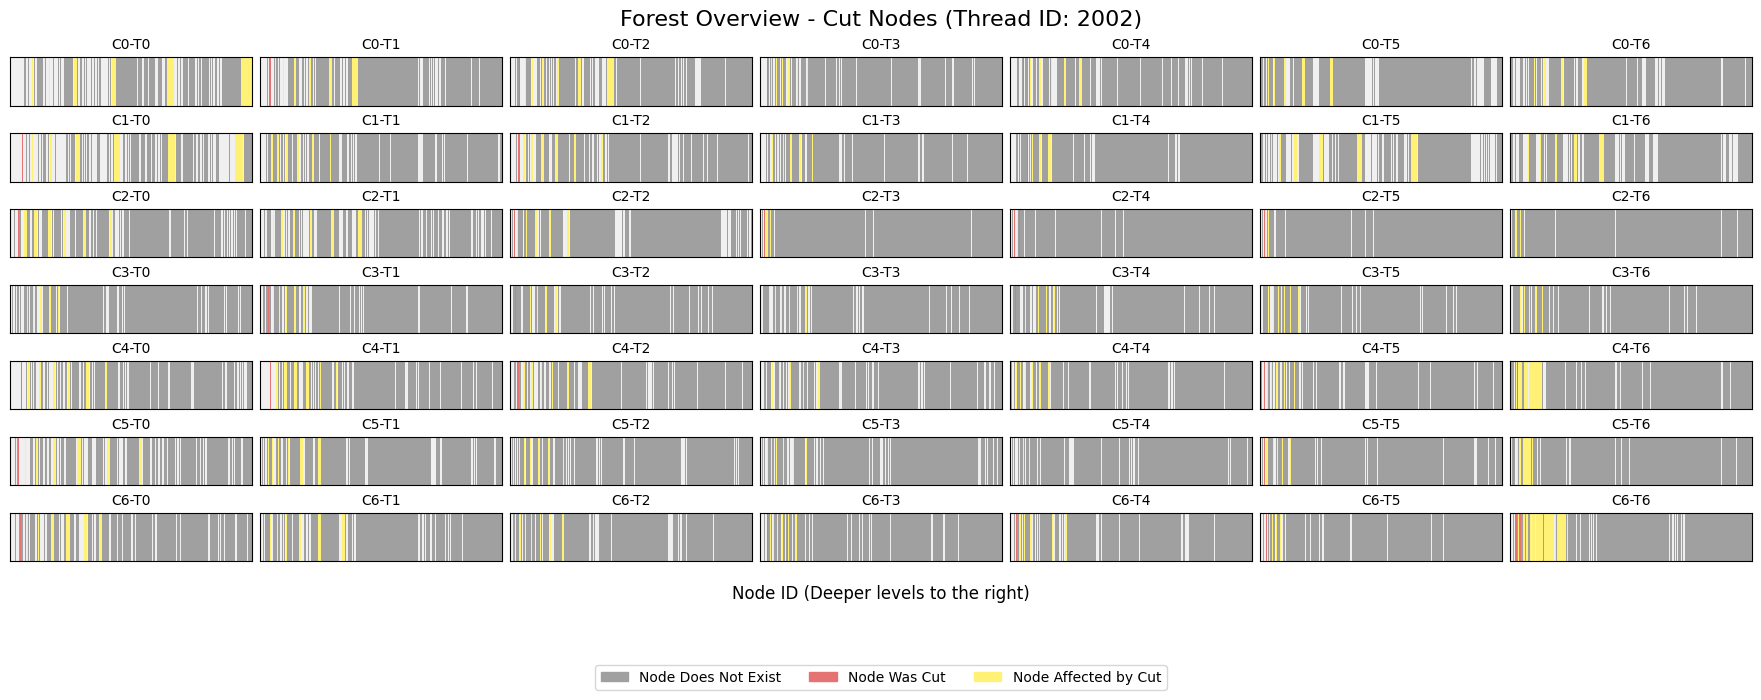

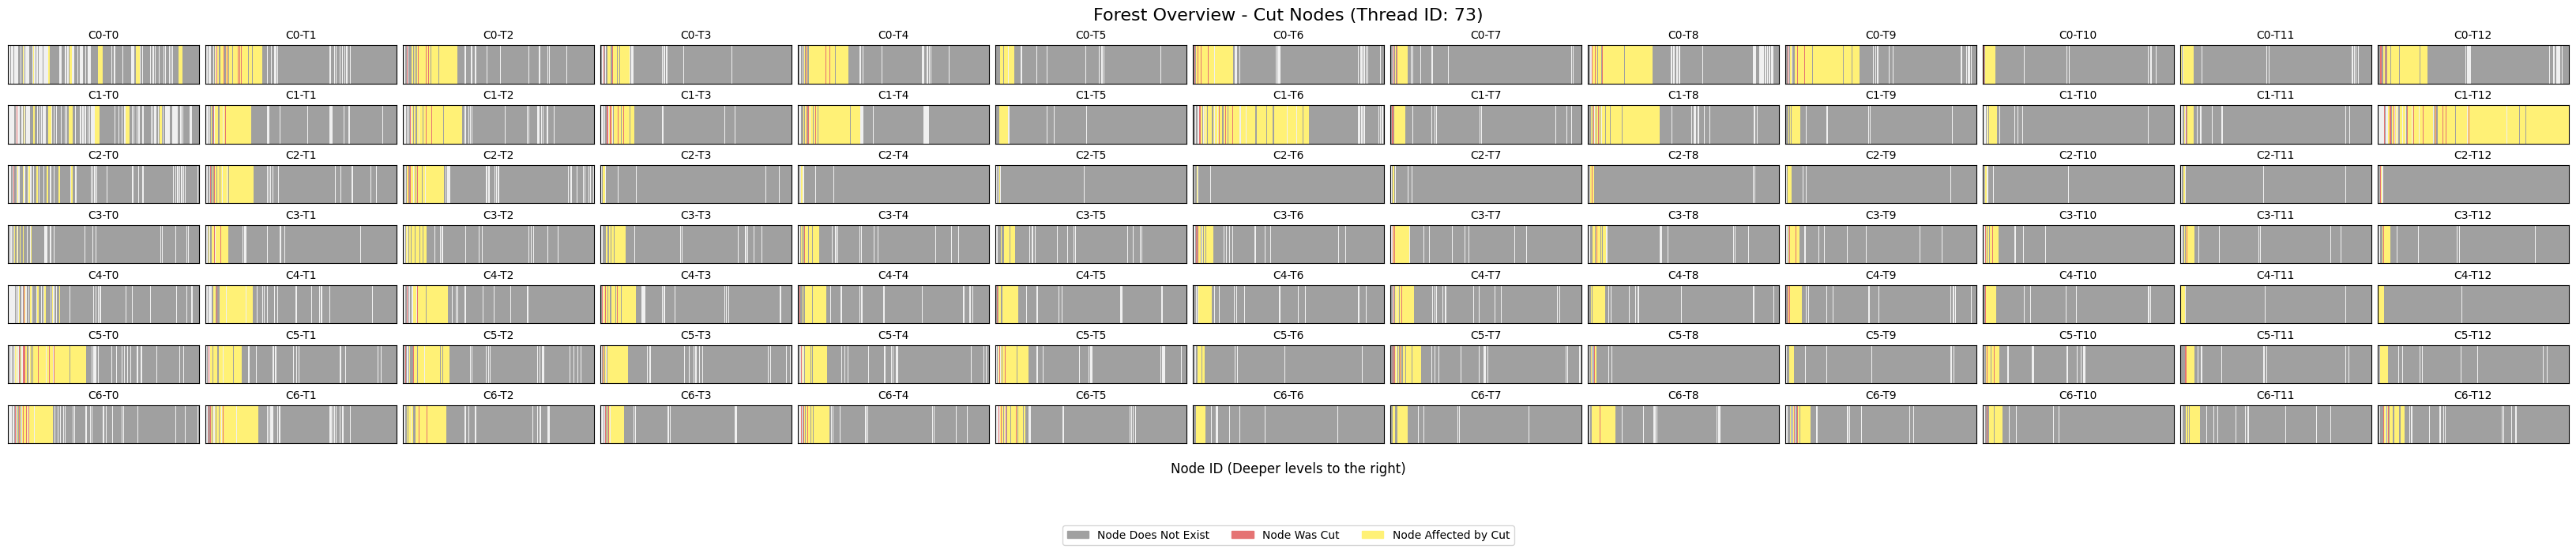

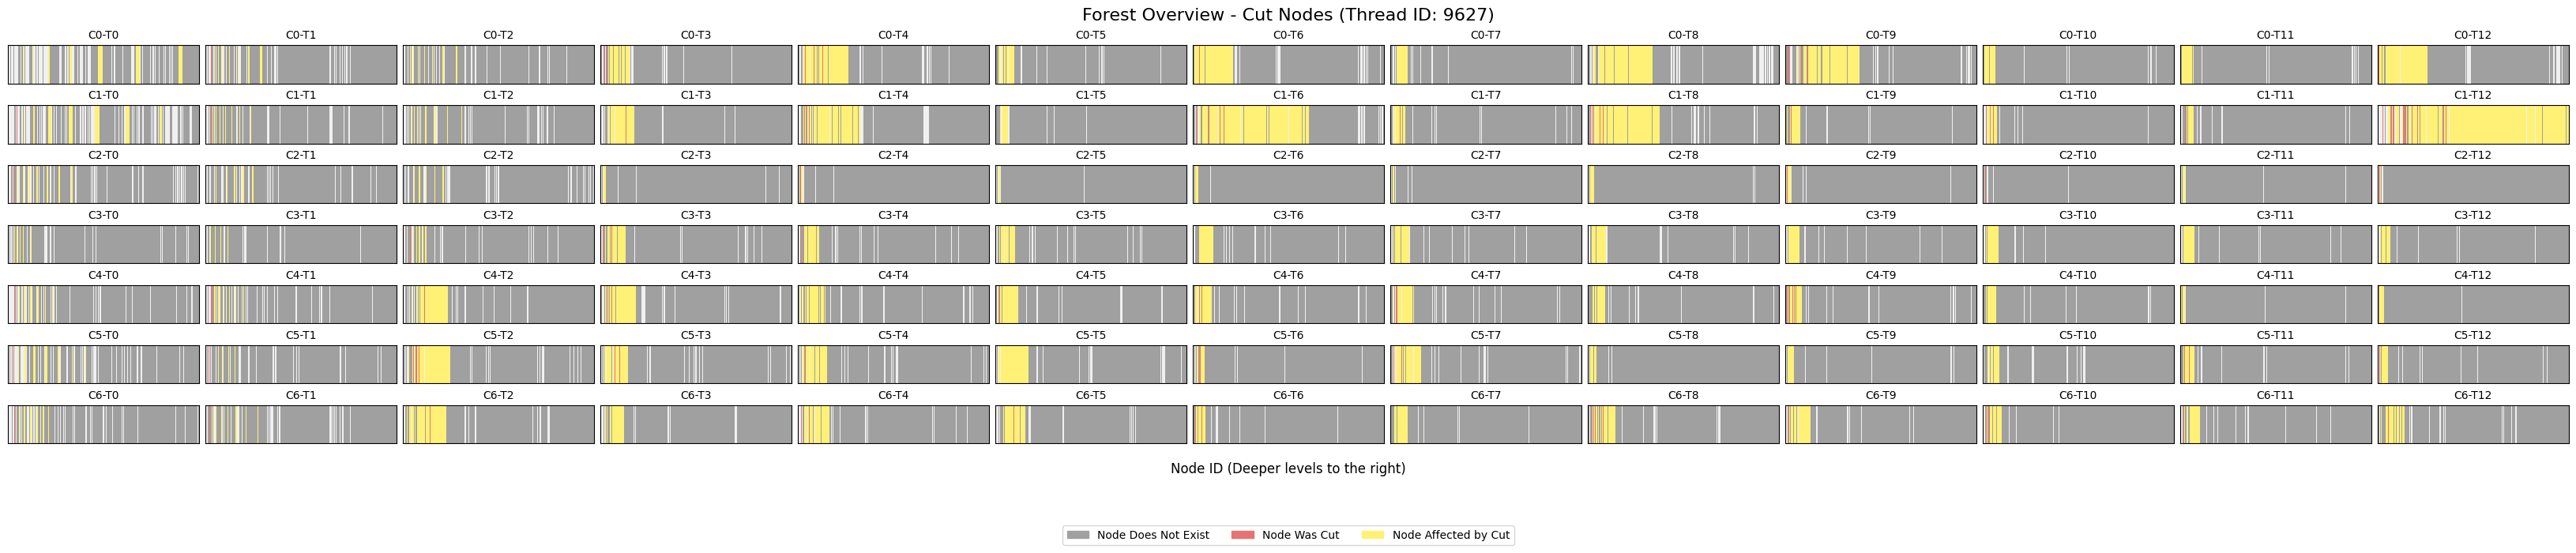

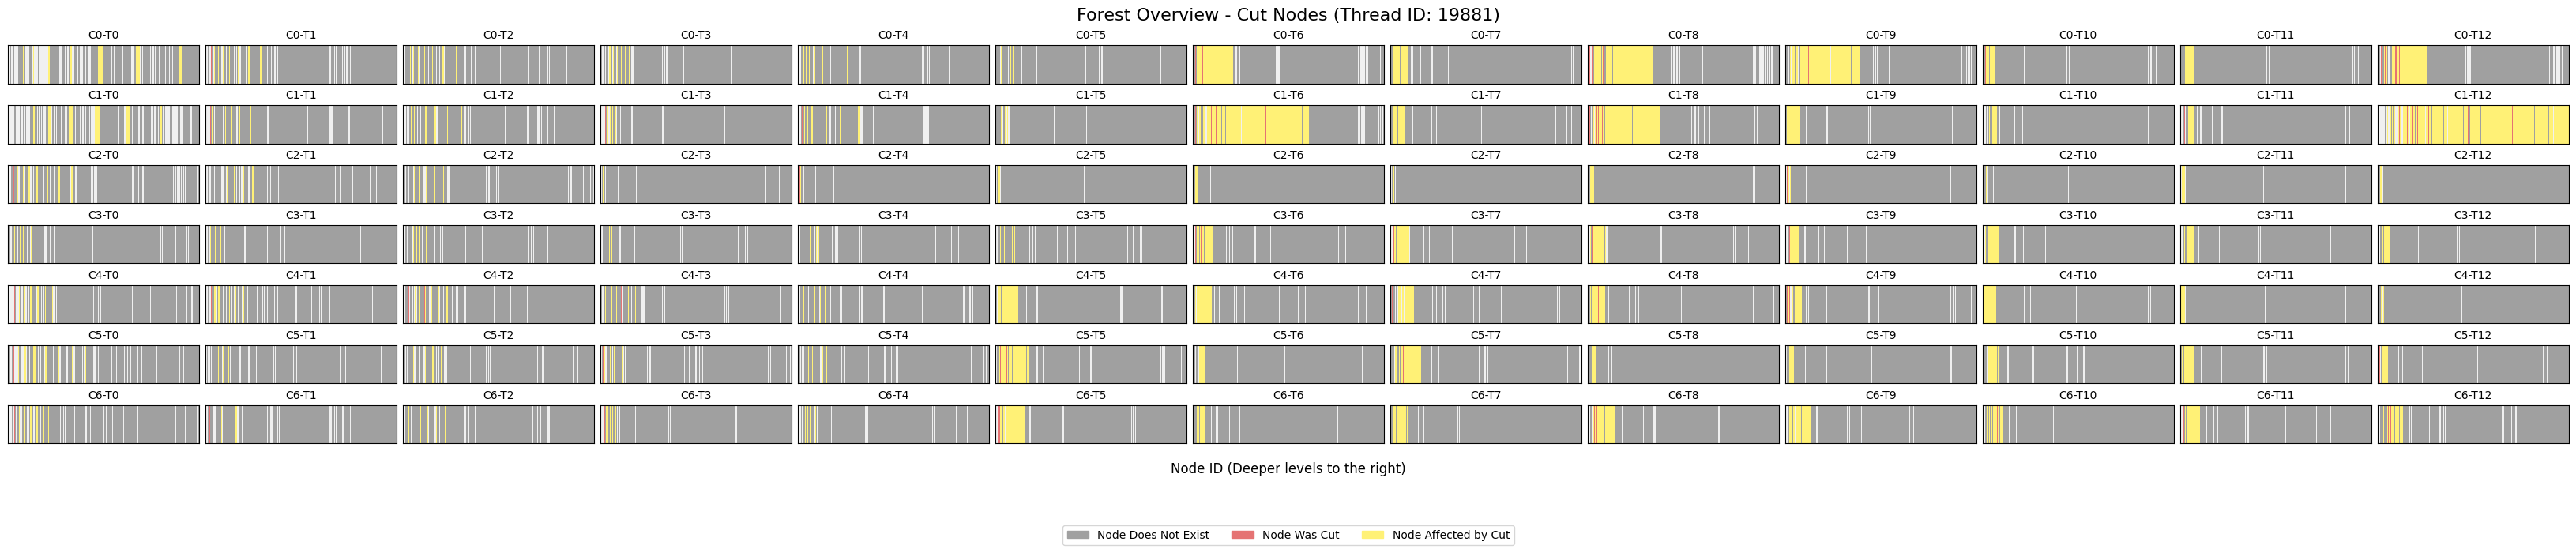

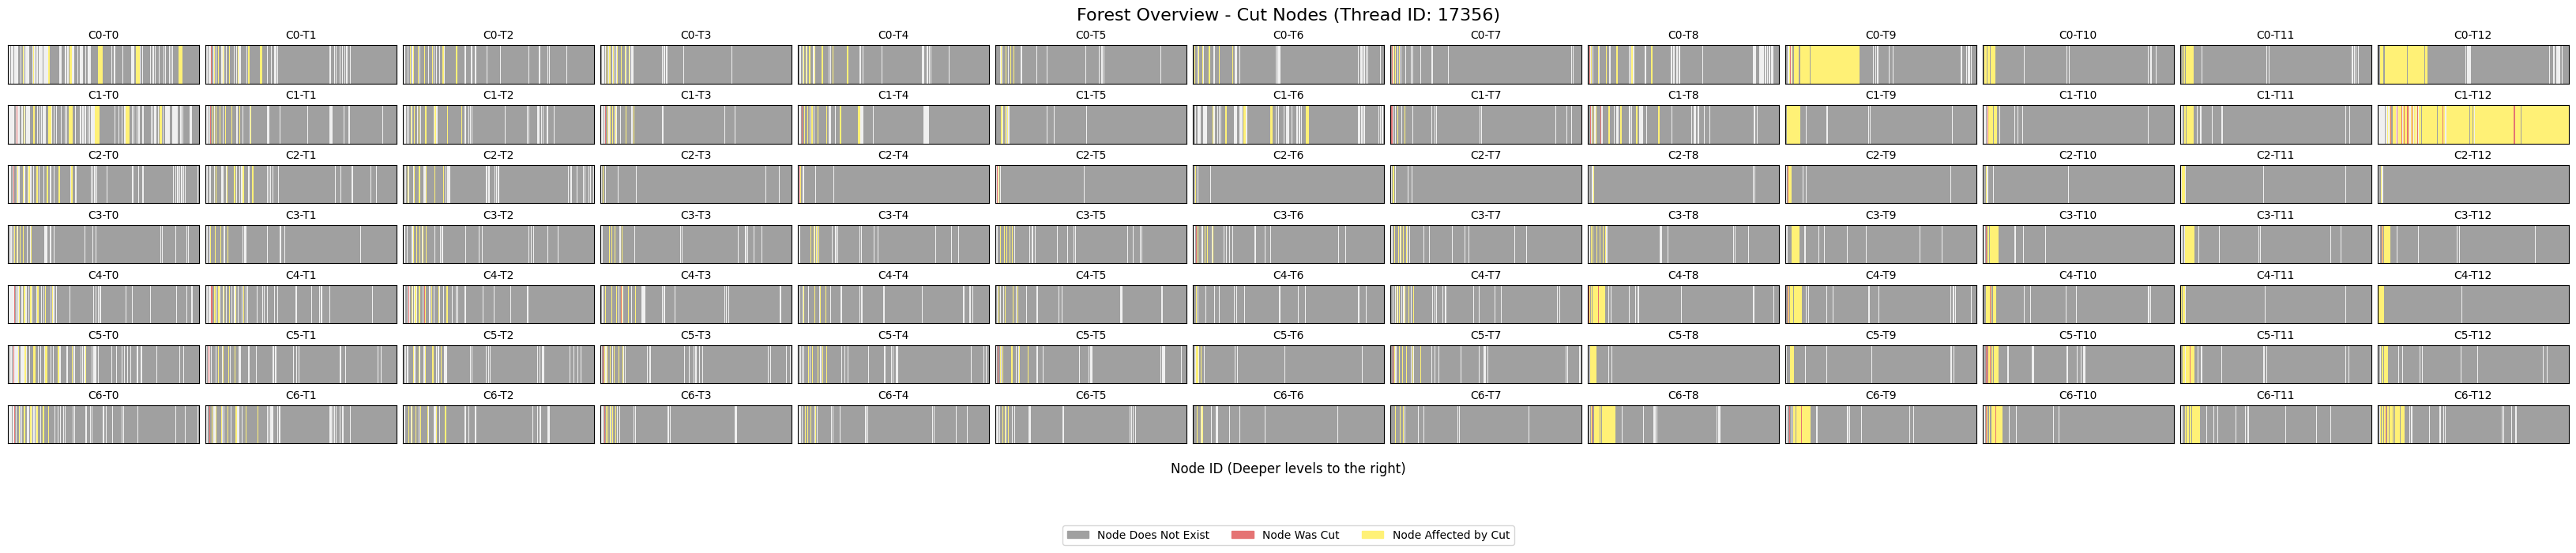

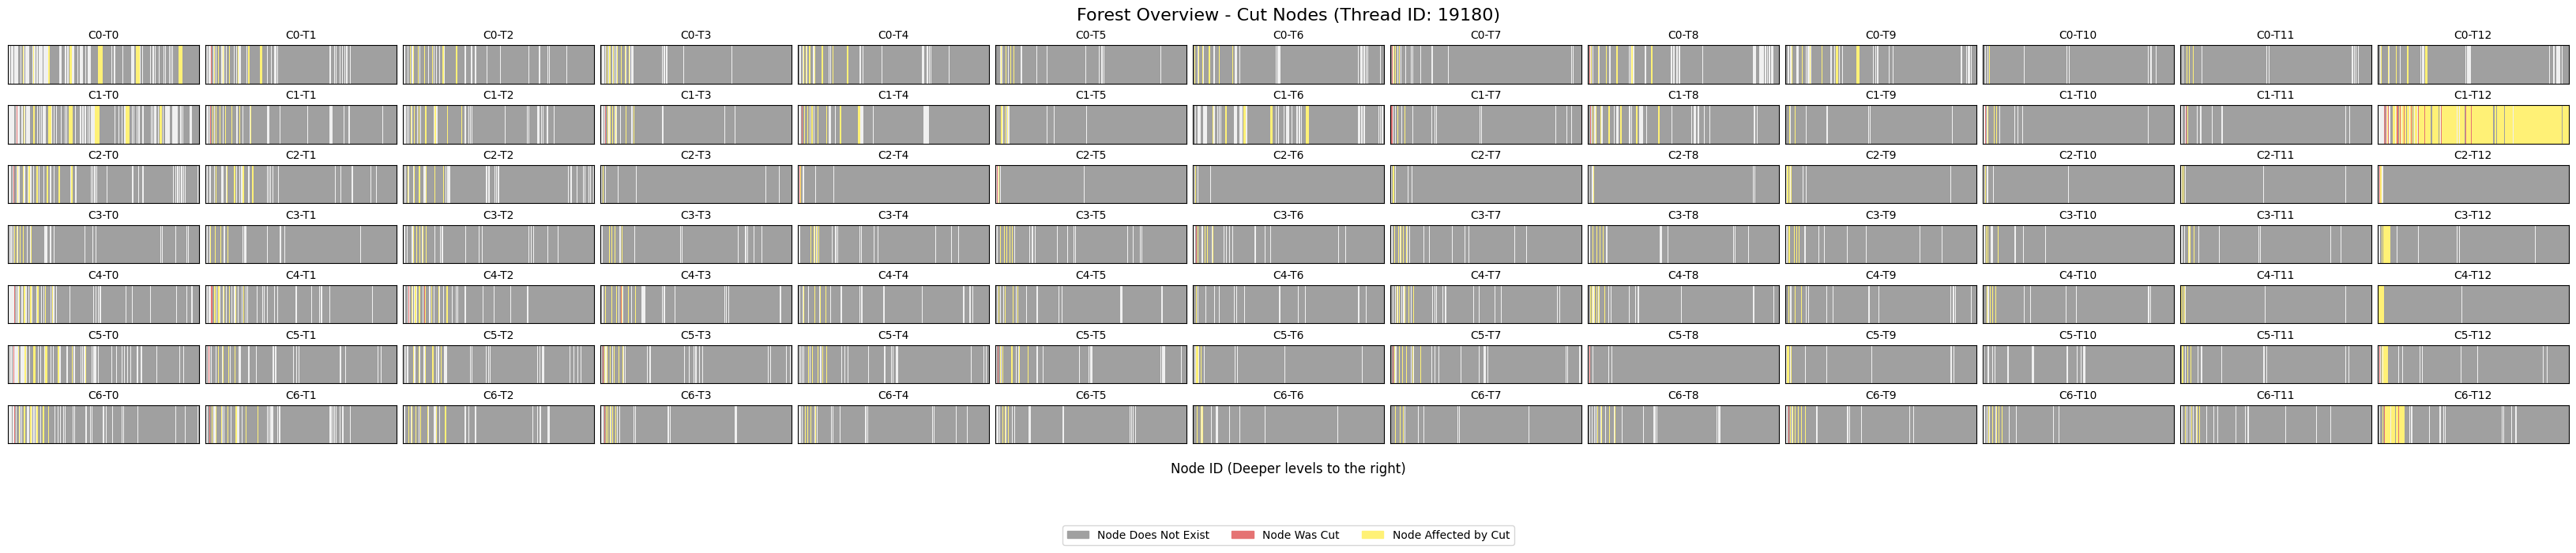

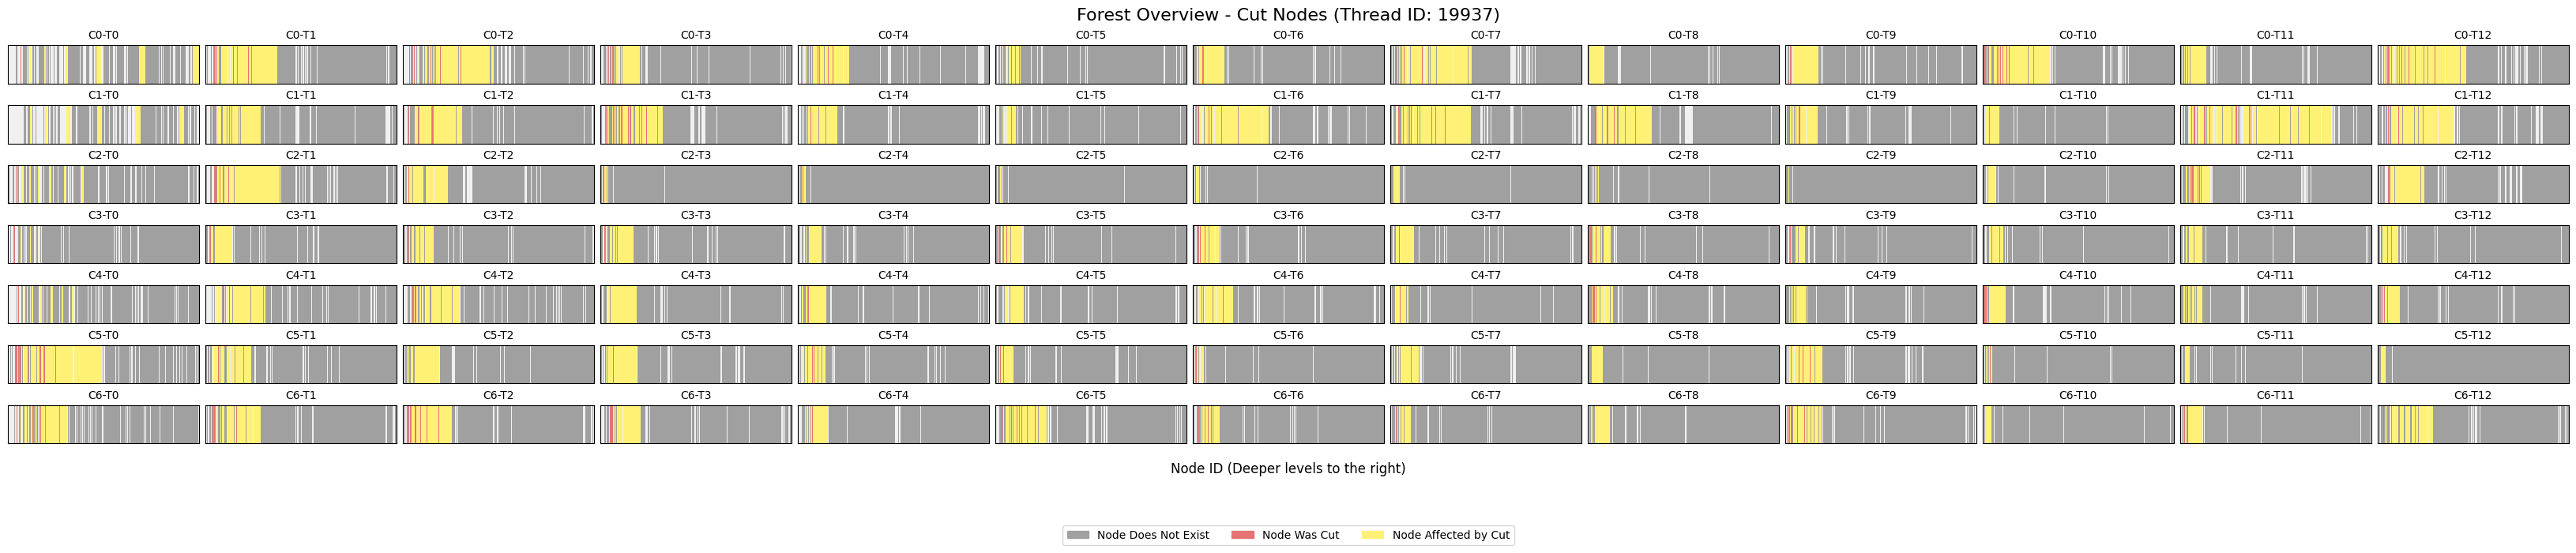

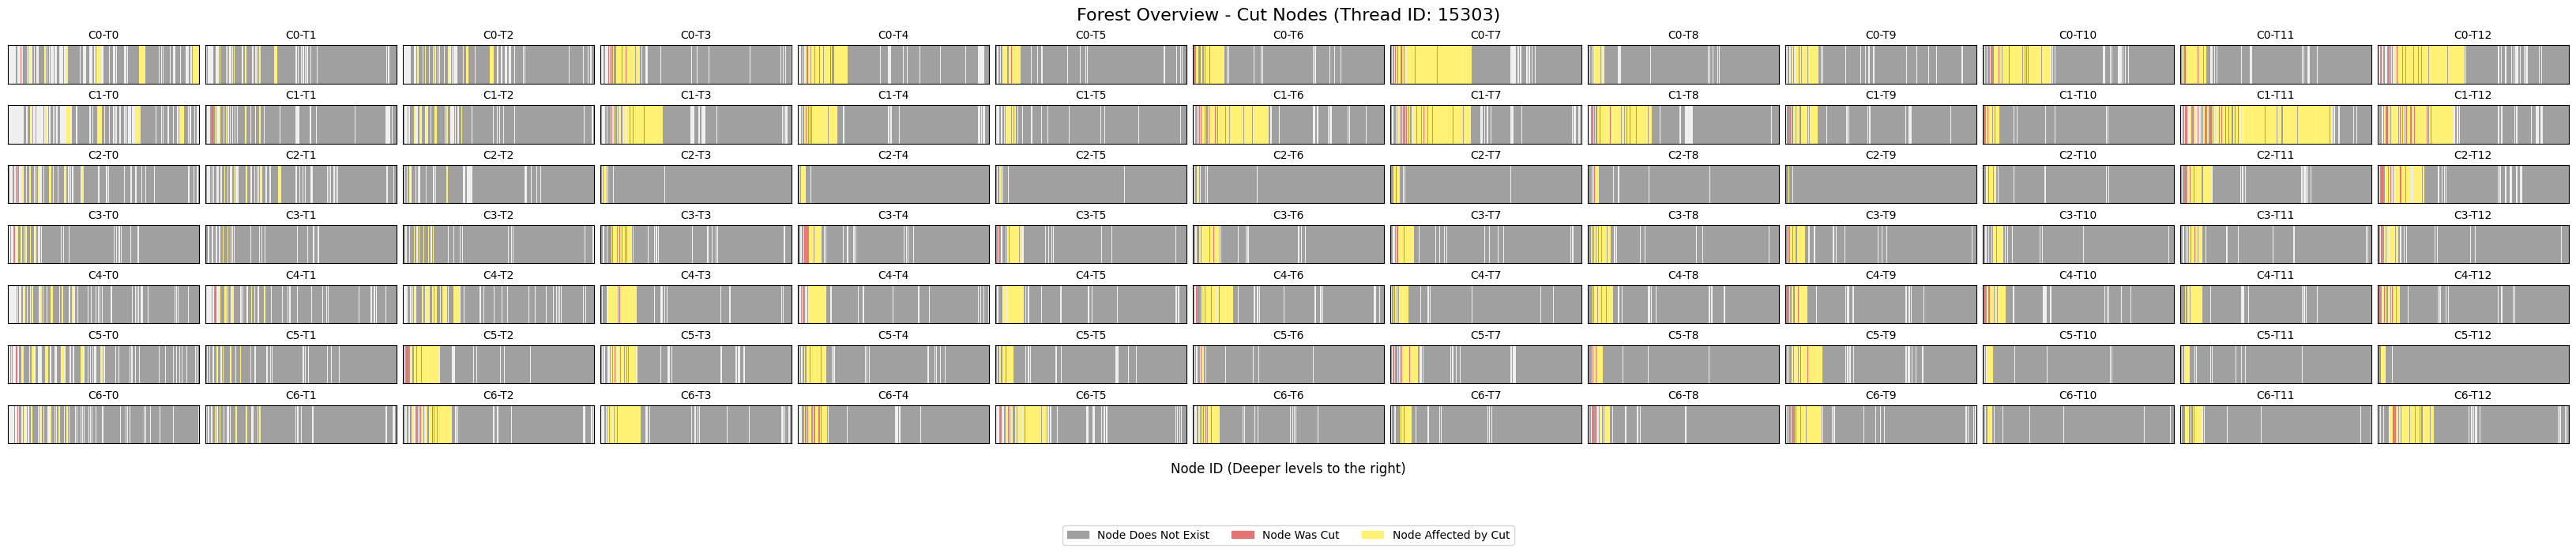

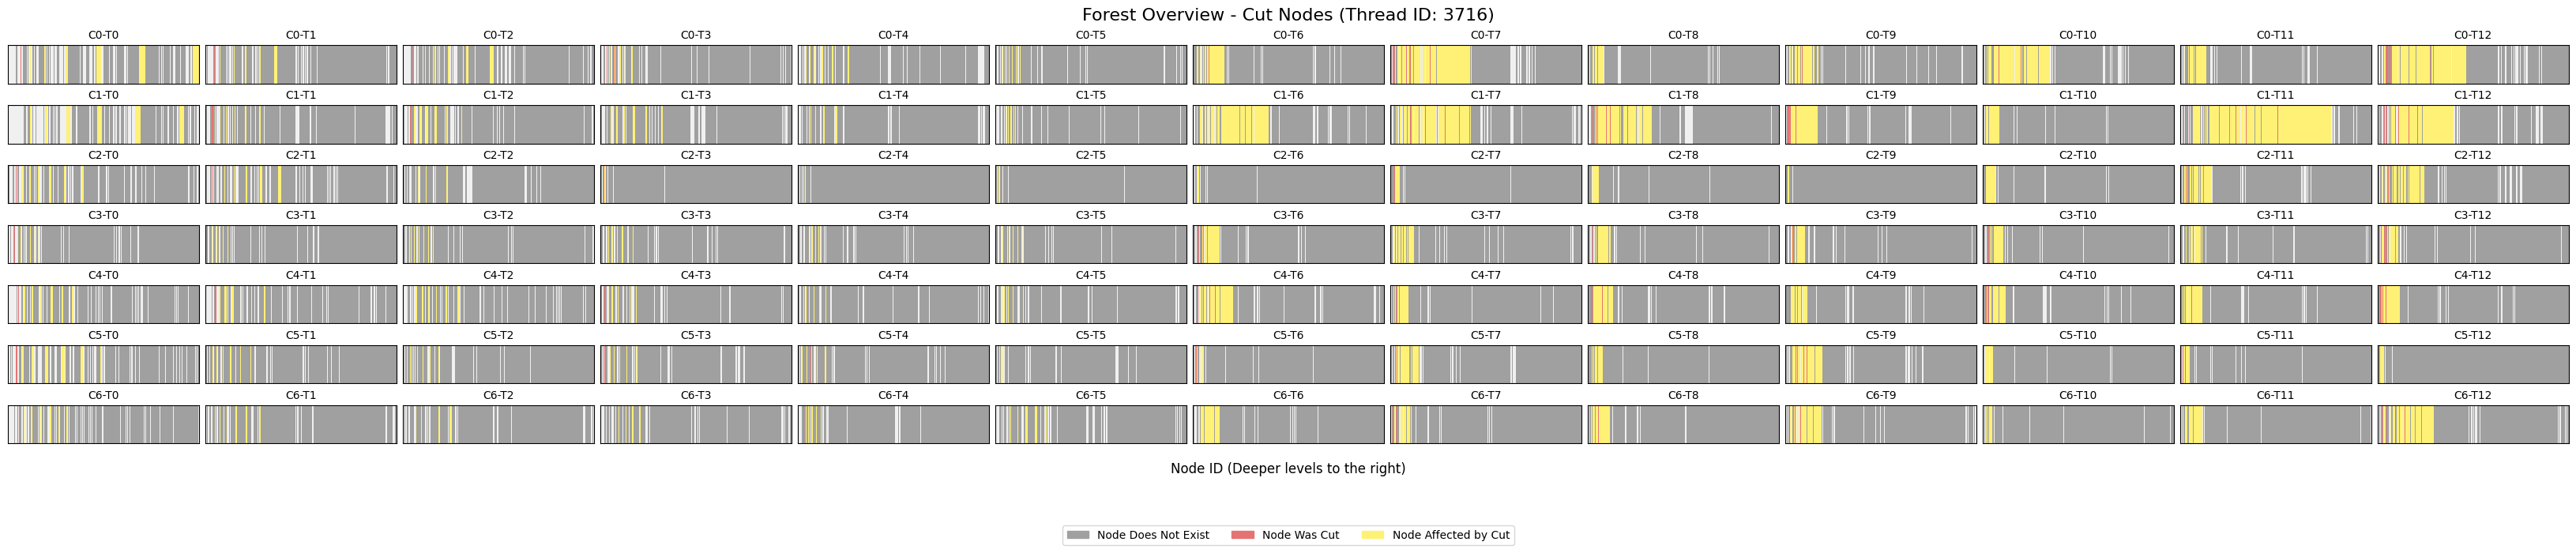

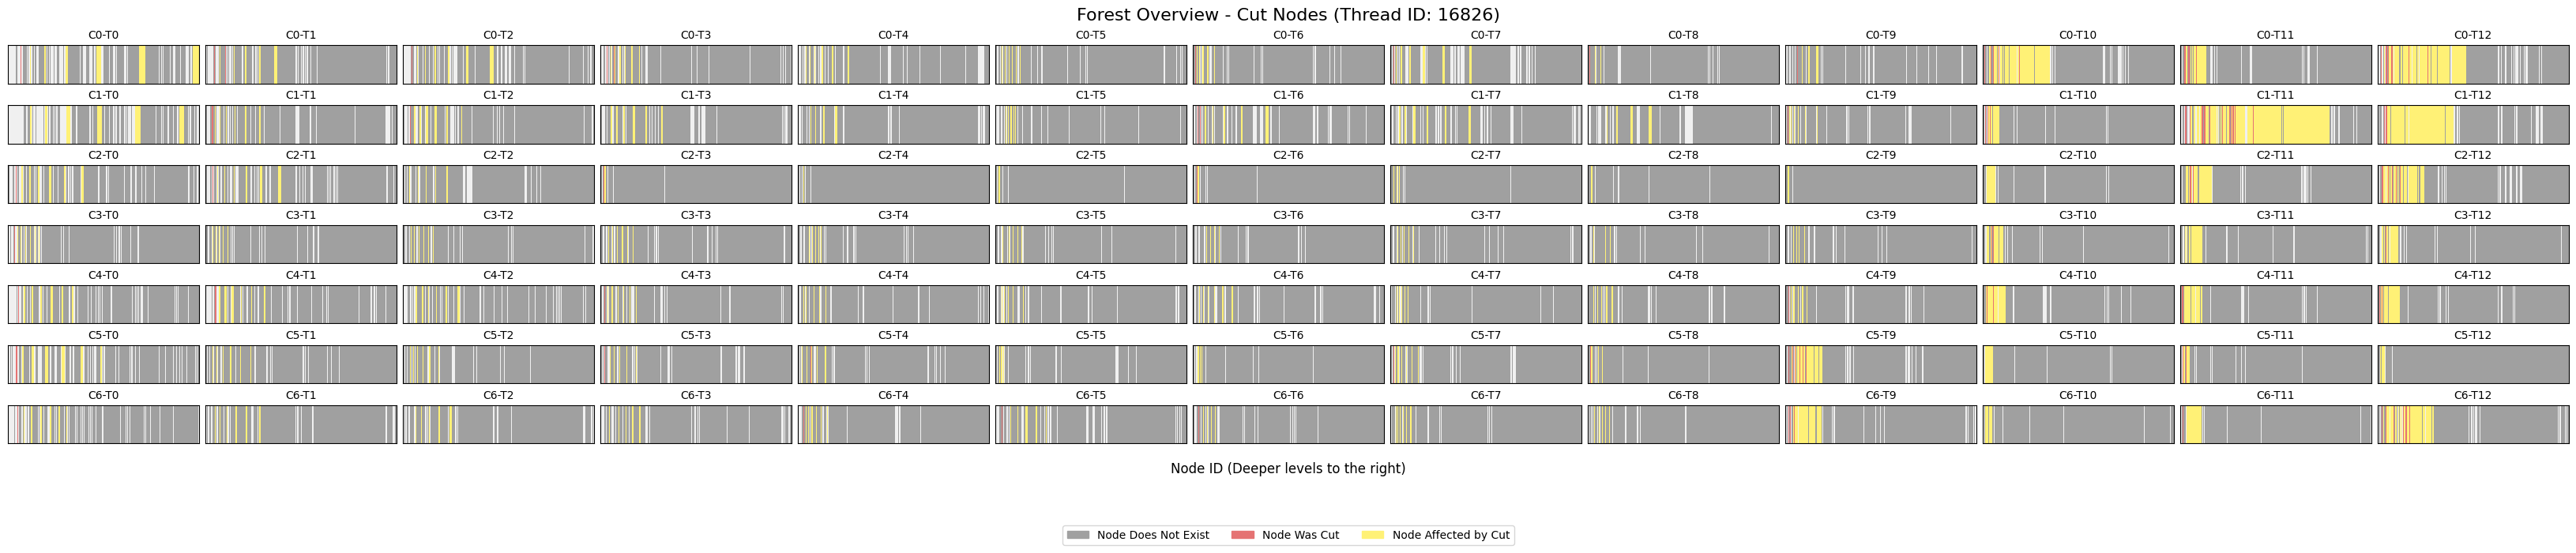

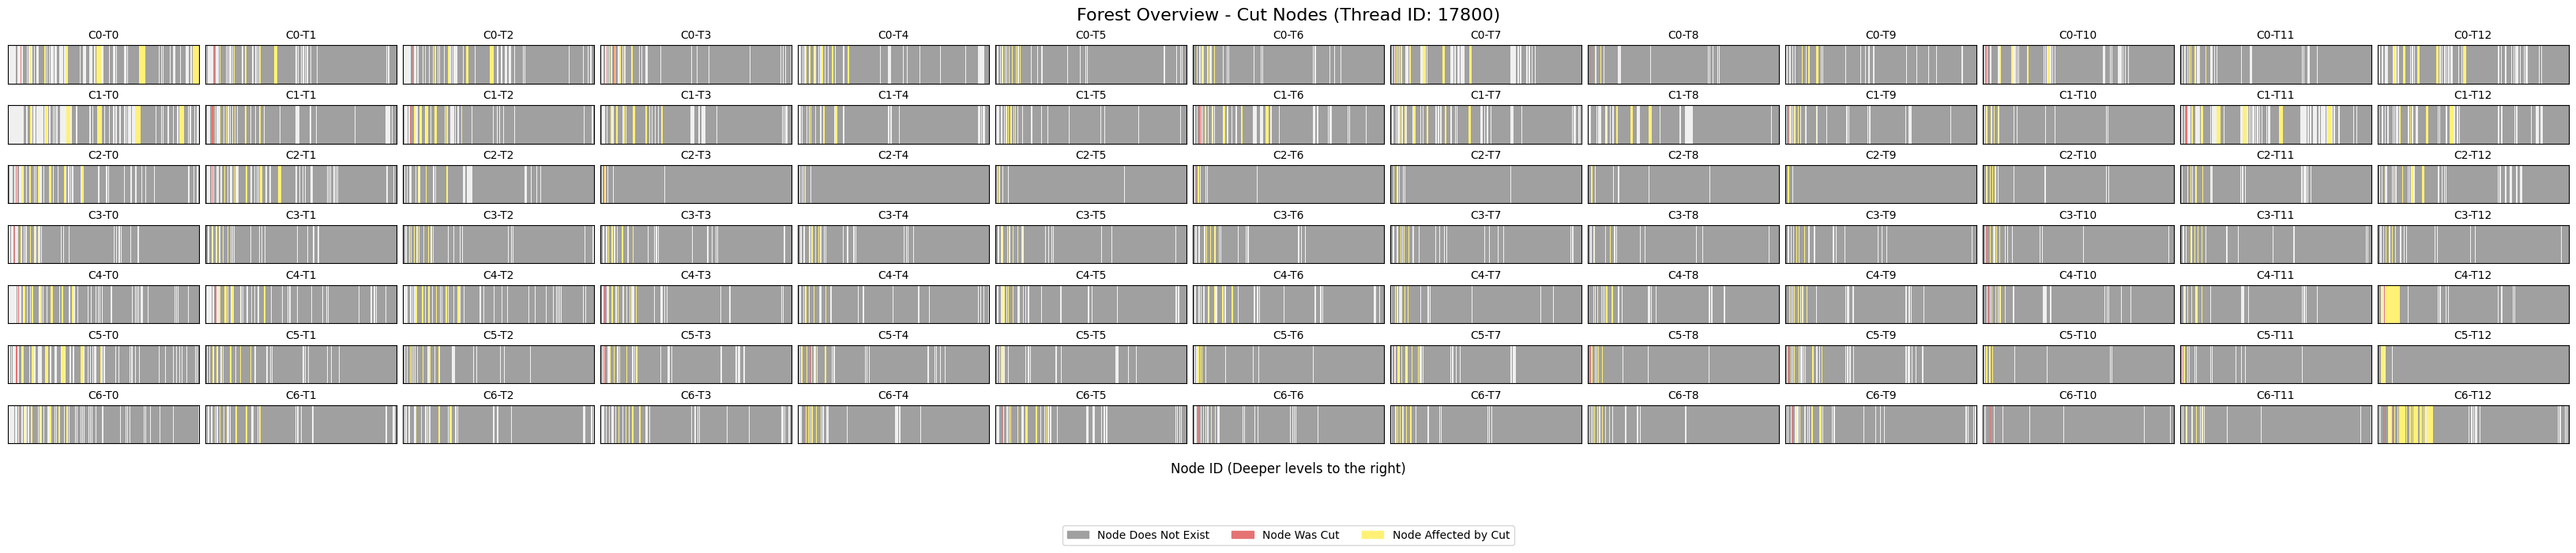

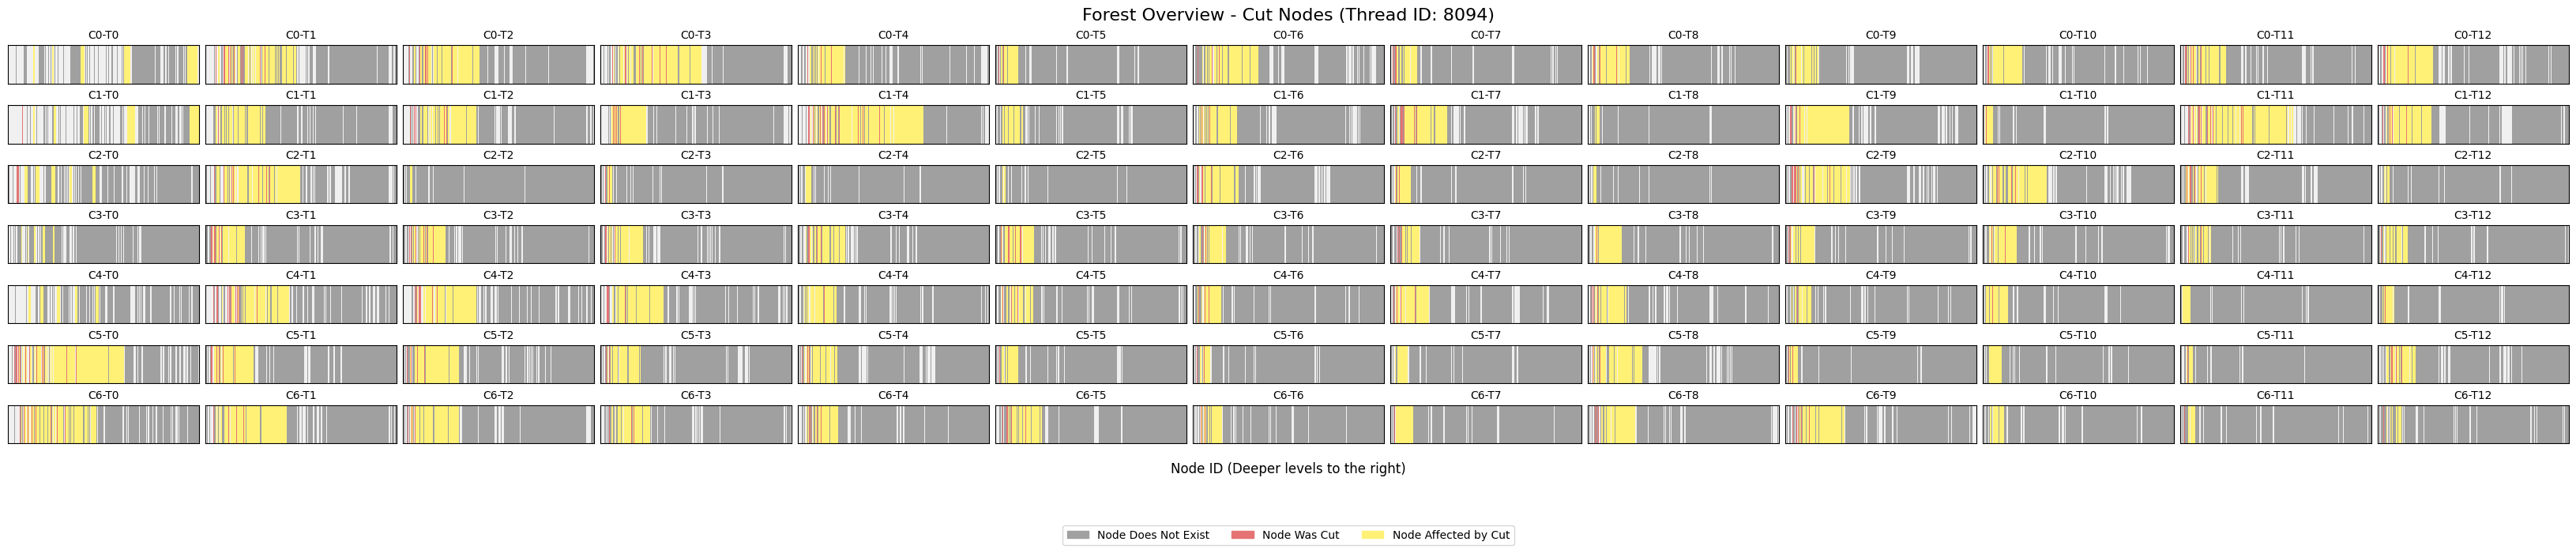

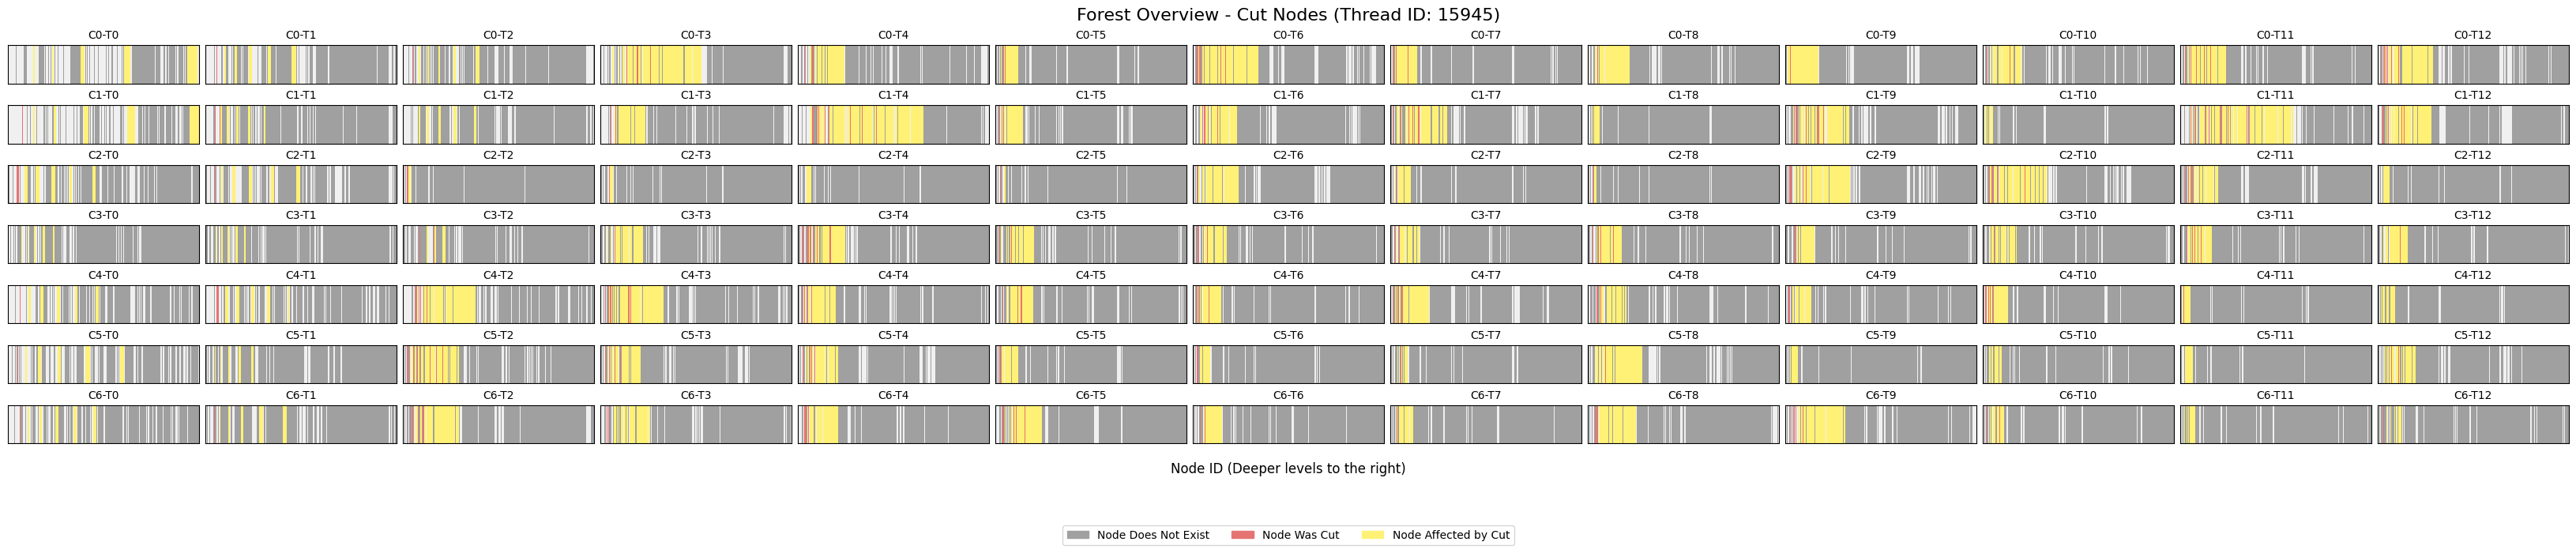

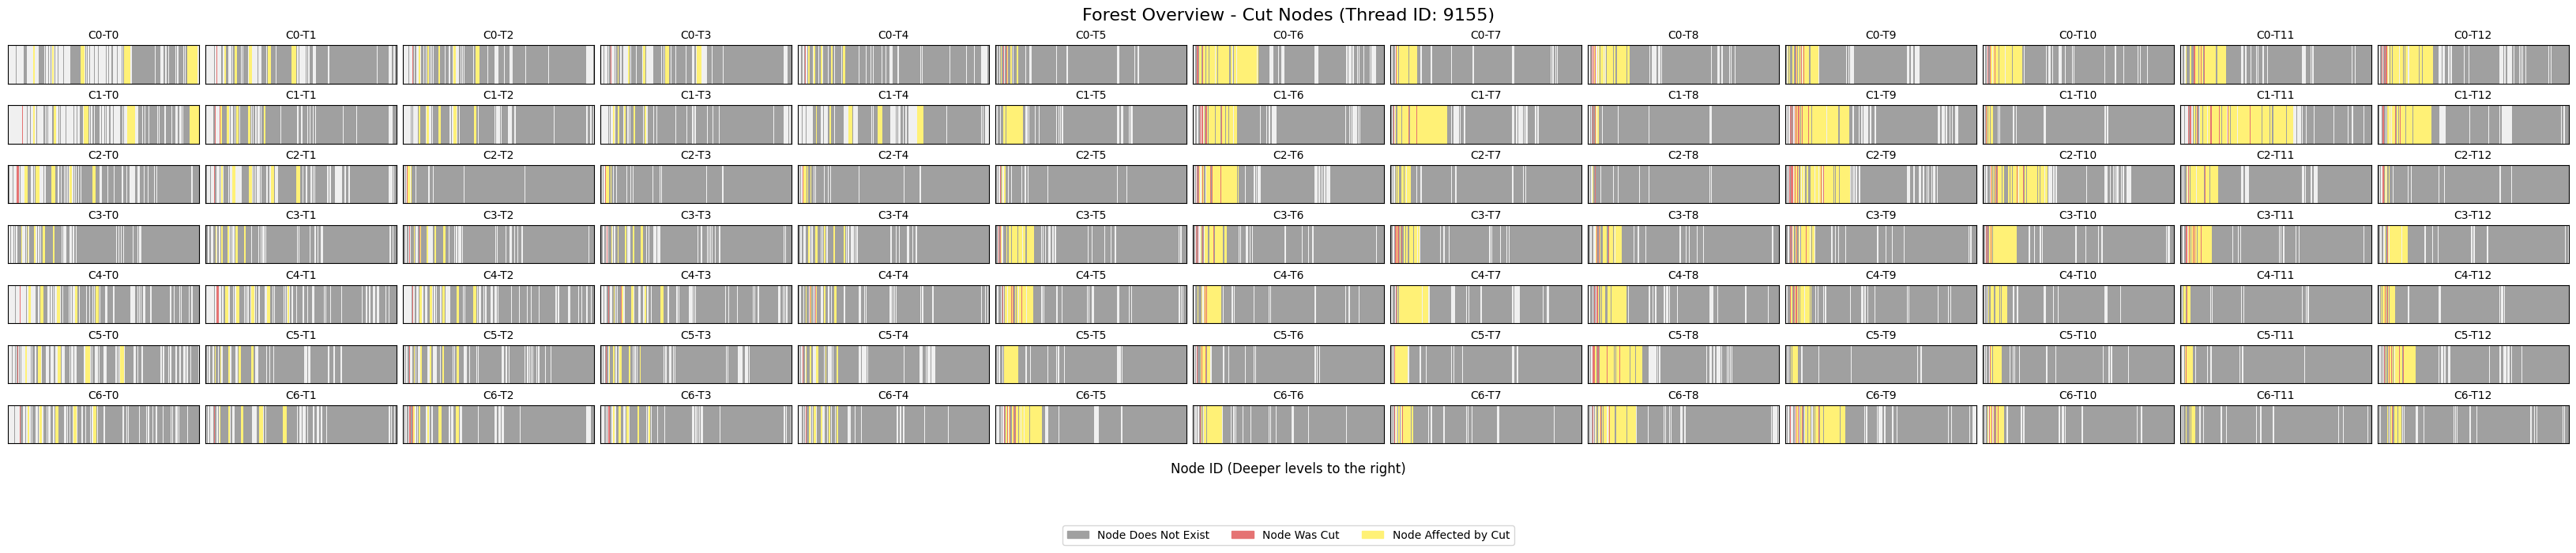

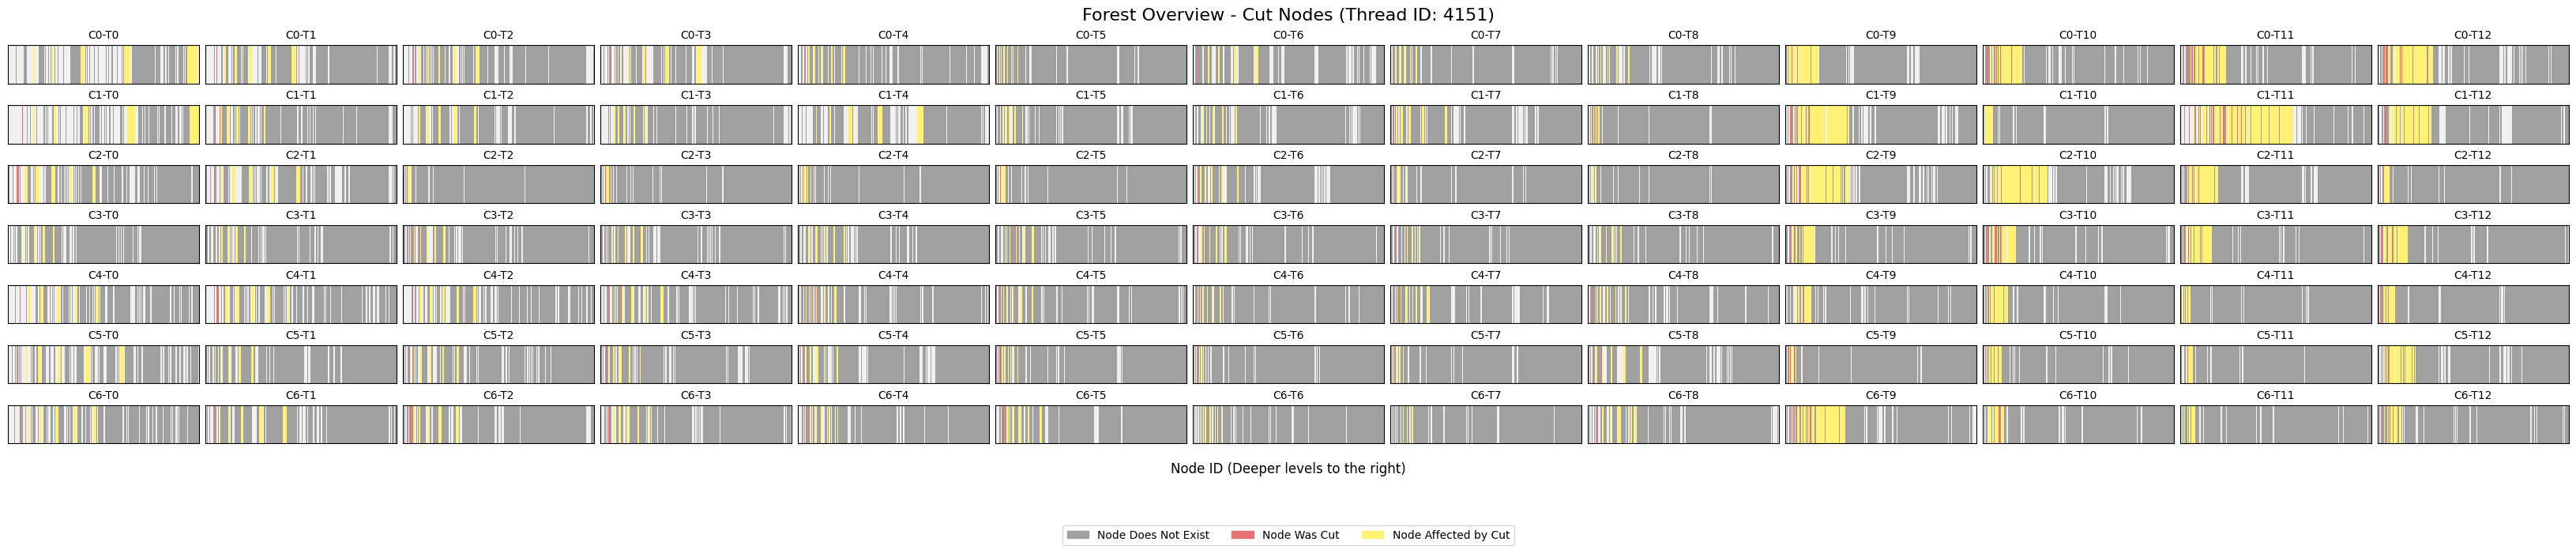

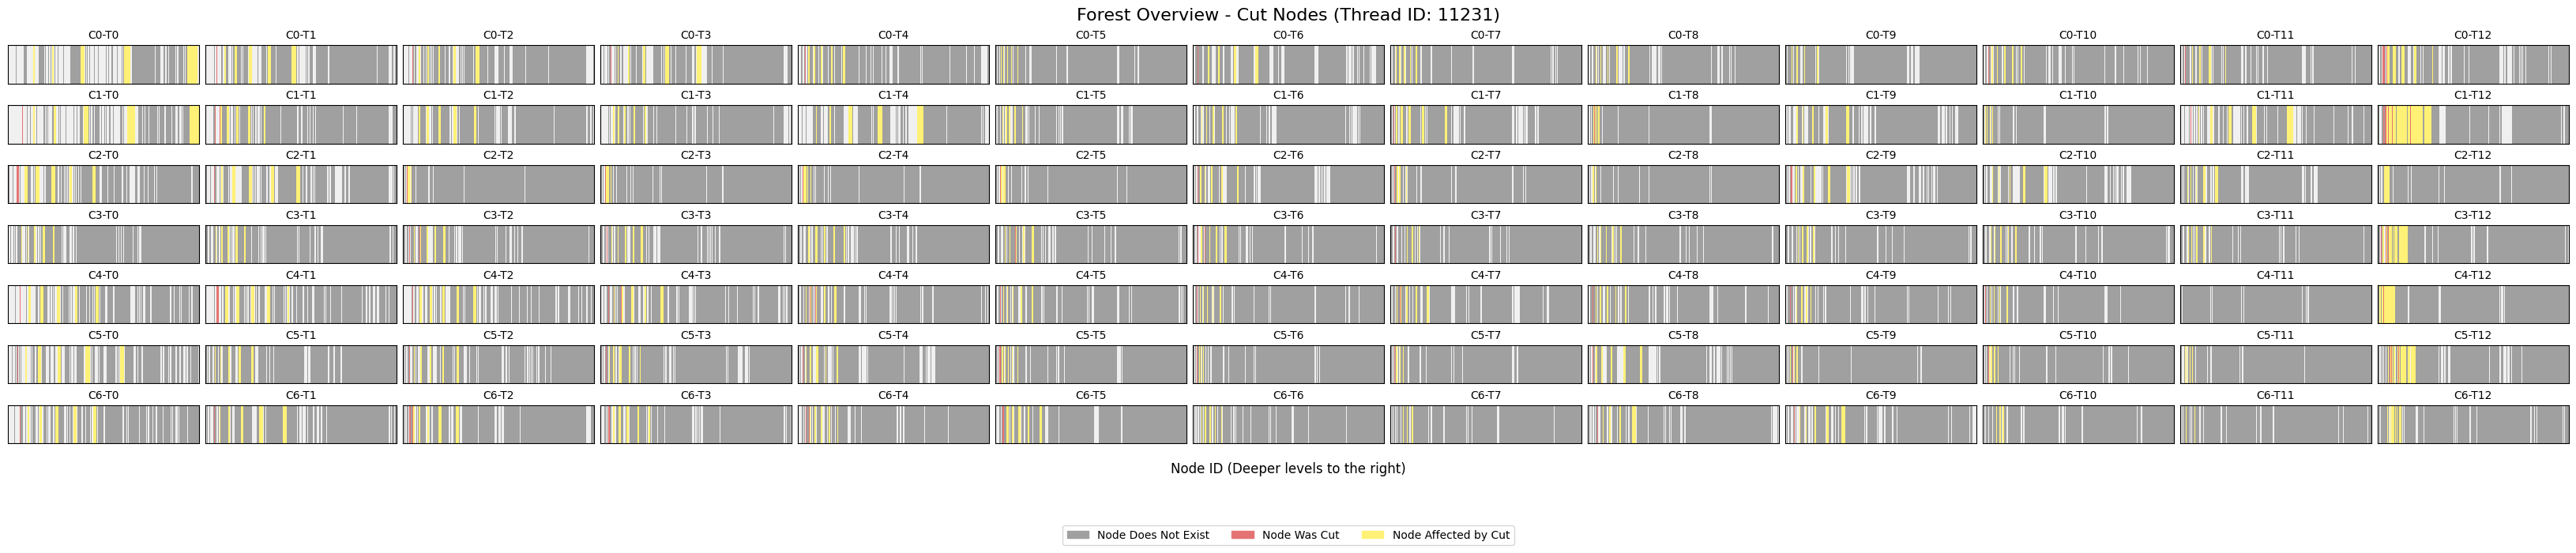

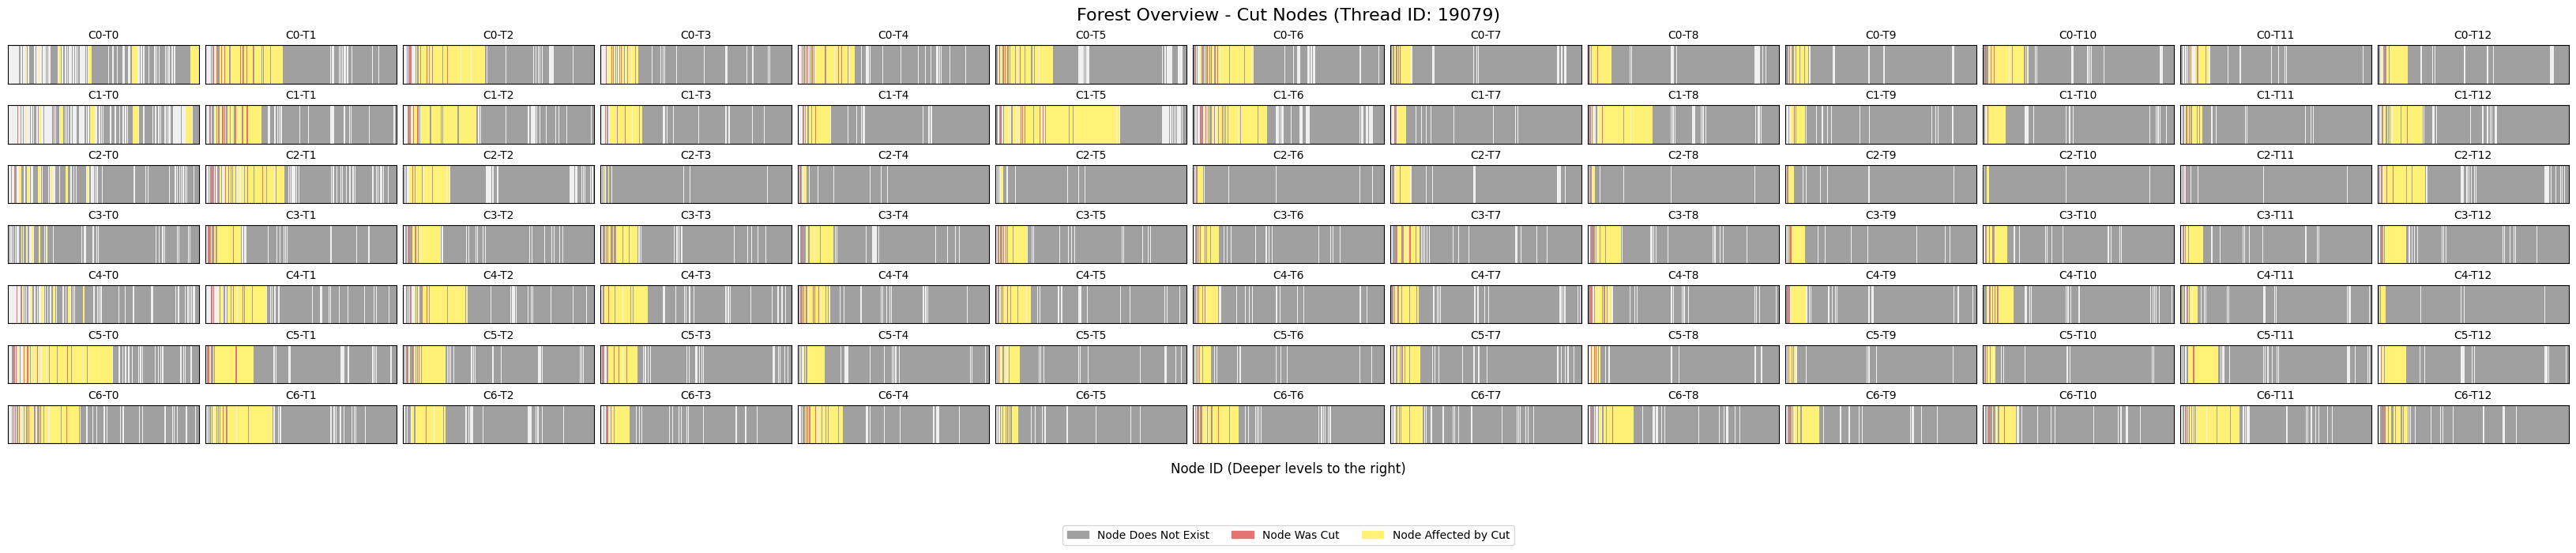

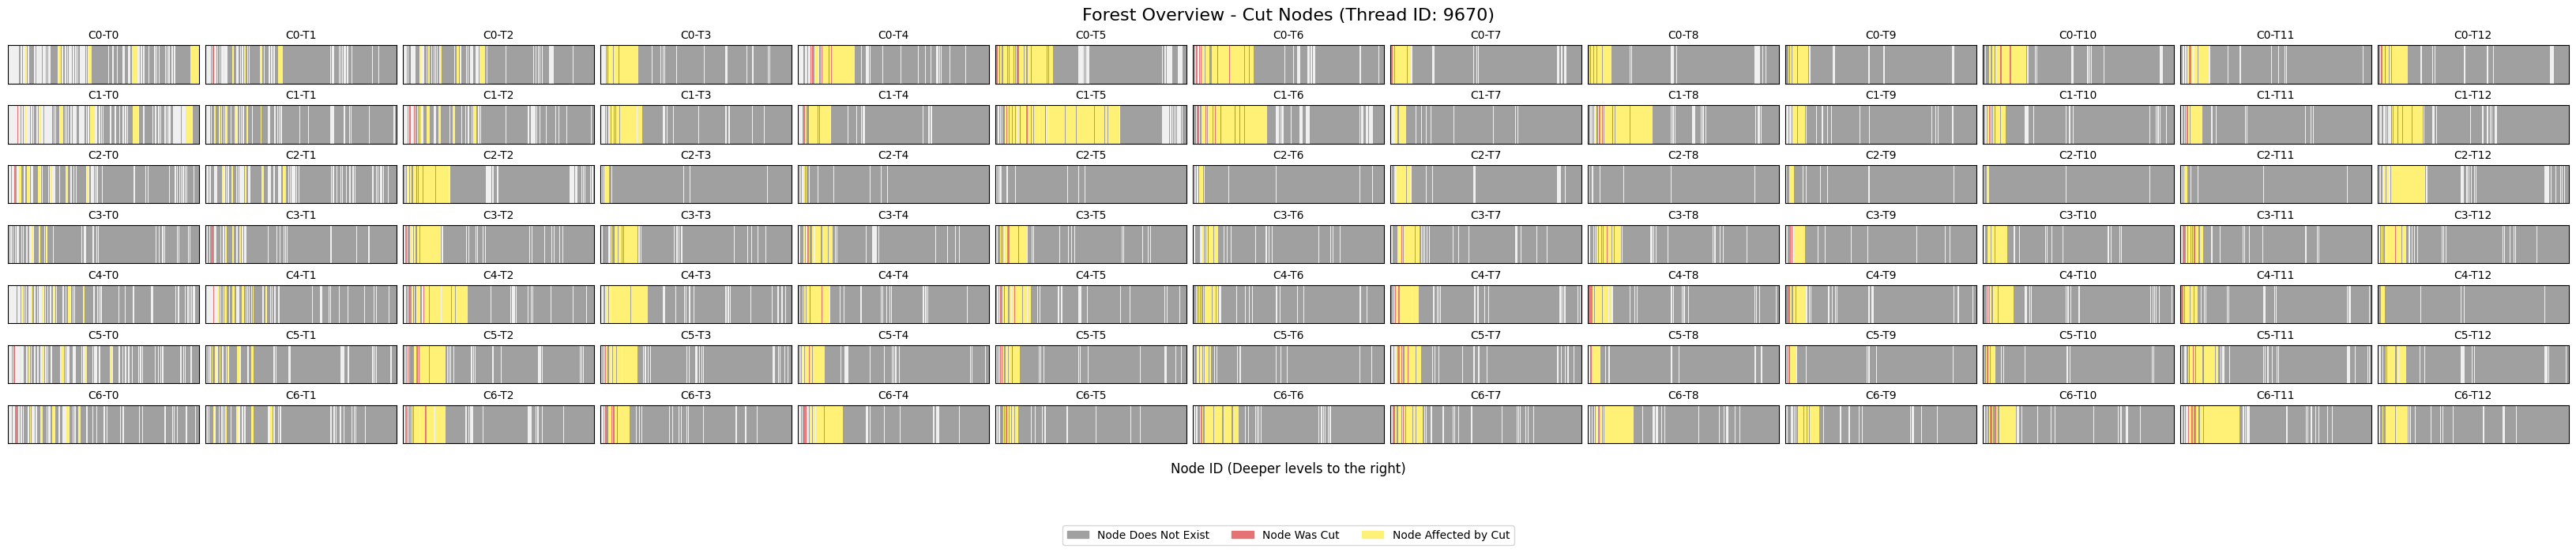

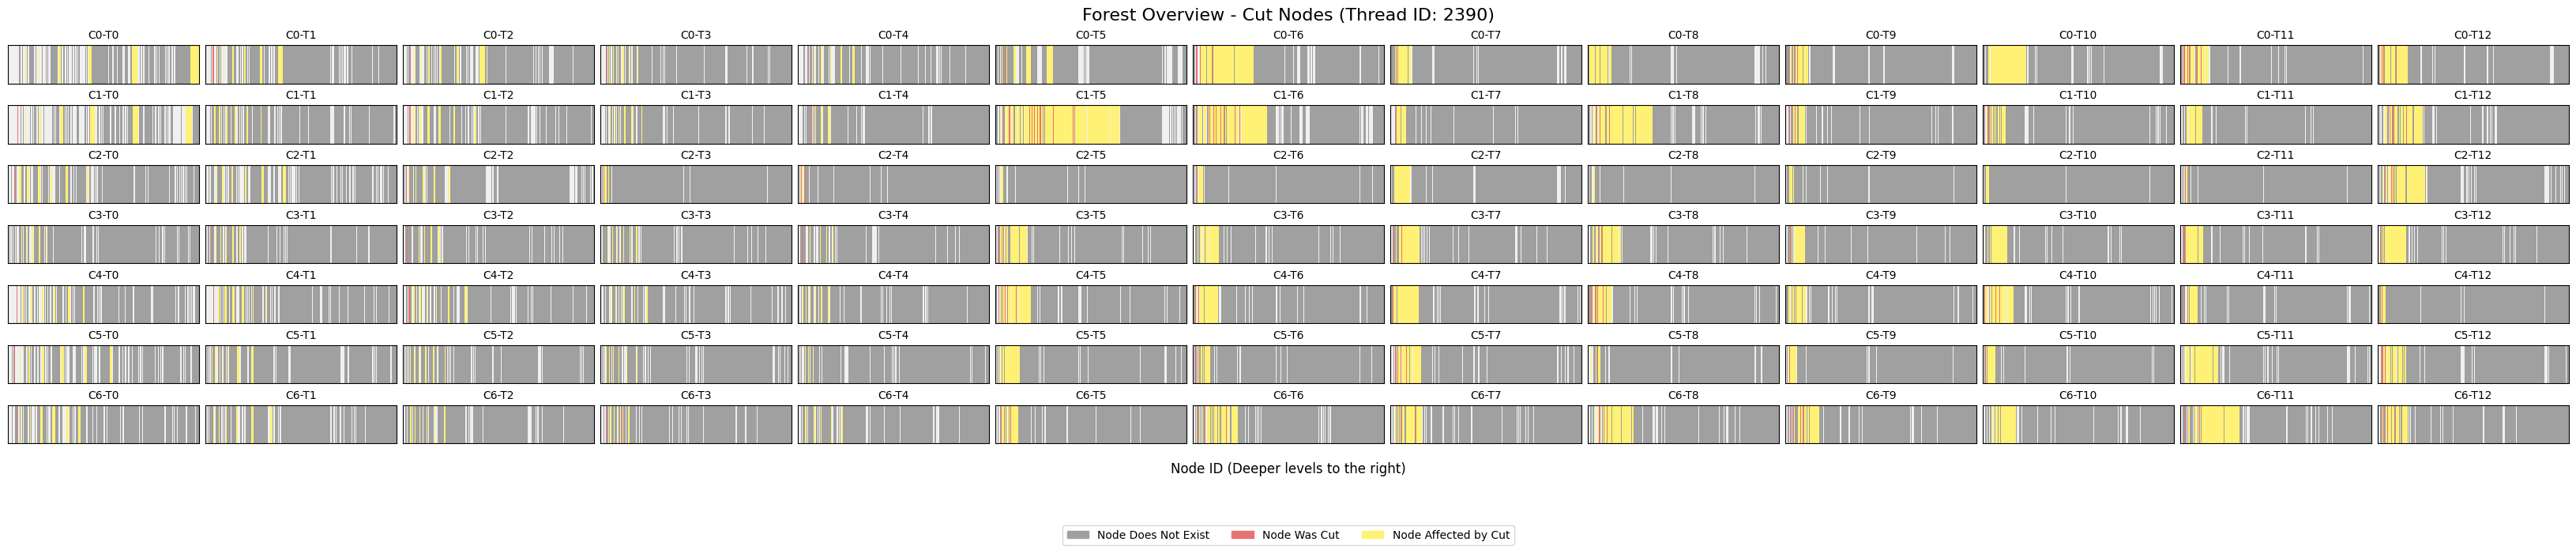

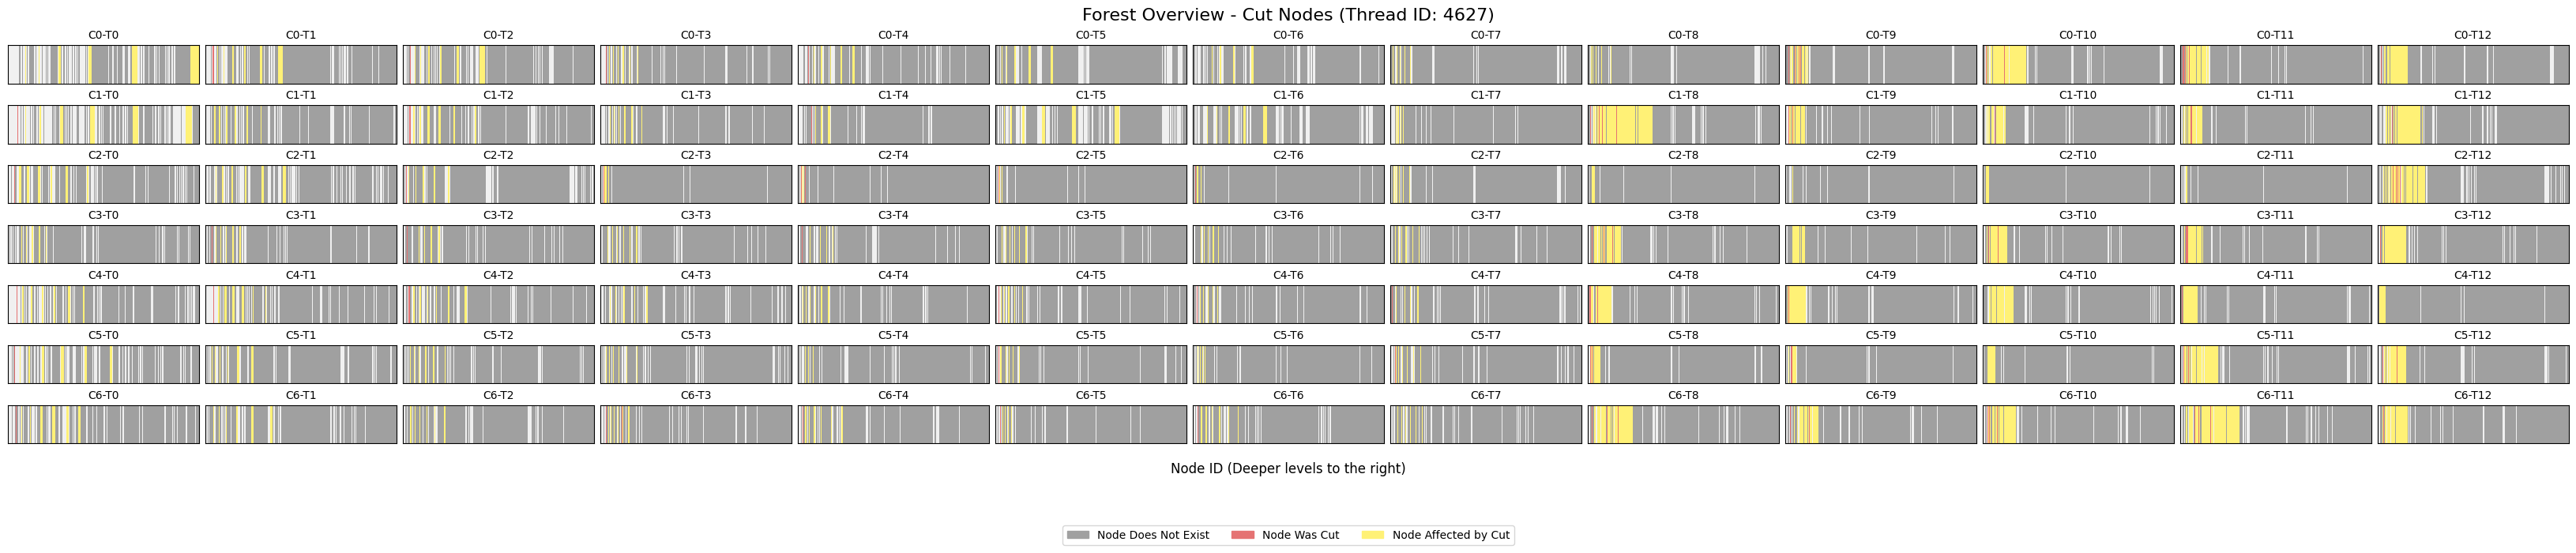

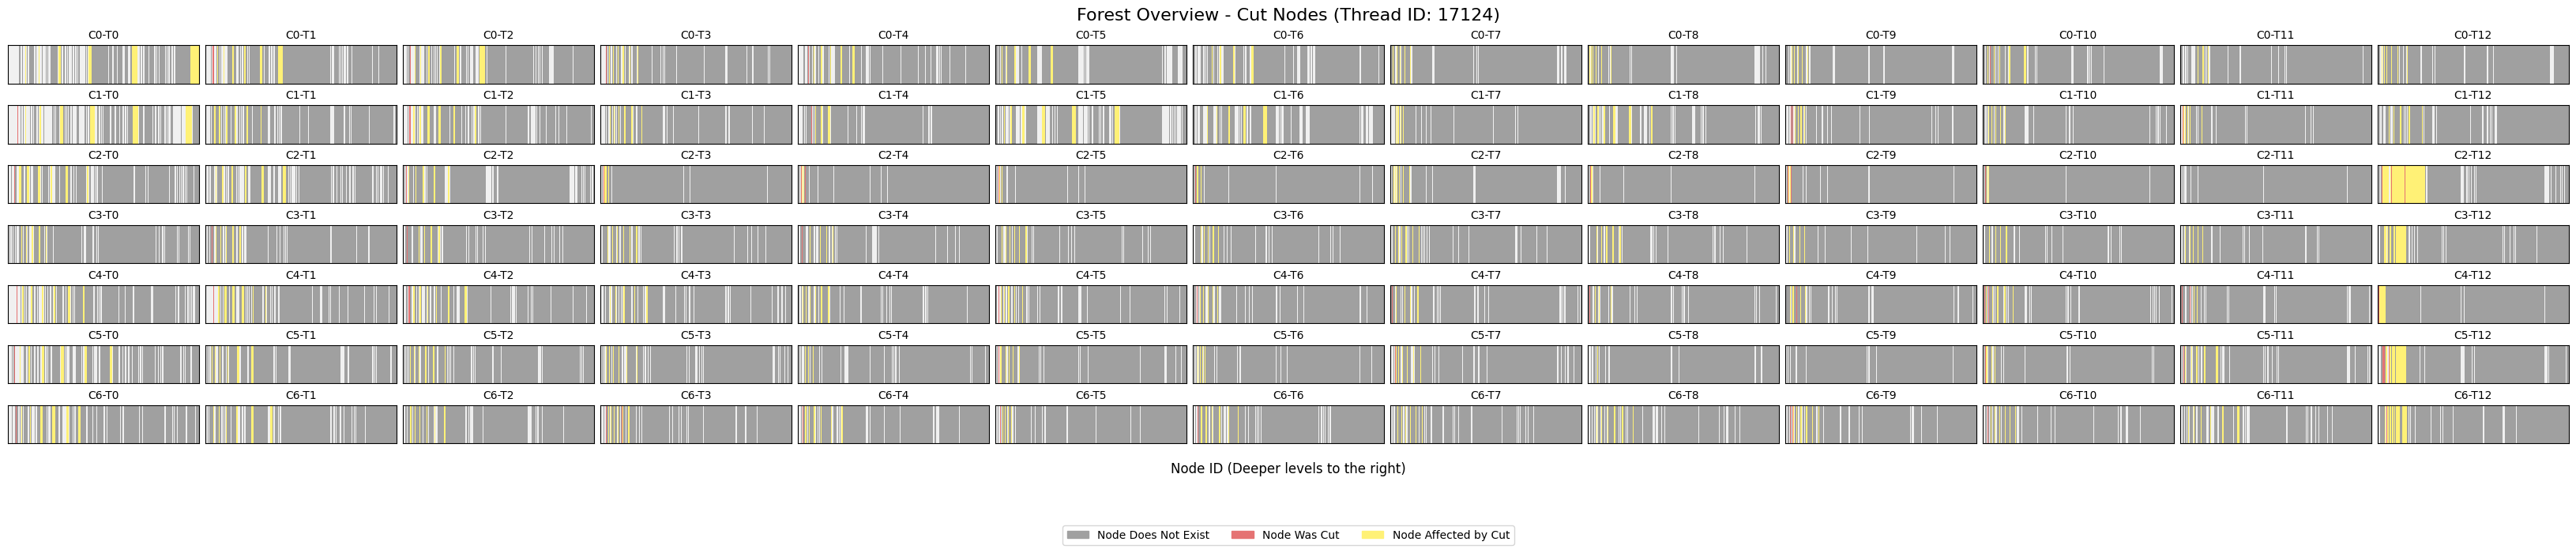

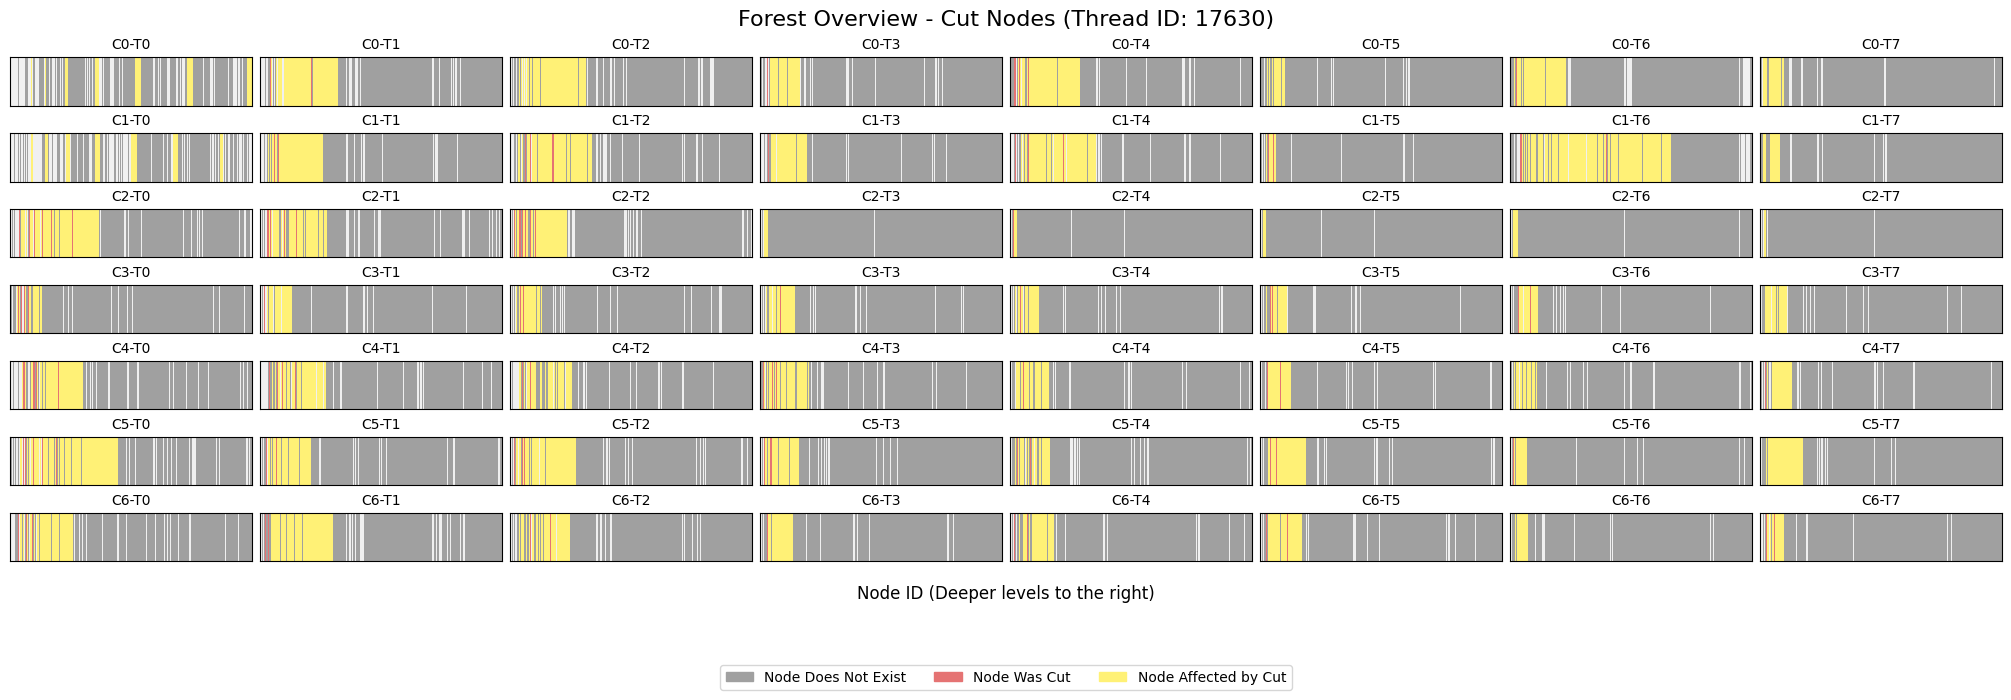

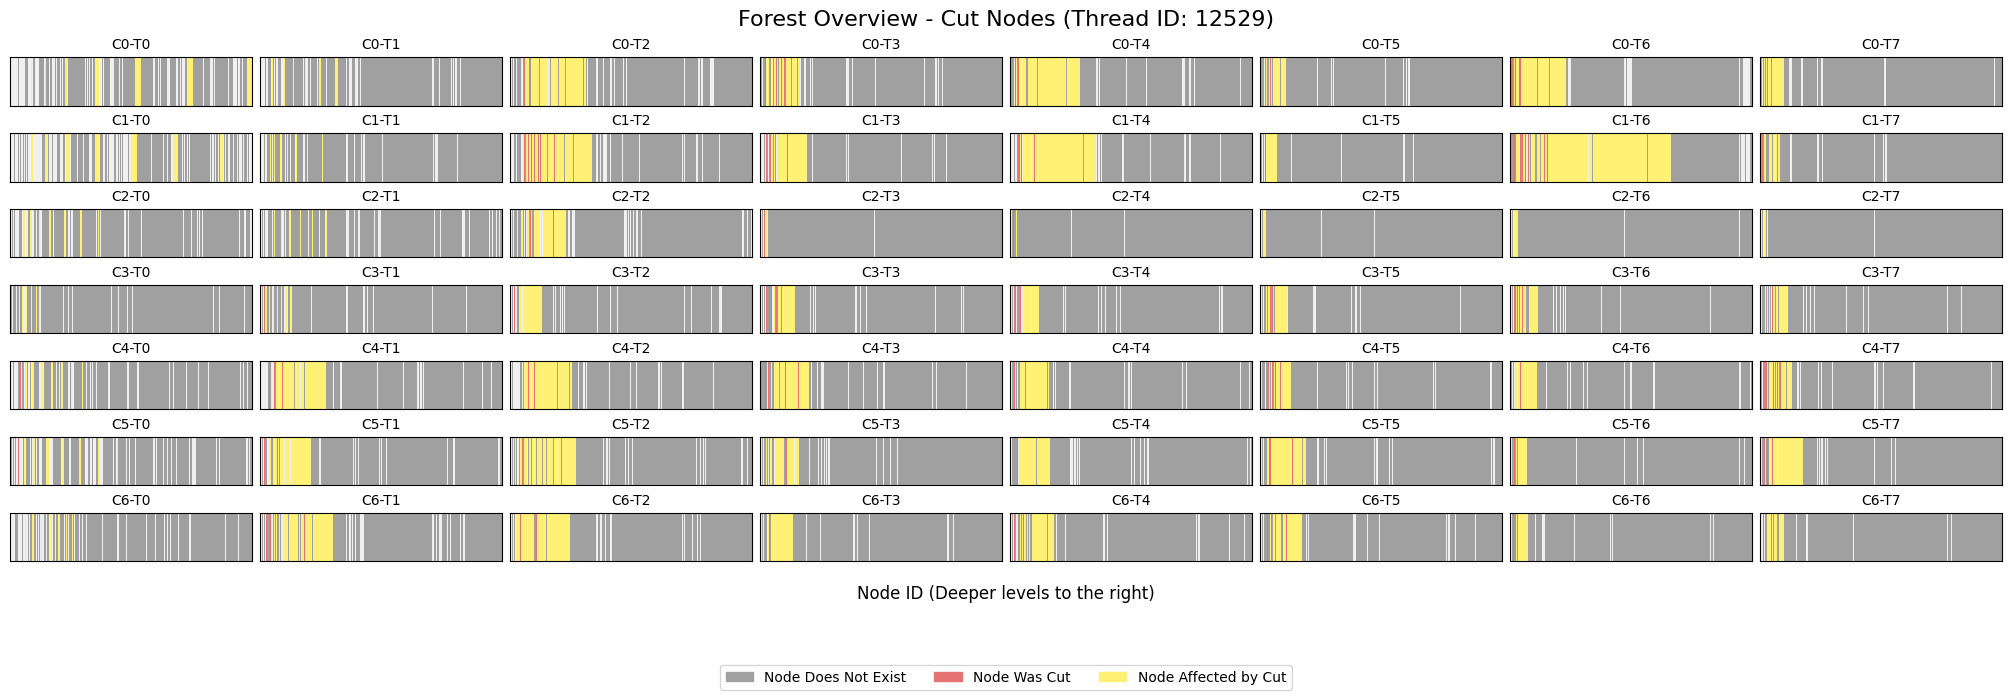

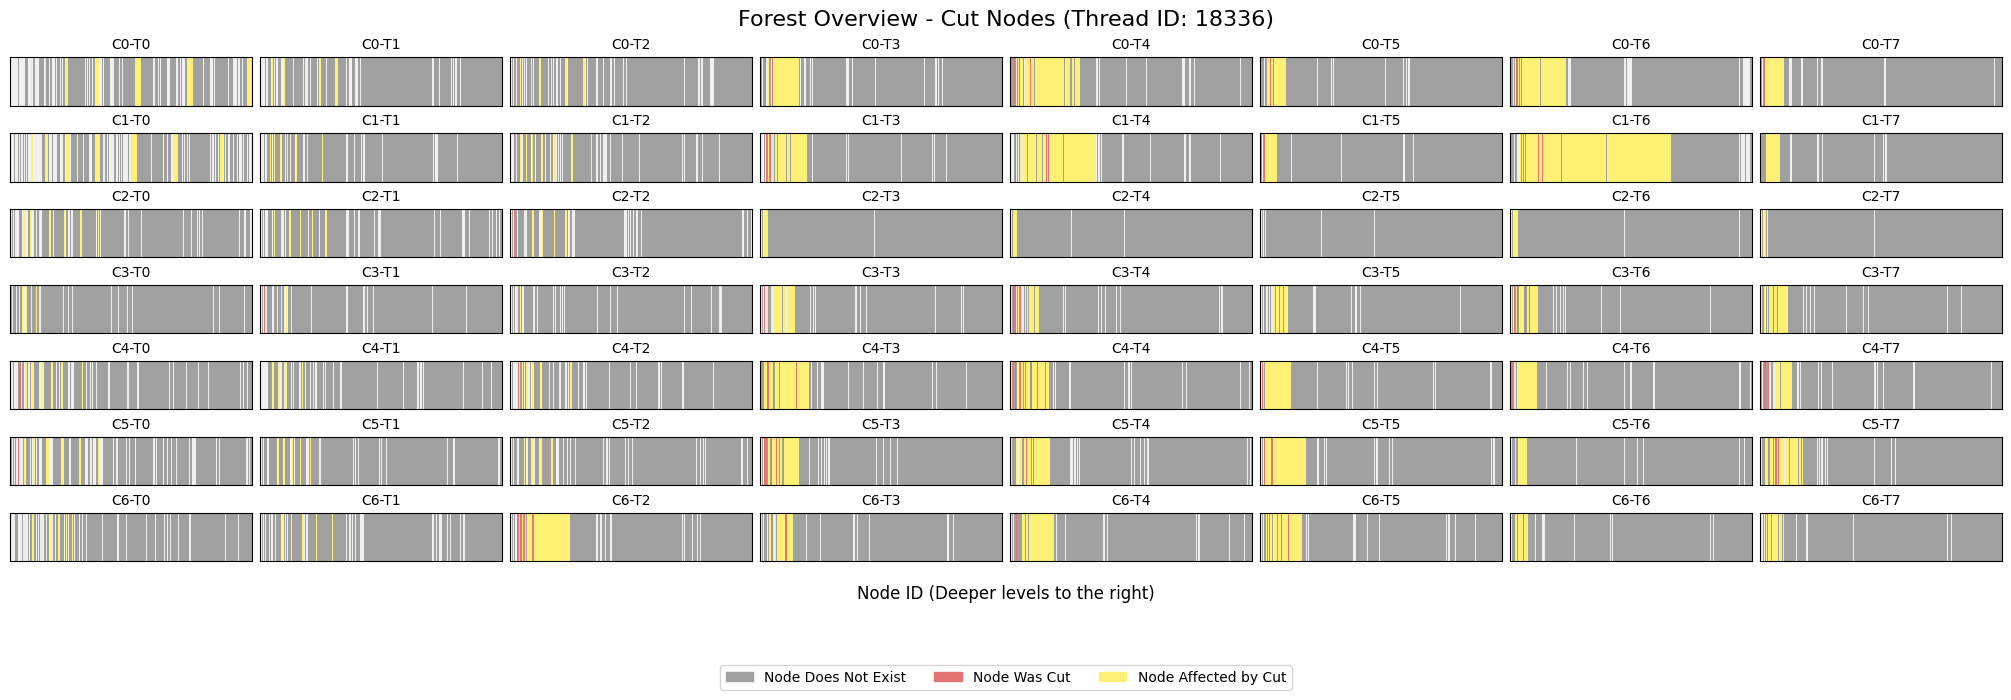

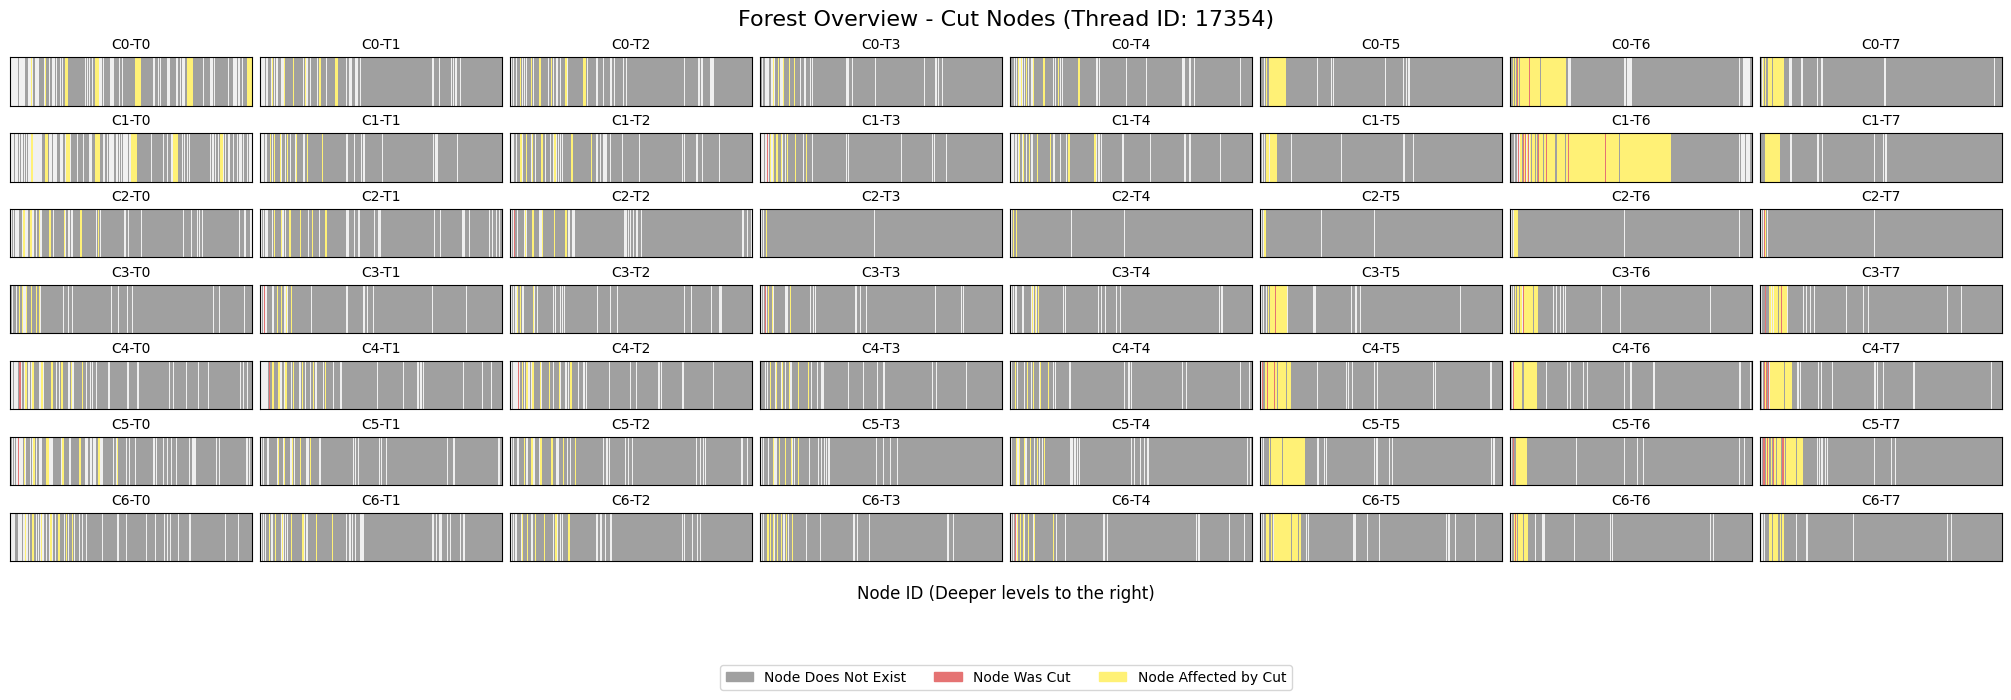

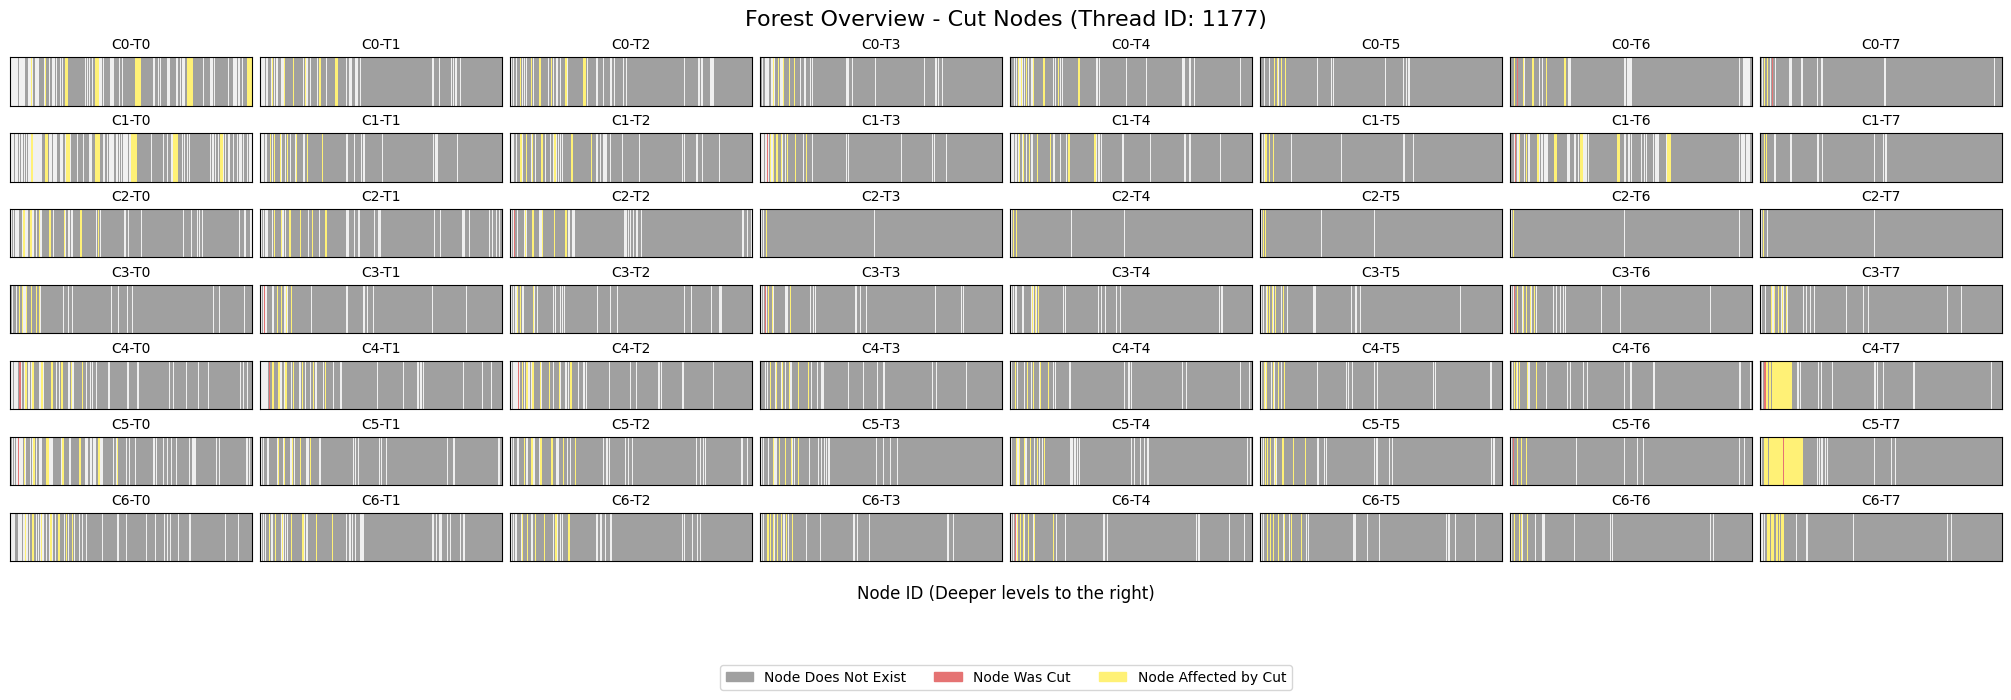

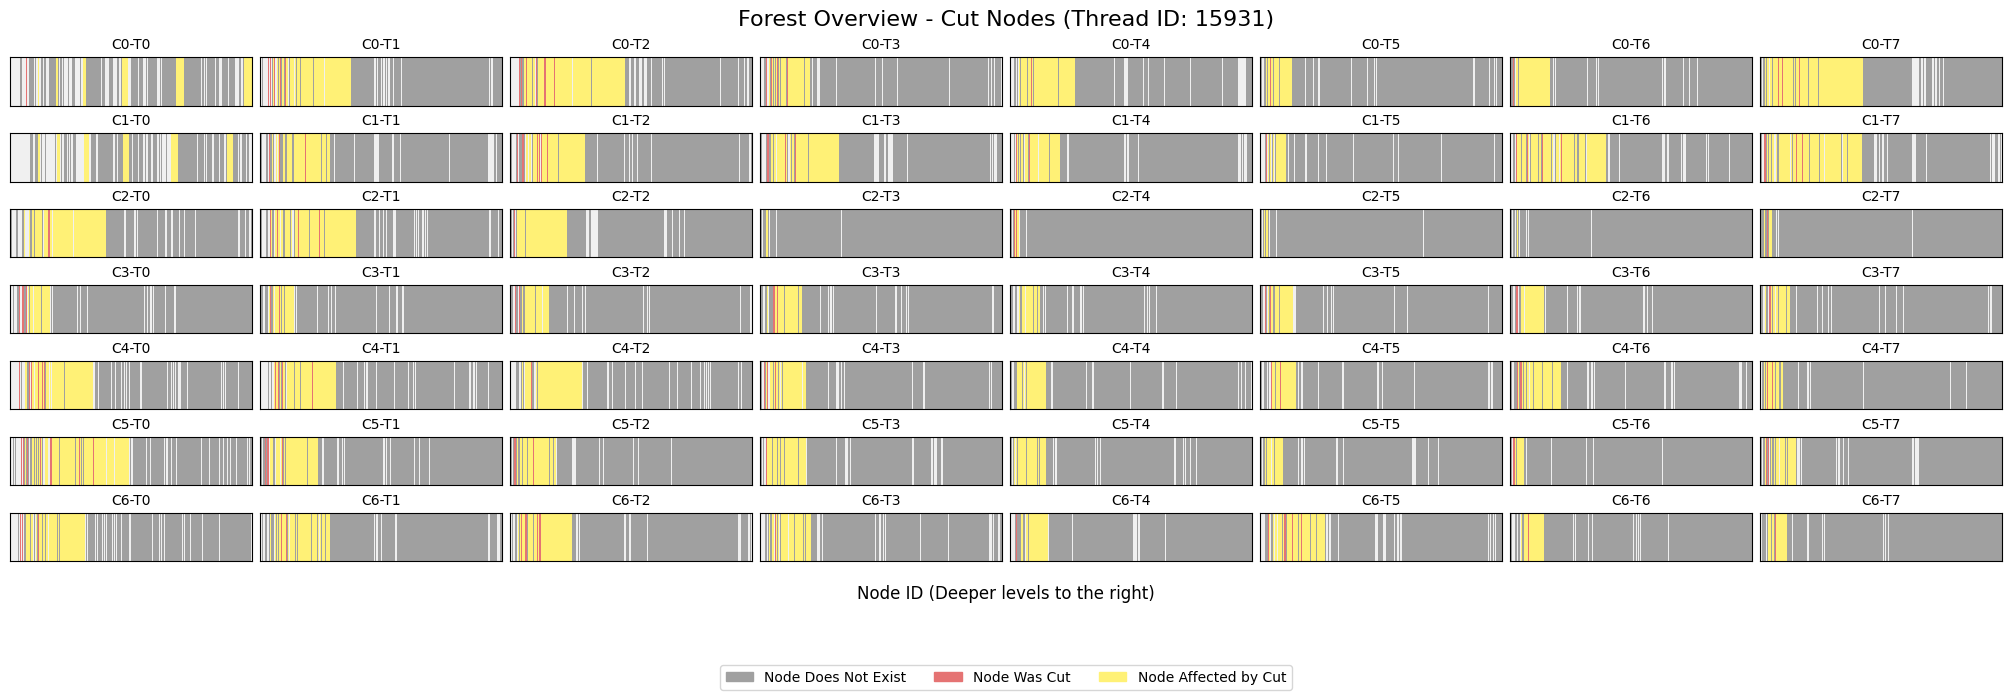

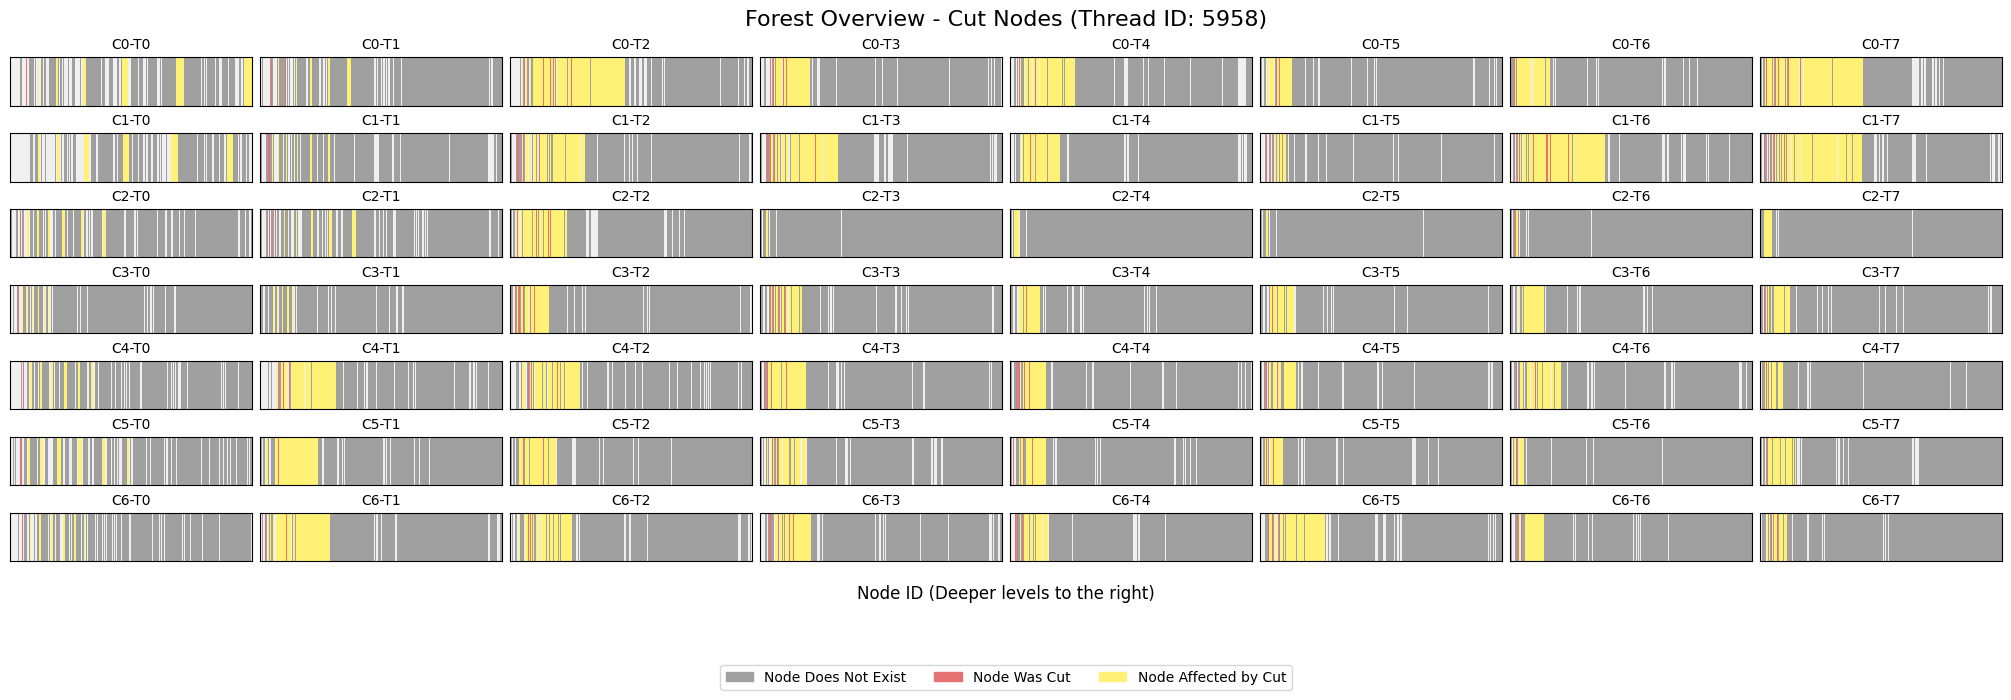

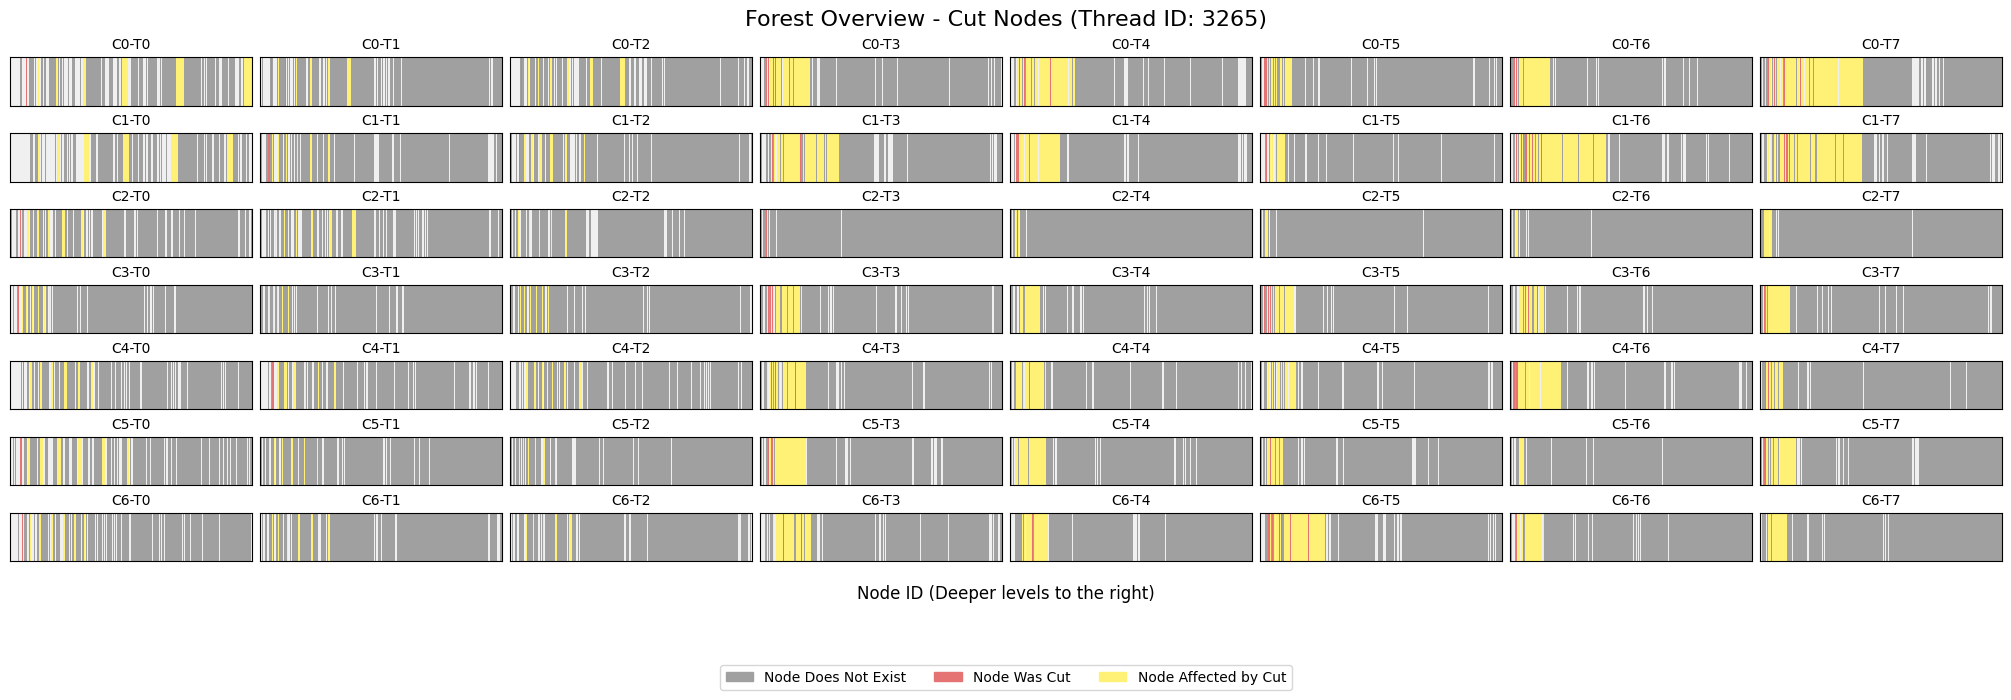

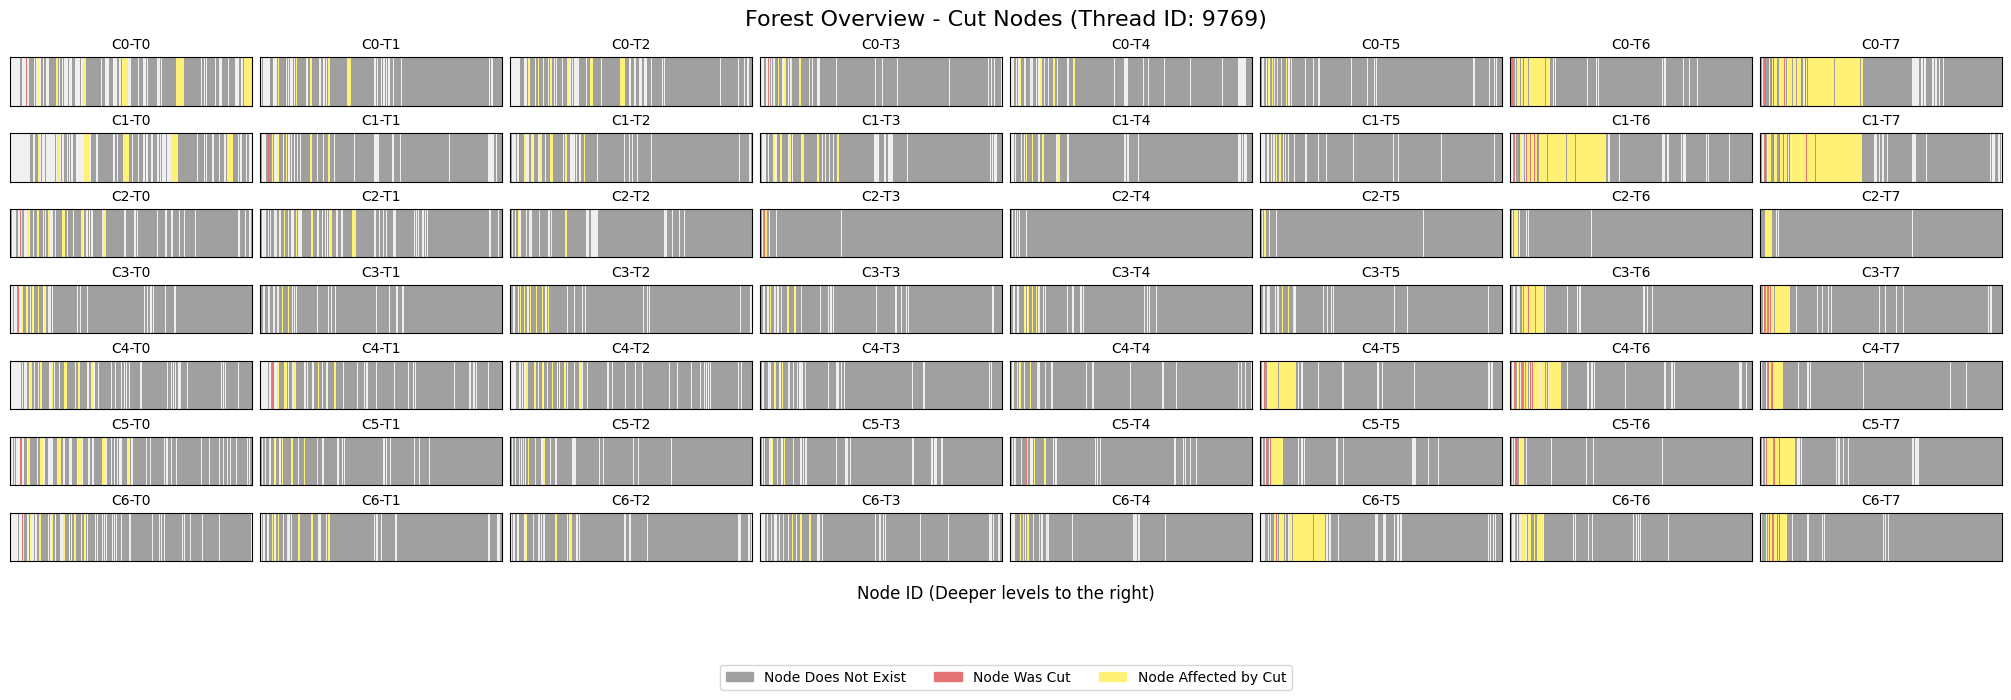

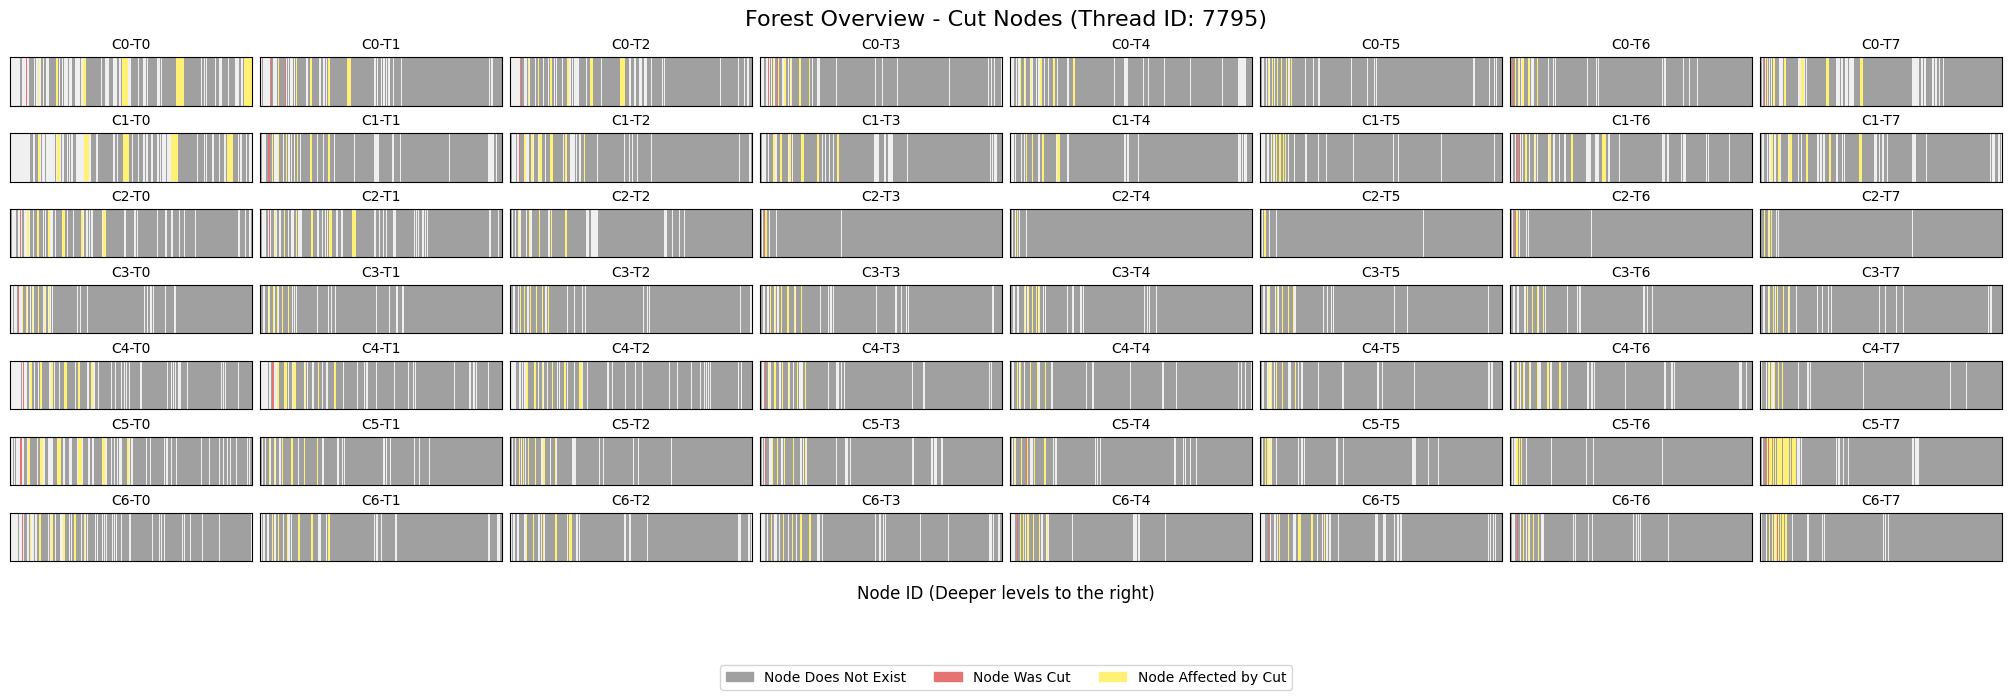

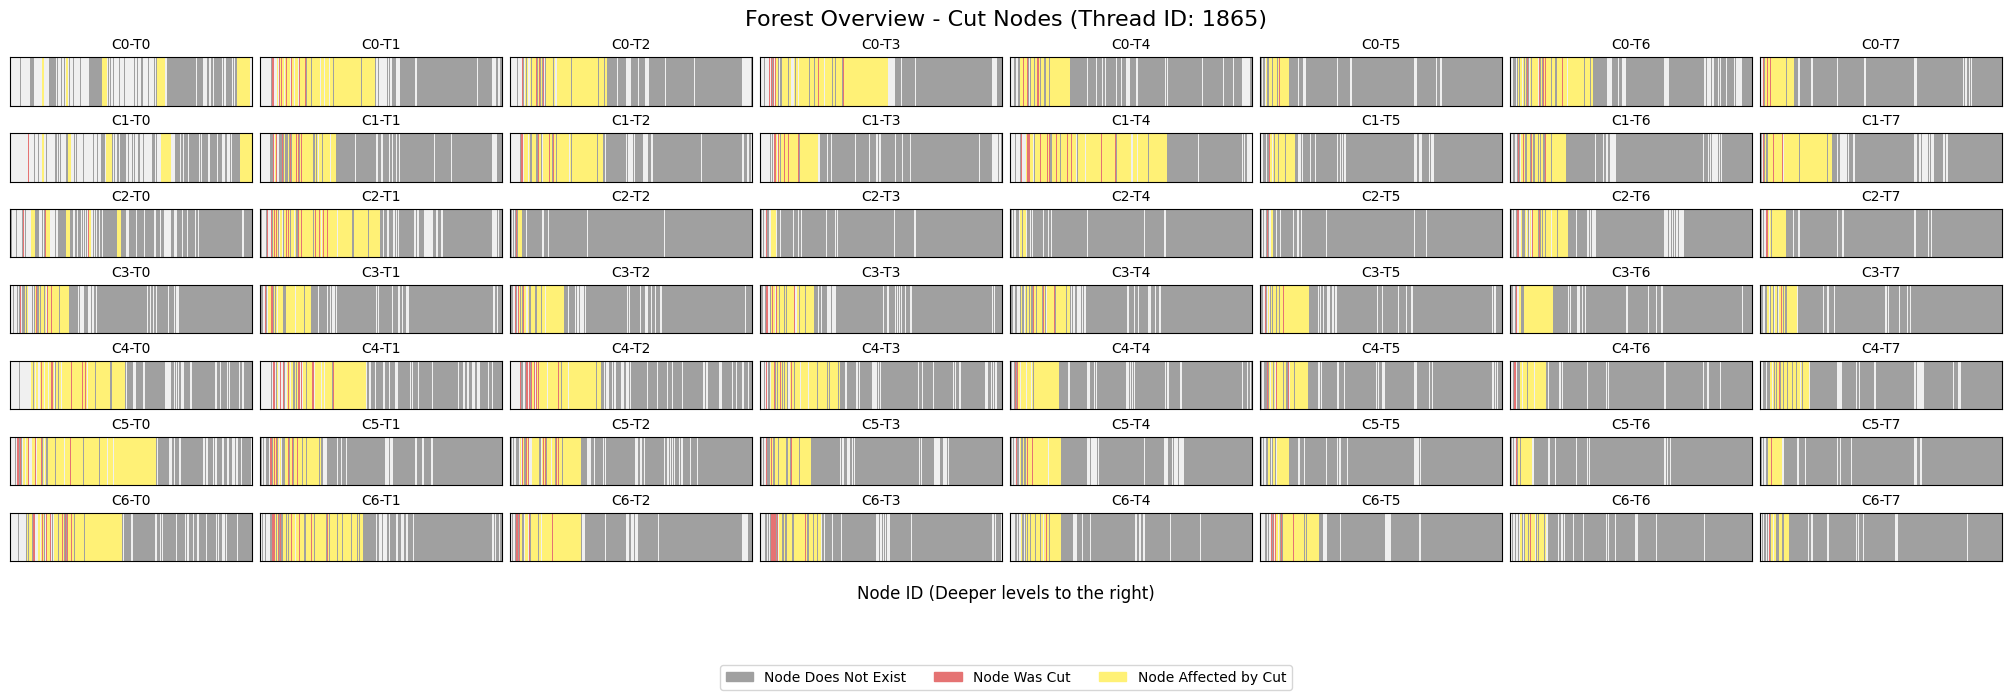

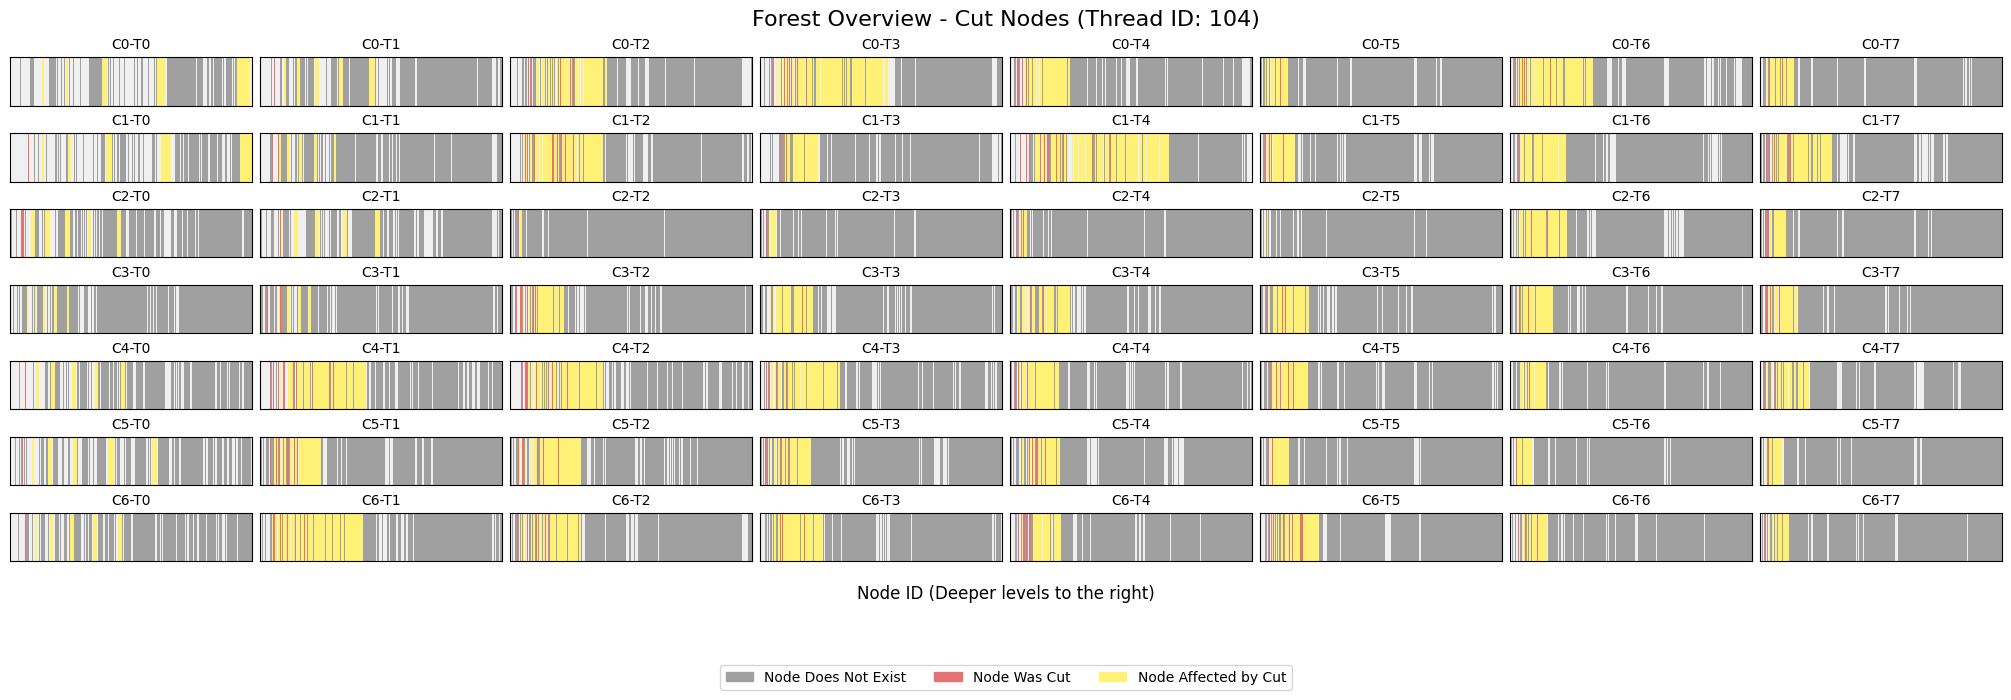

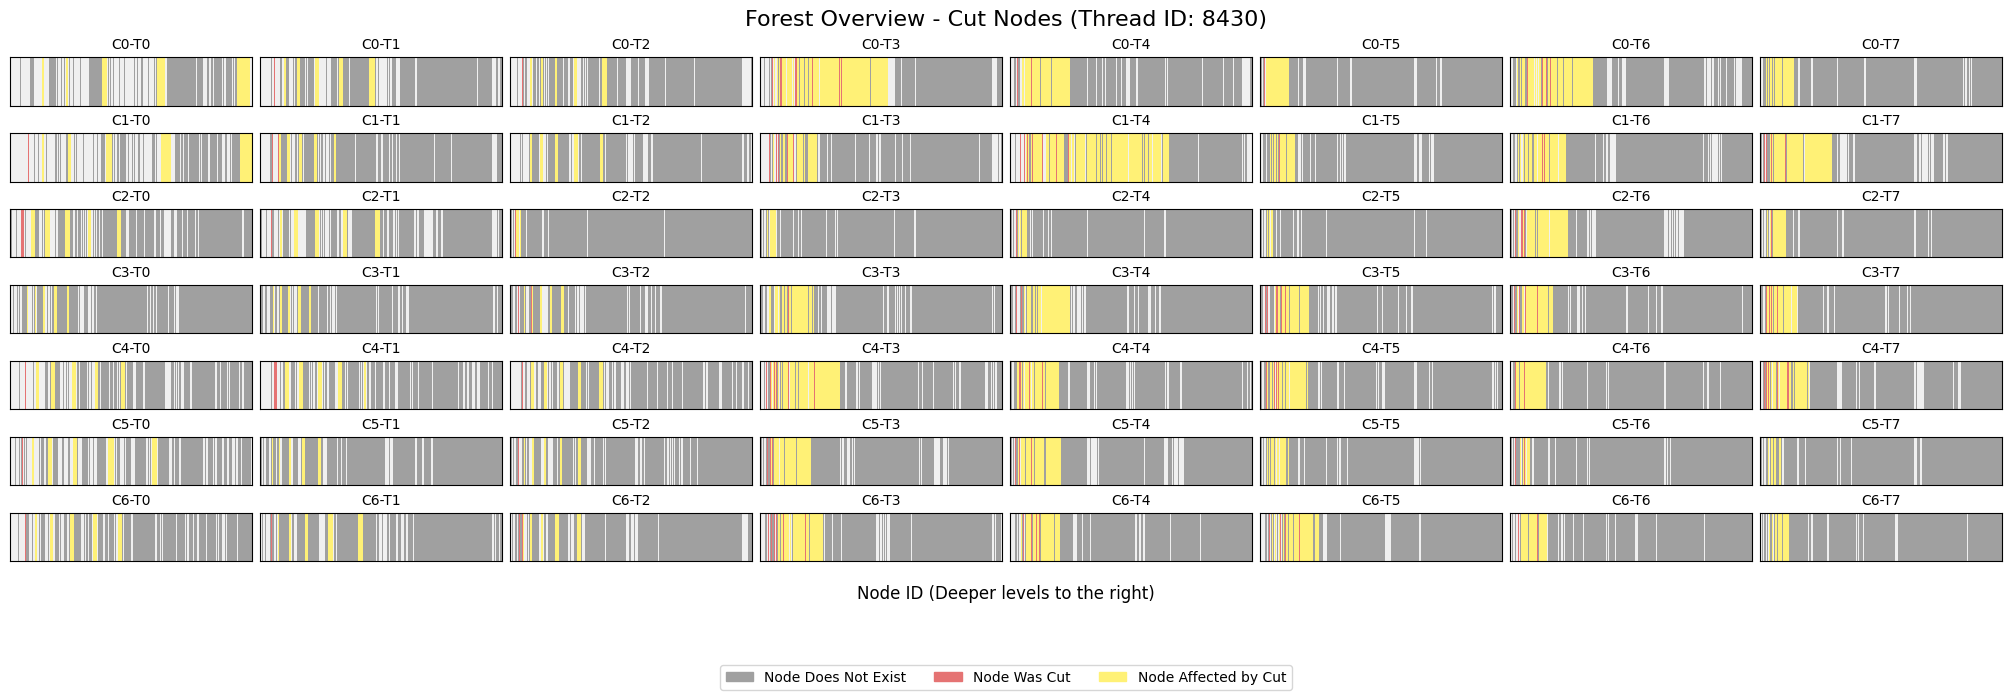

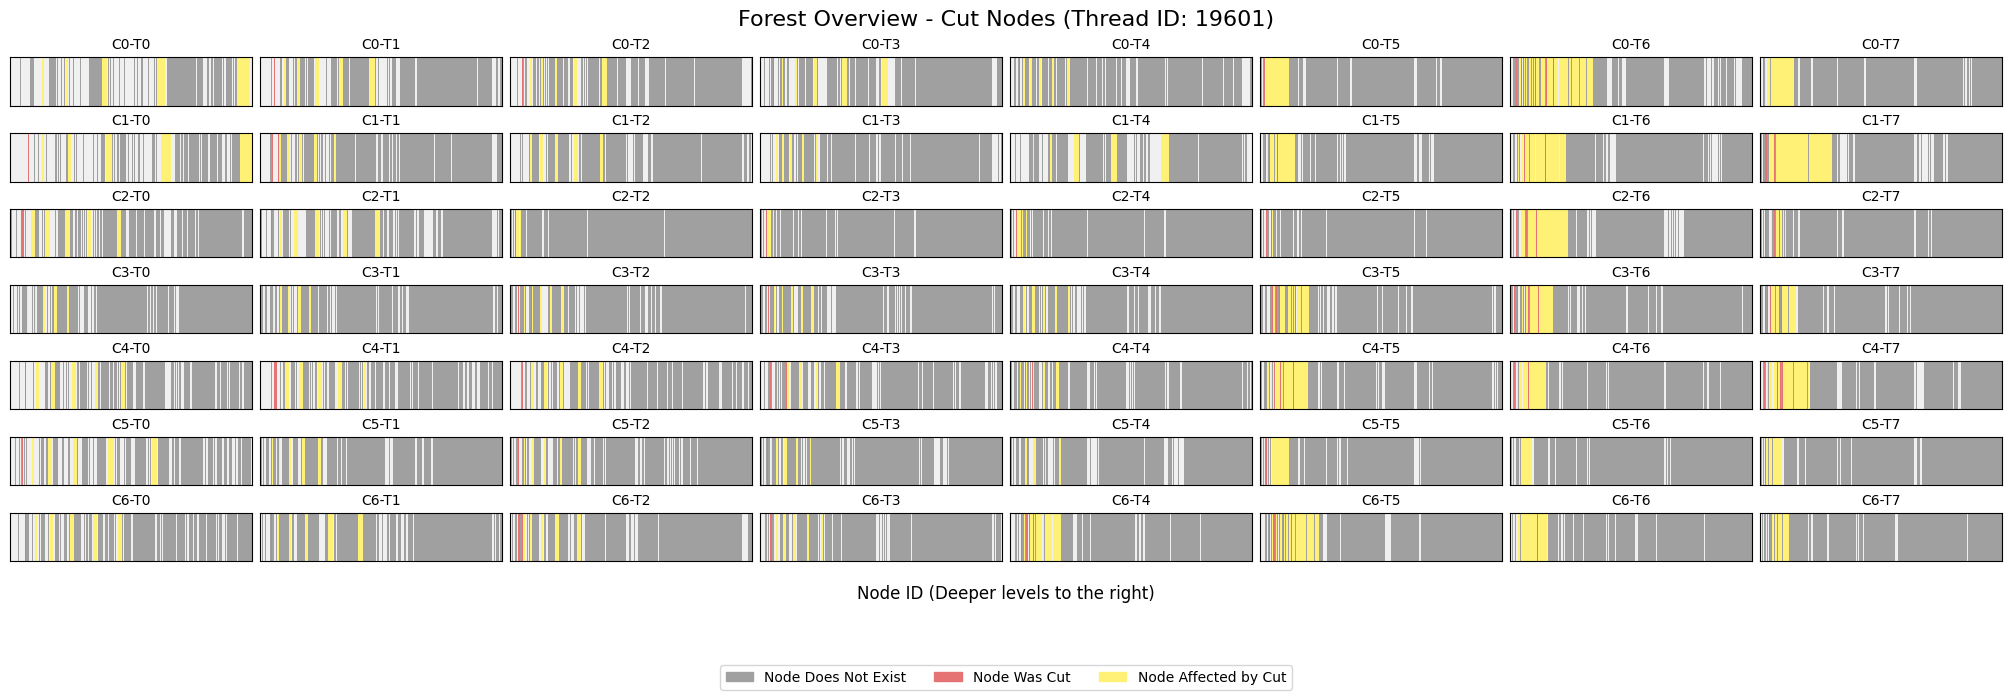

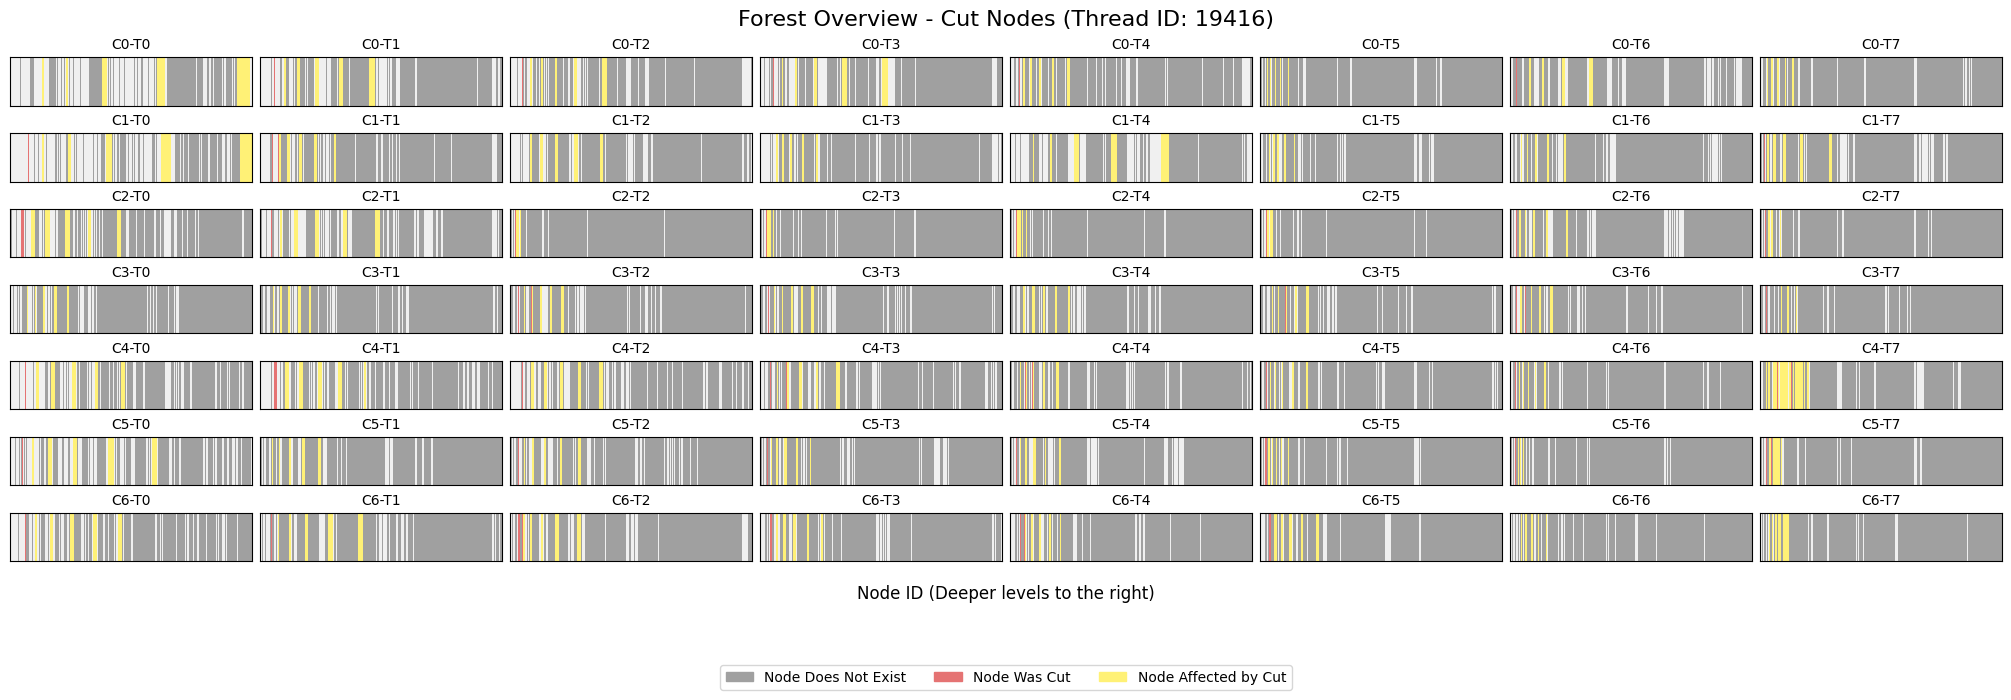

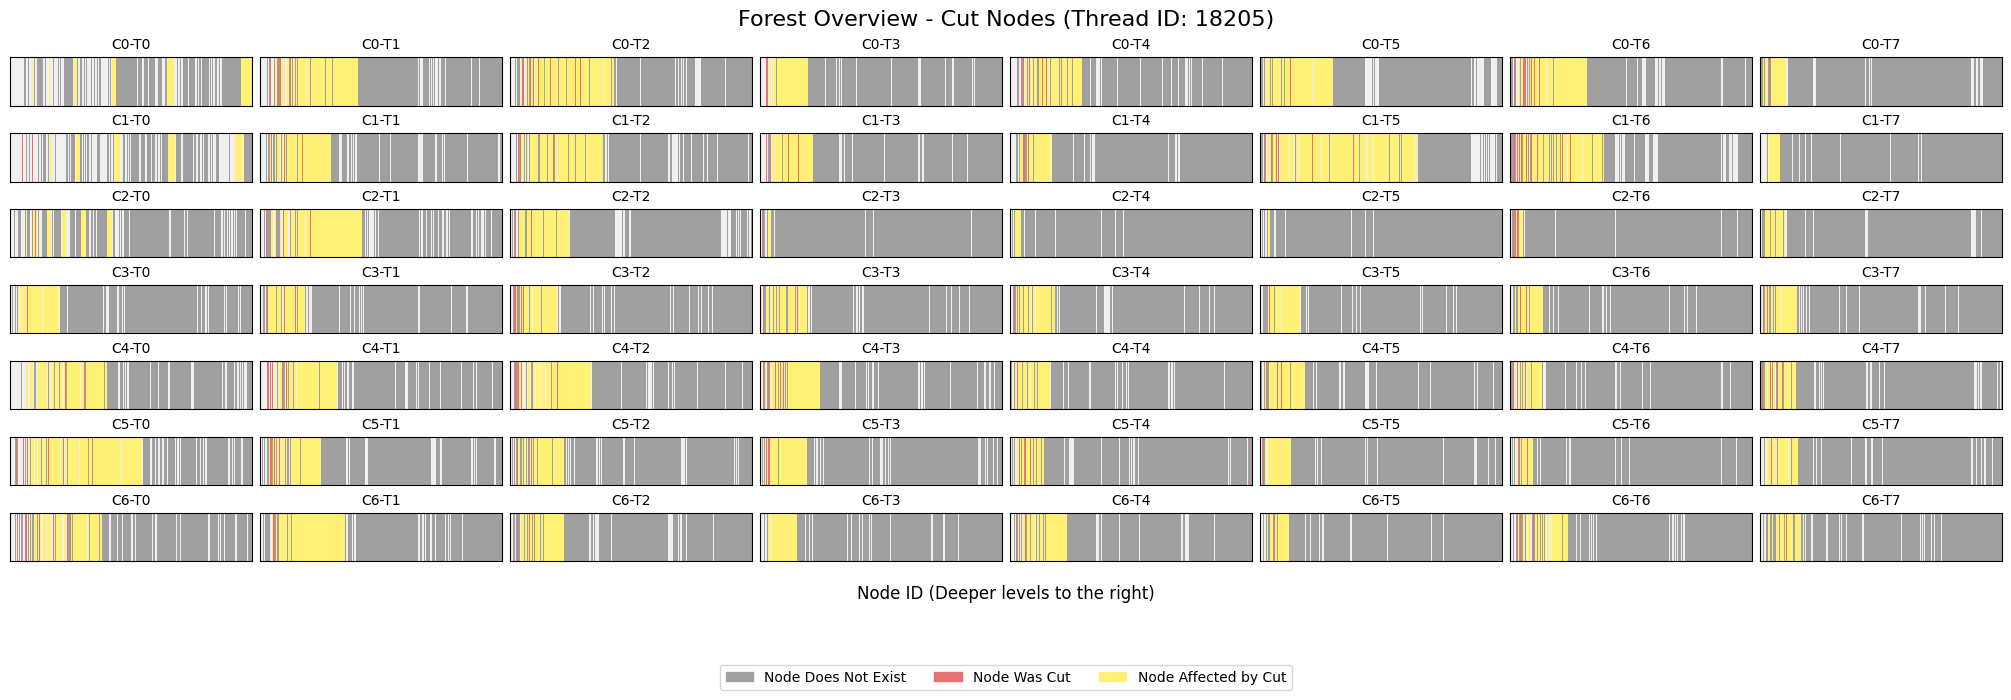

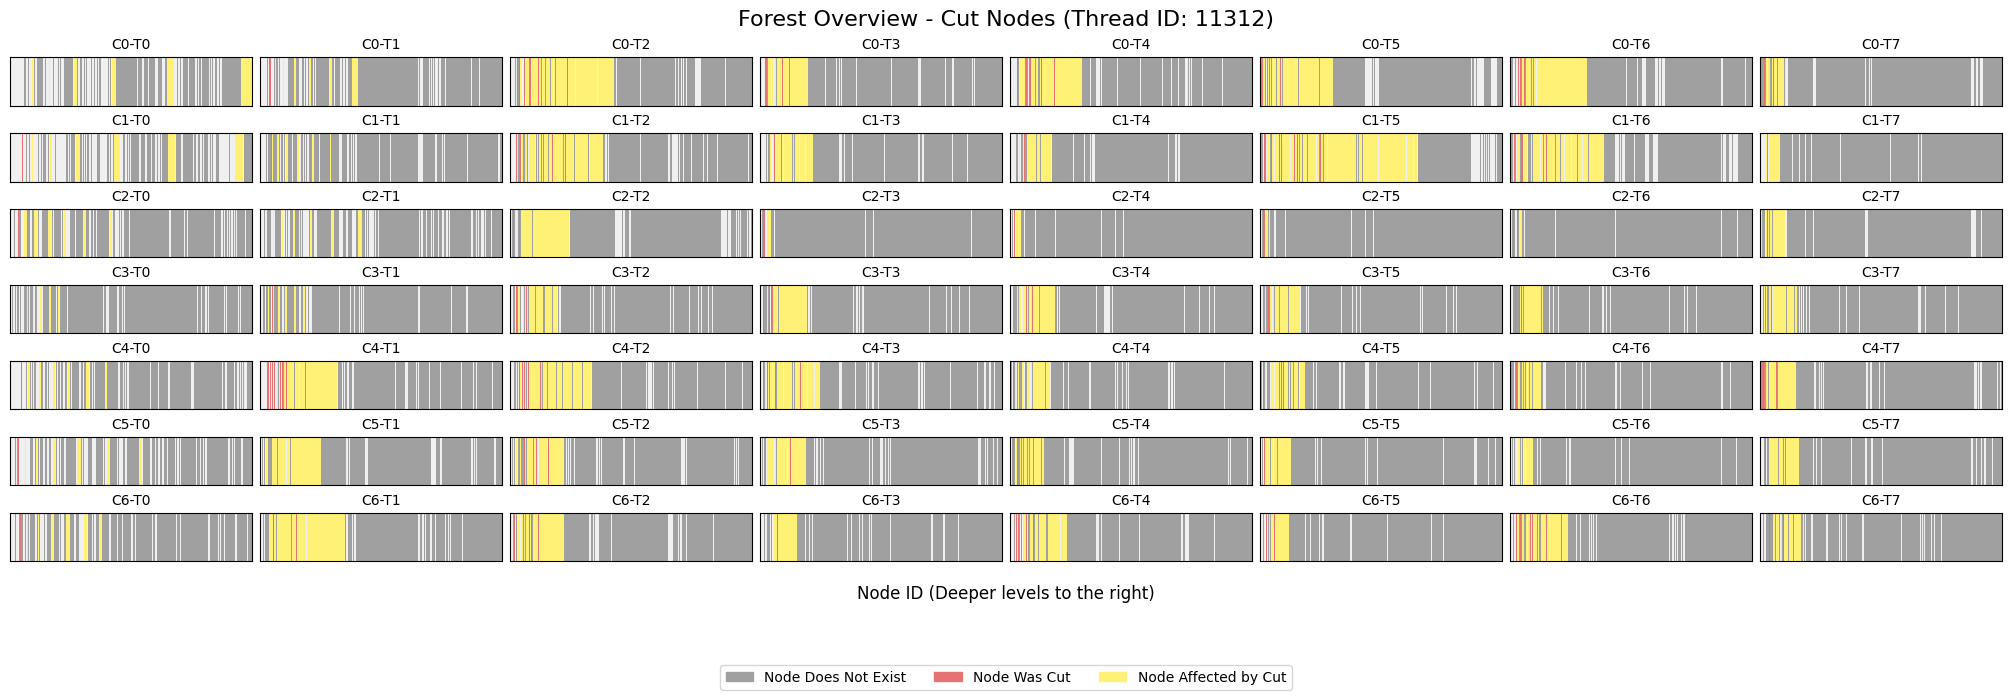

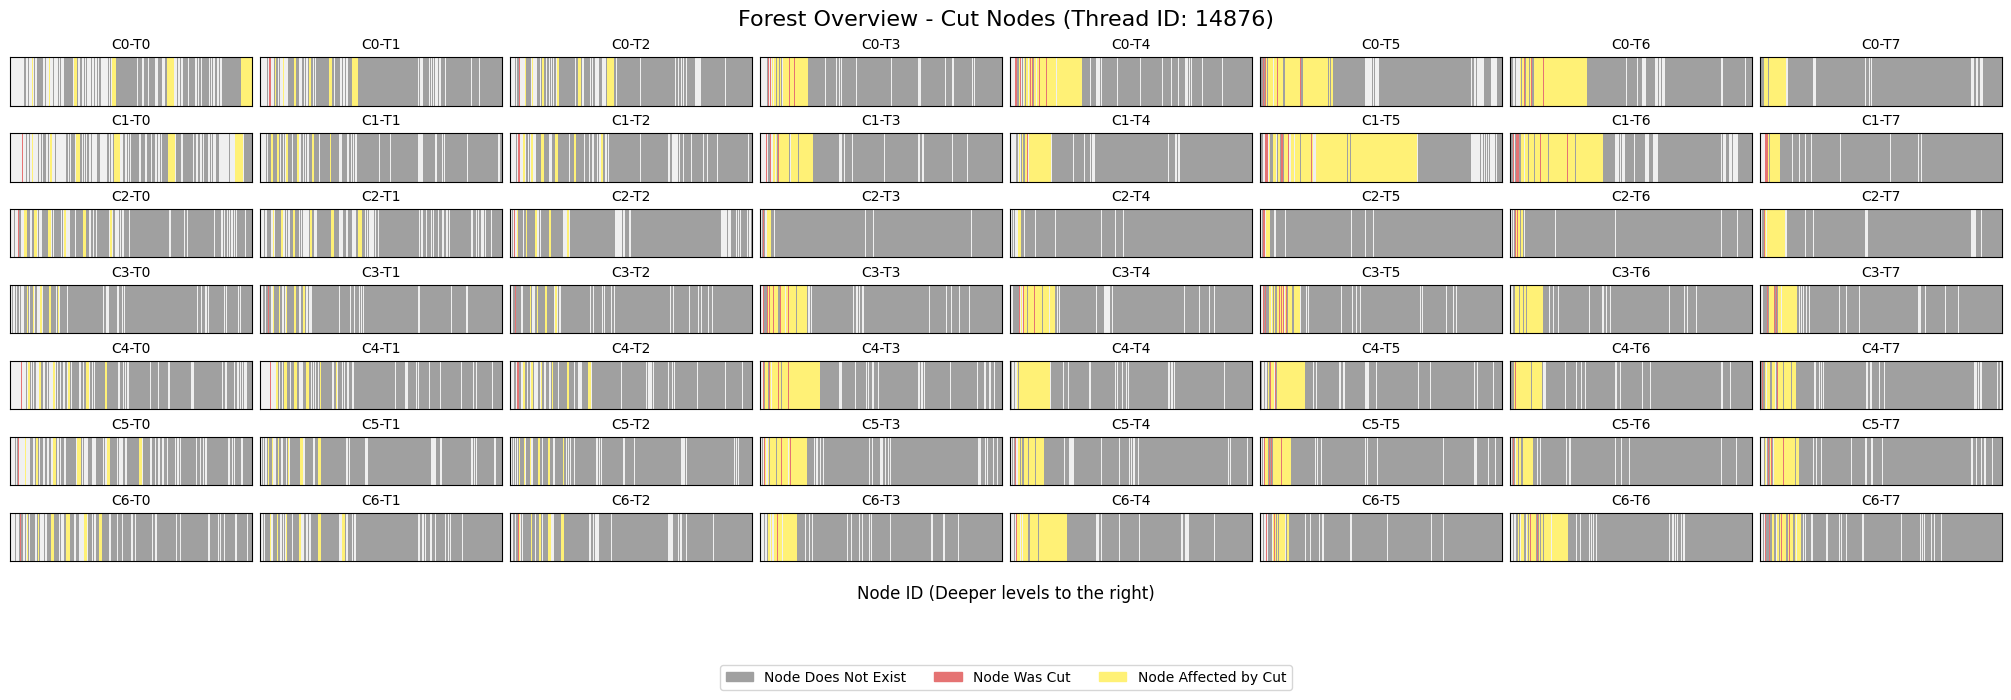

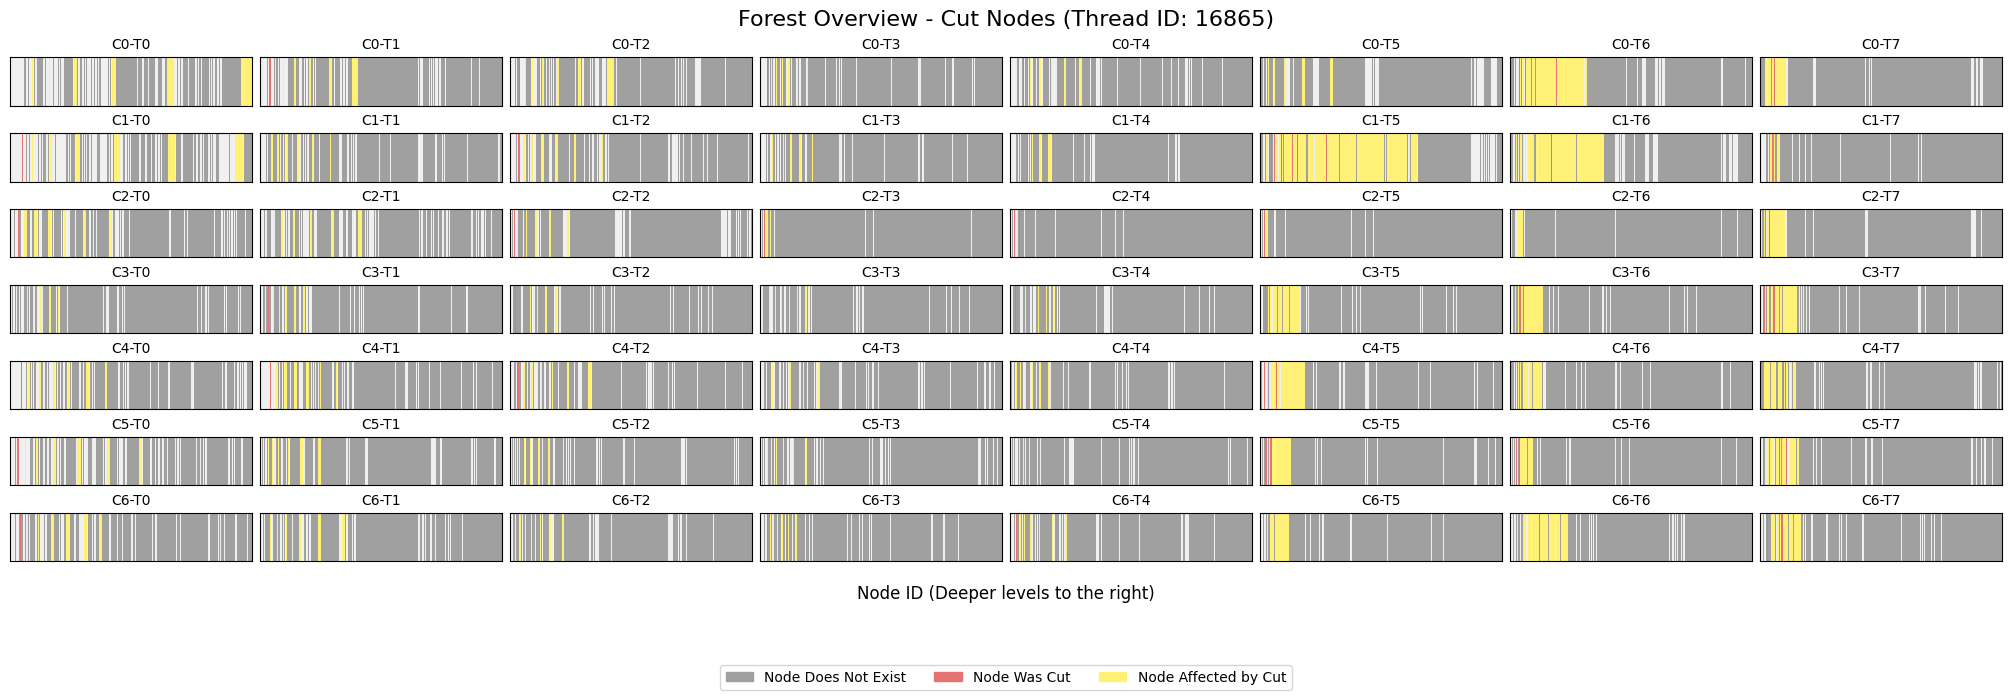

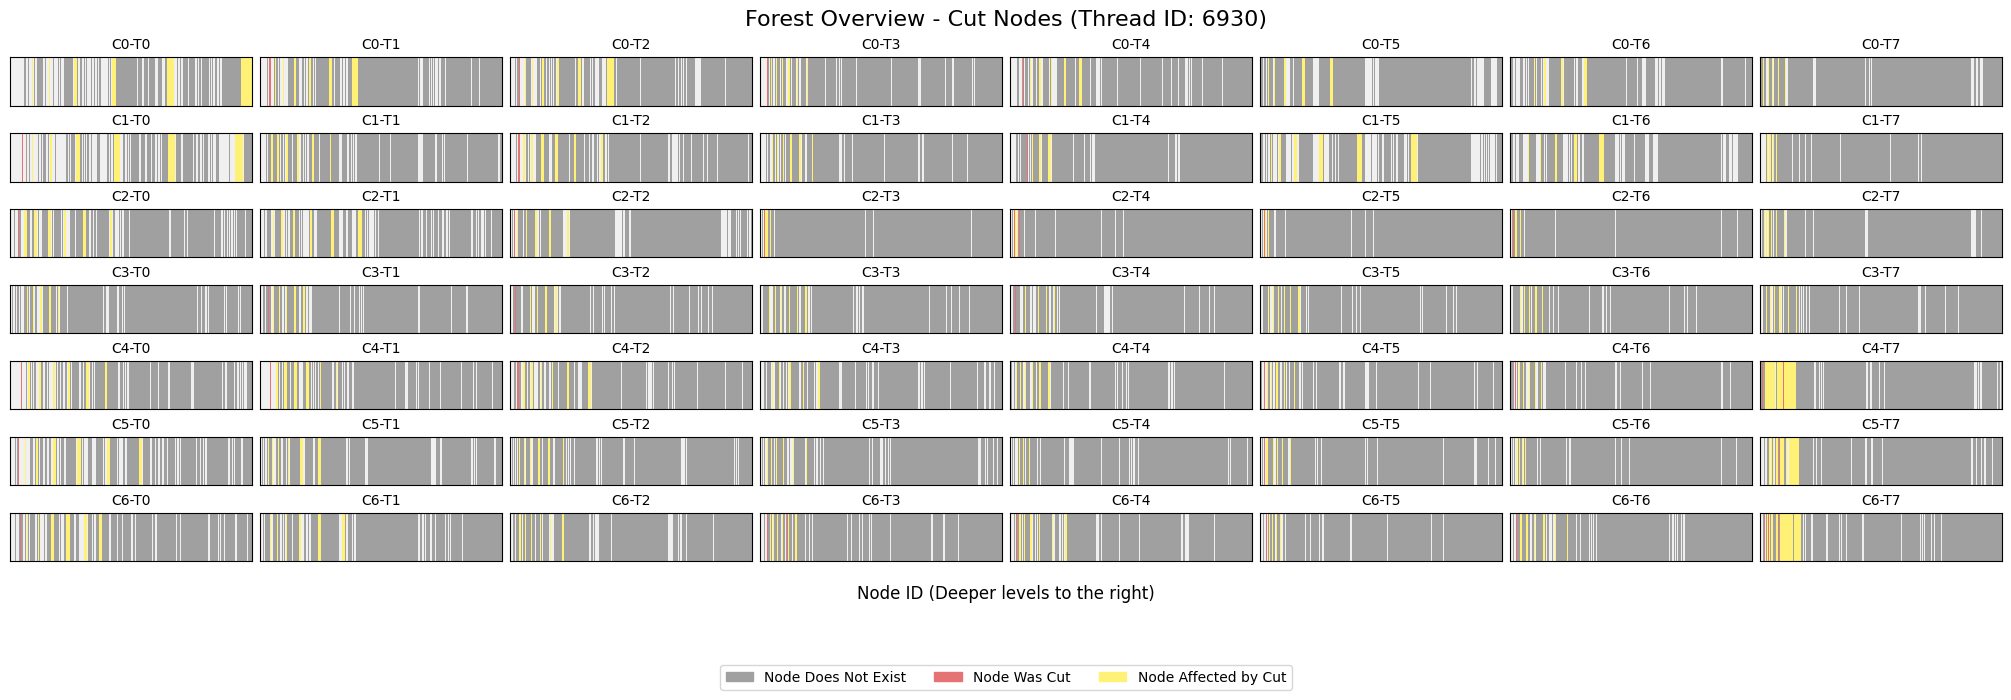

In [12]:
# Run TreeLUT on all datasets and with a range of parameters
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

import itertools
import subprocess
import os
import shutil
import re
from tqdm.auto import tqdm

# --- Parameters Configuration ---
n_estimators = [14, 7, 13, 8]
max_depth = [14, 13, 11, 12]
n_blocks = [79]
n_threads = [256]

percentage_to_cut = [0.10, 0.20, 0.30, 0.40, 0.50]
strategy = ['flat']
level_importance = [2]
progress_importance = [0]
level_bias = [-1]
max_cut_percentage = [0.5]

all_combinations = list(itertools.product(
    n_estimators,
    max_depth,
    n_blocks,
    n_threads,
    percentage_to_cut,
    strategy,
    level_importance,
    progress_importance,
    level_bias,
    max_cut_percentage
))

# Directory to store compiled executables to avoid recompilation
COMPILED_EXEC_DIR = "./compiled_executables"
os.makedirs(COMPILED_EXEC_DIR, exist_ok=True)

progress_bar = tqdm(all_combinations, desc="Executing combinations", unit="combination")

for params in progress_bar:
    n_estimators, max_depth, n_blocks, n_threads, percentage_to_cut, strategy, level_importance, progress_importance, level_bias, max_cut_percentage = params

    # Create a folder for each combination's results
    folder_name = f"./results/{percentage_to_cut}_t{n_estimators}_d{max_depth}_{level_importance}_{progress_importance}_{level_bias}_{max_cut_percentage}"
    os.makedirs(folder_name, exist_ok=True)

    xgb_params = {
        'objective': 'multi:softmax',
        'num_class': 7,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'eta': 0.8
    }

    # Update the xgb2gpu parameters for pruning
    xgb2gpu_params = {
        'percentage_to_cut': percentage_to_cut,
        'strategy': strategy,
        'level_importance': level_importance,
        'progress_importance': progress_importance,
        'level_bias': level_bias,
        'max_cut_percentage': max_cut_percentage,
        'urgency_override_threshold': 1.5,
        'output_file': f'{folder_name}/prune.csv'
    }

    xgb_clf_min_max = XGBClassifier(**xgb_params)
    xgb_clf_min_max.fit(X_train_min_max, y_train)

    # Create and convert TreeLUT model
    treelut_clf = TreeLUTClassifier(
        xgb_model=xgb_clf_min_max,
        **treelut_params,
        min=min_values,
        max=max_values
    )
    treelut_clf.convert()
    y_pred_treelut = treelut_clf.predict(X_test_min_max)
    real_acc = accuracy_score(y_pred_treelut, y_test)

    # Create XGBoost2GPU instance
    xgb2gpu = XGBoost2GPU(treelut_model=treelut_clf,
                        w_feature=treelut_params['w_feature'],
                        w_tree=treelut_params['w_tree'],
                        n_samples=X_valid.shape[0],
                        n_threads=n_threads,
                        n_blocks=n_blocks)

    # Define output file for the CUDA code
    output_cuda_file = f"{folder_name}/xgboost_cuda_generated.cu"

    # Generate CUDA code
    xgb2gpu.generate_cuda_code(output_cuda_file, optimization=True)

    # # Calculate and save pruning probabilities
    xgb2gpu.calculate_forest_probabilities(**xgb2gpu_params)
    xgb2gpu.prune_matrix(save_matrix=True)

    # Copy necessary input files to the result folder
    for f in ['./results/input.csv', './results/expected_output.csv', './results/prune_matrix.csv']:
        if os.path.exists(f):
            shutil.copy(f, folder_name)
        else:
            print(f"❌ Warning: File not found: {f}")

    # --- Conditional Compilation Logic ---
    try:
        # Define paths for the executable
        executable_name = f"executable_{n_estimators}_{max_depth}"
        source_executable_path = os.path.join(COMPILED_EXEC_DIR, executable_name)
        dest_executable_path = f"{folder_name}/xgboost_cuda_generated"

        # Check if a compiled version for this configuration already exists
        if os.path.exists(source_executable_path):
            progress_bar.set_description(f"Copying existing executable for t={n_estimators}, d={max_depth}")
            shutil.copy(source_executable_path, dest_executable_path)
        else:
            # If not, compile the CUDA code
            progress_bar.set_description(f"Compiling new executable for t={n_estimators}, d={max_depth}")
            compile_command = f"nvcc -arch=sm_89 -O3 -lineinfo {output_cuda_file} -o {dest_executable_path}"
            subprocess.run(compile_command, shell=True, check=True, capture_output=True)
            
            # Copy the newly compiled file to the central directory for future use
            shutil.copy(dest_executable_path, source_executable_path)
        
        # Go to the folder and run the compiled CUDA code
        os.chdir(folder_name)
        run_command = "./xgboost_cuda_generated"
        time_result = subprocess.run(run_command, shell=True, check=True, capture_output=True)

        # Return to the original directory
        os.chdir('../..')
        
        progress_bar.set_postfix({"Status": "Success"})

    except subprocess.CalledProcessError as e:
        print(f"❌ Error compiling or running CUDA code for {folder_name}: {e}")
        print(f"NVCC Stderr: {e.stderr.decode() if e.stderr else 'N/A'}")
        os.chdir('../..') # Ensure we return to the root directory on error
        continue # Skip to the next combination

    finally:
        # Clean up temporary files from the result folder
        try:
            # os.remove(f"{folder_name}/xgboost_cuda_generated.cu") # Optional: keep the source
            os.remove(f"{folder_name}/input.csv")
            os.remove(f"{folder_name}/expected_output.csv")
        except OSError as e:
            print(f"❌ Error removing temporary files: {e}")

    # --- Process Results (Assuming this part of your code is correct) ---
    best_id = 0 # Default value
    try:
        with open(f"{folder_name}/accuracy_results.txt", "r") as f:
            for line in f:
                if line.startswith("id"):
                    continue
                current_id = int(line.split(" ")[0])
                if current_id != 0:
                    best_id = current_id
                    break
    except Exception as e:
        print(f"❌ Error reading accuracy results file: {e}")

    # Get the kernel execution time from the output
    kernel_time = None
    if time_result:
        time_output = time_result.stdout.decode('utf-8').strip()
        time_match = re.search(r"Kernel execution time: ([\d.]+) ms", time_output)
        if time_match:
            kernel_time = float(time_match.group(1))

    # Generate the single image with the forest overview.
    tree_data = xgb2gpu.model.trees
    num_cutted_nodes, real_num = plot_forest_overview(
        trees=tree_data,
        thread_id_to_plot=best_id,
        num_classes=xgb_params['num_class'],
        num_trees_per_class=xgb_params['n_estimators'],
        output_file=f'{folder_name}/forest_overview.png'
    )

    # Predict using the best id and the test data
    y_xgb2gpu = xgb2gpu.predict(X=X_test, thread_id=best_id)
    acc = accuracy_score(y_xgb2gpu, y_test)



    point = {
        'time_stamp': pd.Timestamp.now(),
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'n_blocks': n_blocks,
        'n_threads': n_threads,
        'percentage_to_cut': percentage_to_cut,
        'strategy': strategy,
        'level_importance': level_importance,
        'progress_importance': progress_importance,
        'level_bias': level_bias,
        'max_cut_percentage': max_cut_percentage,
        'urgency_override_threshold': xgb2gpu_params['urgency_override_threshold'],
        'kernel_time': kernel_time,
        'total_nodes': sum(treelut_clf.nodes()),
        'num_cutted_nodes': num_cutted_nodes,
        'cutted_nodes': real_num,
        'consequence_cuts': num_cutted_nodes - real_num,
        'best_id': best_id,
        'real_acc': real_acc,
        'accuracy': acc,
        'diff': real_acc - acc,
    }

    # Write the point to a CSV file
    results_file = './results/accuracy_results.csv'
    write_dict_to_csv(results_file, point)